# CNET 5442 — Sports Analytics Through Data and Networks (Spring 2026)

## Classes 16: From Event Data to State Transition Networks in Soccer

In the previous soccer network notebooks, we kept returning to the same raw material: a match event log. First we turned that event log into a **player passing network**. Then we turned it into a **pitch passing network**. In both cases, the underlying match was the same, but the graph changed because the modeling choices changed.

____________

An event log is not itself a graph. It is a **time-ordered stream of observations**. A graph only appears after we decide:

- what counts as a state,
- which events belong in the sequence,
- whether we connect across possession boundaries,
- whether we keep one team's actions only or include opponent actions,
- whether we keep counts or normalize into probabilities,
- and whether the states are coarse labels like `Pass` or richer labels like `Pass | Standard | High Pass | Failed | Under Pressure`.

That is why event-transition networks deserve two full class meetings. They force us to think carefully about how raw data become a **state space**.

### What you'll learn

By the end of this notebook, you should be able to:

- explain what a soccer event log is and why it should be treated as a sequence before it is treated as a graph,
- turn a short event sequence into an edge list, an adjacency matrix, and a row-normalized transition matrix,
- inspect raw StatsBomb JSON and reason carefully about nested fields,
- build a coarse event-transition network from one team's possession sequences,
- enrich event states with nested fields such as `pass.type`, `pass.height`, `pass.outcome`, and `under_pressure`,
- compare count-based networks with probability-based transition matrices,
- visualize possessions as local sequences and transition networks as aggregated summaries,
- interpret common transitions, branching structure, concentration, entropy, and turnovers in soccer terms,
- compare contracted and expanded state vocabularies,
- use start and end states to simulate simple random walks on the network,
- and explain why the state space is a modeling choice rather than a neutral extraction.

This notebook is organized as a **two-class artifact**:

- **Part I** builds the basic event-transition network slowly and manually.
- **Part II** enriches the state vocabulary, compares modeling choices, and extends the framework.


### A compact literature map \#1: football sequence analysis and football networks

Two football literatures sit in the background here.

The older **match-analysis and sequence-analysis** literature asked how possessions and passing sequences relate to shots, goals, and style. A classical starting point is Reep and Benjamin (1968). Hughes and Franks (2005) are especially useful because they revisit passing-sequence length more carefully and show why raw sequence counts can be misleading if we ignore the frequency of different possession lengths. Mackenzie and Cushion (2013) and Sarmento et al. (2014) are good reviews of the broader football match-analysis tradition.

The **football network-analysis** literature then shows how the same match can be re-expressed as relationships among players, pitch zones, or tactical units. Useful anchors here include Grund (2012), López Peña and Touchette (2012), Narizuka et al. (2014), Buldú et al. (2018), and the passing-network reviews by Caicedo-Parada et al. (2020) and Alves et al. (2025).

### A compact literature map \#2: sequential models, higher-order dependence, and event-state models

A second theoretical thread is about what happens when we compress sequential data into a network at all.

Rudd (2011) and López Peña (2014) are natural football examples of Markov-style possession modeling. Rosvall et al. (2014) and Scholtes (2017) are the broader network-science warnings: if a process has memory, then a simple first-order network may hide important structure. That caution matters directly for event logs.

Modern action-value work in soccer also depends on careful event-state design. Decroos et al. (2019) introduced VAEP as a way to value on-ball actions from event sequences, and Fernández, Bornn, and Cervone (2021) developed expected-possession-value ideas that similarly rely on context-rich state descriptions. We will not build those models here, but they are part of the reason state construction matters.

### Data and software anchors

For the data semantics, the most important sources are the StatsBomb Open Data repository and the StatsBomb Open Data Specification. Small schema details in those sources matter throughout this notebook. For example, ordinary run-of-play passes often have no explicit `pass.type`, completed passes usually have no explicit `pass.outcome`, and `under_pressure` is conceptually different from a separate `Pressure` event.

For students who want to keep going after class, useful open tools include `statsbombpy`, `socceraction`, `soccermatics`, and `MarkovSoccer`. A visual reference that is especially relevant for sequence displays is Malqui et al. (2019), which develops a visual-analytics system for recurring passing-sequence motifs.

## 1. Bridge from player and pitch networks to event-transition networks

A directed, weighted graph always needs three ingredients:

1. a set of **nodes**,
2. a rule for drawing **directed edges** between nodes,
3. and a rule for assigning **weights** to those edges.


In our earlier classes, we made two specific choices:

- In a **player passing network**, the nodes were players and the edges counted completed passes from one player to another.
- In a **pitch passing network**, the nodes were pitch zones and the edges counted ball movement from one zone to another.


Here we make a different choice:

- In an **event-transition network**, the nodes are **event states** and the edges count how often one state is followed by another state in a defined sequence.

So the central question changes. A player passing network asks: who connected with whom? A pitch passing network asks: which areas of the field connected with which other areas? An event-transition network asks: **which kinds of actions tend to follow which other kinds of actions?**

This is a different lens on the same match. It is less about player relationships or pure geography, and more about the grammar of possession and action flow.

Event-transition networks can show recurring possession patterns, branching structure after recoveries, the role of receipts and carries, and the contrast between counts and transition probabilities. At the same time, they hide things that player and pitch networks still show very well, such as who passed the ball and where the movement happened. These representations are complementary, not competing.

A small literature already points in this direction. Reviews of football network analysis emphasize that the game is inherently dynamic, spatial, and context dependent rather than a single static graph summary (Buldú et al. 2018; Caicedo-Parada, Lago-Peñas, and Ortega-Toro 2020). Possession-sequence and Markov-style models make the same point from a different angle: sequence rules matter (López Peña 2014). More generally, work on higher-order and pathway-based network modeling reminds us that a first-order graph can be a useful approximation, but also a lossy one (Rosvall et al. 2014; Scholtes 2017).

## 2. Event logs are sequences before they are graphs

A soccer event file is often stored as a table-like list of rows, but we should not start by thinking of it as "just a table." It is a **chronological stream**.

Several fields matter immediately:

- `index` gives an event-order counter,
- `period` distinguishes the halves, extra-time periods, and penalty-shootout period,
- `timestamp`, `minute`, and `second` describe when the event happened,
- `possession` groups events into possessions,
- and `possession_team` tells us which team began that possession in control.

Those fields determine what it means for one event to "follow" another.

For example, suppose we connect every consecutive row in the full match log. That creates one kind of transition network. But suppose instead that we:

- keep only one team's on-ball actions,
- break the stream at possession boundaries,
- and disallow edges that jump from one possession to the next.

That creates a different network that answers a different question.

This notebook keeps returning to the same lesson:

> the event log is not itself a graph.

The graph only appears after we choose a **sequence rule** and a **state definition**.


In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from matplotlib.patches import Rectangle, Circle, Arc, FancyArrowPatch
from IPython.display import display

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 120)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["font.size"] = 11
plt.rcParams["figure.dpi"] = 120

PITCH_LENGTH = 120
PITCH_WIDTH = 80

NOTEBOOK_ROOT = Path.cwd()
DATA_ROOT = Path("data") / "statsbomb_open_data"

if not DATA_ROOT.exists():
    candidate_paths = [
        NOTEBOOK_ROOT / "data" / "statsbomb_open_data",
    ]
    existing_candidates = [path for path in candidate_paths if path.exists()]
    if existing_candidates:
        DATA_ROOT = existing_candidates[0]

print(f"Using DATA_ROOT = {DATA_ROOT.resolve()}")

Using DATA_ROOT = /Users/brennan/Desktop/code/teaching/cnet5442_sp26/notebooks/class_16/data/statsbomb_open_data


## 3. Setup and careful local data loading

To keep continuity with the previous classes, we're gonna use the same match: the **2022 FIFA World Cup Final, Argentina vs. France, match id 3869685**.

Before we build any graph, we should verify that the local open-data folder really contains what we need:

- `competitions.json`,
- `matches/43/106.json` for the 2022 men's World Cup competition-season pair,
- the event file for the final,
- and the corresponding lineup file.

In [2]:
expected_paths = [
    DATA_ROOT / "competitions.json",
    DATA_ROOT / "matches" / "43" / "106.json",
    DATA_ROOT / "events",
    DATA_ROOT / "lineups",
]
for path in expected_paths:
    assert path.exists(), f"Missing required path: {path}"

with open(DATA_ROOT / "competitions.json", "r", encoding="utf-8") as f:
    competitions = json.load(f)

with open(DATA_ROOT / "matches" / "43" / "106.json", "r", encoding="utf-8") as f:
    matches = json.load(f)

competitions_df = pd.DataFrame(competitions)
matches_df = pd.json_normalize(matches, sep=".")

world_cup_row = competitions_df.loc[
    (competitions_df["competition_id"] == 43) & (competitions_df["season_id"] == 106),
    ["competition_id", "season_id", "competition_name", "season_name", "match_updated"],
]

final_row = matches_df.loc[
    (matches_df["home_team.home_team_name"] == "Argentina")
    & (matches_df["away_team.away_team_name"] == "France")
].copy()

assert len(final_row) == 1, "Expected exactly one Argentina vs. France final in the local match file."

MAIN_MATCH_ID = int(final_row["match_id"].iloc[0])
MAIN_TEAM = "Argentina"
OTHER_TEAM = "France"

event_path = DATA_ROOT / "events" / f"{MAIN_MATCH_ID}.json"
lineup_path = DATA_ROOT / "lineups" / f"{MAIN_MATCH_ID}.json"

assert event_path.exists(), f"Missing event file: {event_path}"
assert lineup_path.exists(), f"Missing lineup file: {lineup_path}"

display(world_cup_row)
display(final_row[[
    "match_id",
    "match_date",
    "competition_stage.name",
    "stadium.name",
    "home_team.home_team_name",
    "away_team.away_team_name",
    "home_score",
    "away_score",
]])
print(f"Verified event file: {event_path.name}")
print(f"Verified lineup file: {lineup_path.name}")

,competition_id,season_id,competition_name,season_name,match_updated
29,43,106,FIFA World Cup,2022,2024-12-16T10:15:11.055845


,match_id,match_date,competition_stage.name,stadium.name,home_team.home_team_name,away_team.away_team_name,home_score,away_score
9,3869685,2022-12-18,Final,Lusail Stadium,Argentina,France,3,3


Verified event file: 3869685.json
Verified lineup file: 3869685.json


In [3]:
with open(event_path, "r", encoding="utf-8") as f:
    events = json.load(f)

with open(lineup_path, "r", encoding="utf-8") as f:
    lineups = json.load(f)

print(f"Number of raw event rows: {len(events):,}")
print(f"Number of lineup team entries: {len(lineups)}")

raw_event_preview = json.dumps(events[0], indent=2)[:1800]
raw_lineup_preview = json.dumps(lineups[0], indent=2)[:1600]

print("First raw event object:")
print(raw_event_preview)
print()
print("First raw lineup object:")
print(raw_lineup_preview)


Number of raw event rows: 4,407
Number of lineup team entries: 2
First raw event object:
{
  "id": "0584ee21-e3dd-4d9f-95a0-5b5e84be25c3",
  "index": 1,
  "period": 1,
  "timestamp": "00:00:00.000",
  "minute": 0,
  "second": 0,
  "type": {
    "id": 35,
    "name": "Starting XI"
  },
  "possession": 1,
  "possession_team": {
    "id": 779,
    "name": "Argentina"
  },
  "play_pattern": {
    "id": 1,
    "name": "Regular Play"
  },
  "team": {
    "id": 779,
    "name": "Argentina"
  },
  "duration": 0.0,
  "tactics": {
    "formation": 433,
    "lineup": [
      {
        "player": {
          "id": 6909,
          "name": "Dami\u00e1n Emiliano Mart\u00ednez"
        },
        "position": {
          "id": 1,
          "name": "Goalkeeper"
        },
        "jersey_number": 23
      },
      {
        "player": {
          "id": 29201,
          "name": "Nahuel Molina Lucero"
        },
        "position": {
          "id": 2,
          "name": "Right Back"
        },
        "jers

The raw event objects are nested dictionaries. Fields like `pass.height.name` or `type.name` does not appear directly in the top-level JSON. We need to normalize the nested structure into a table while keeping track of which nested fields belong to which event family. The schema is **event-type dependent**. Passes have pass fields. Shots have shot fields. Ball receipts have receipt fields. Many cells are absent for completely sensible reasons.

In [4]:
events_df = pd.json_normalize(events, sep=".")
lineups_df = pd.json_normalize(lineups, record_path="lineup", meta=["team_name"], sep=".")

rename_map = {
    "type.name": "event_type",
    "team.name": "team_name",
    "player.name": "player_name",
    "possession_team.name": "possession_team_name",
    "play_pattern.name": "play_pattern_name",
    "pass.recipient.name": "pass_recipient_name",
    "pass.end_location": "pass_end_location",
    "pass.height.name": "pass_height_name",
    "pass.type.name": "pass_type_name",
    "pass.outcome.name": "pass_outcome_name",
    "shot.outcome.name": "shot_outcome_name",
    "shot.type.name": "shot_type_name",
    "dribble.outcome.name": "dribble_outcome_name",
    "duel.type.name": "duel_type_name",
    "duel.outcome.name": "duel_outcome_name",
    "ball_receipt.outcome.name": "ball_receipt_outcome_name",
    "foul_committed.card.name": "foul_committed_card_name",
    "goalkeeper.type.name": "goalkeeper_type_name",
}

events_df = events_df.rename(columns=rename_map)

events_df["under_pressure"] = (
    events_df["under_pressure"]
    .where(events_df["under_pressure"].notna(), False)
    .astype(bool)
)

location_xy = events_df["location"].apply(lambda x: x if isinstance(x, list) else [np.nan, np.nan])
events_df["x"] = location_xy.apply(lambda z: z[0] if len(z) > 0 else np.nan)
events_df["y"] = location_xy.apply(lambda z: z[1] if len(z) > 1 else np.nan)

pass_end_xy = events_df["pass_end_location"].apply(lambda x: x if isinstance(x, list) else [np.nan, np.nan])
events_df["pass_end_x"] = pass_end_xy.apply(lambda z: z[0] if len(z) > 0 else np.nan)
events_df["pass_end_y"] = pass_end_xy.apply(lambda z: z[1] if len(z) > 1 else np.nan)

events_df["match_seconds"] = events_df["minute"] * 60 + events_df["second"]

events_df["is_gameplay"] = True

display(events_df[[
    "index",
    "period",
    "timestamp",
    "minute",
    "second",
    "possession",
    "event_type",
    "team_name",
    "player_name",
    "possession_team_name",
    "play_pattern_name",
]].head(12))

,index,period,timestamp,minute,second,possession,event_type,team_name,player_name,possession_team_name,play_pattern_name
0,1,1,00:00:00.000,0,0,1,Starting XI,Argentina,NaN,Argentina,Regular Play
1,2,1,00:00:00.000,0,0,1,Starting XI,France,NaN,Argentina,Regular Play
2,3,1,00:00:00.000,0,0,1,Half Start,France,NaN,Argentina,Regular Play
3,4,1,00:00:00.000,0,0,1,Half Start,Argentina,NaN,Argentina,Regular Play
4,5,1,00:00:00.578,0,0,2,Pass,France,Antoine Griezmann,France,From Kick Off
5,6,1,00:00:01.554,0,1,2,Ball Receipt*,France,Aurélien Djani Tchouaméni,France,From Kick Off
6,7,1,00:00:01.554,0,1,2,Carry,France,Aurélien Djani Tchouaméni,France,From Kick Off
7,8,1,00:00:02.724,0,2,2,Pass,France,Aurélien Djani Tchouaméni,France,From Kick Off
8,9,1,00:00:06.903,0,6,2,Ball Receipt*,France,Olivier Giroud,France,From Kick Off
9,10,1,00:00:16.423,0,16,3,Pass,Argentina,Nahuel Molina Lucero,Argentina,From Throw In


In [5]:
display(lineups_df[["team_name", "player_name", "jersey_number", "country.name"]].head(12))

,team_name,player_name,jersey_number,country.name
0,France,Marcus Thuram,26,France
1,France,Kylian Mbappé Lottin,10,France
2,France,Adrien Rabiot,14,France
3,France,Hugo Lloris,1,France
4,France,Alphonse Areola,23,France
5,France,Steve Mandanda,16,France
6,France,Olivier Giroud,9,France
7,France,Jules Koundé,5,France
8,France,Benjamin Pavard,2,France
9,France,Ousmane Dembélé,11,France


In [6]:
order_checks = pd.DataFrame(
    {
        "rows": [len(events_df)],
        "min_index": [int(events_df["index"].min())],
        "max_index": [int(events_df["index"].max())],
        "duplicate_indices": [int(events_df["index"].duplicated().sum())],
        "index_is_monotonic_increasing": [bool(events_df["index"].is_monotonic_increasing)],
    }
)

display(order_checks)

,rows,min_index,max_index,duplicate_indices,index_is_monotonic_increasing
0,4407,1,4407,0,True


In [7]:
period_counts = (
    events_df["period"]
    .value_counts()
    .sort_index()
    .rename_axis("period")
    .reset_index(name="event_rows")
)

display(period_counts)


,period,event_rows
0,1,1751
1,2,1689
2,3,537
3,4,409
4,5,21


(In this World Cup final, period 5 is the penalty-shootout segment. That is a good reminder that a match event log can contain multiple game phases with different meanings. Most of the notebook will focus on periods 1 through 4, and especially the first half, because that gives us a readable main example while preserving continuity with the earlier notebooks.)

In [8]:
events_df.shape

(4407, 127)

## 4. Which events are gameplay states, and which are not?

StatsBomb event logs contain both:

- **gameplay actions** such as passes, carries, shots, duels, and recoveries,
- and **structural or administrative rows** such as `Starting XI`, `Half Start`, `Half End`, `Substitution`, or `Tactical Shift`.

If we are not explicit about that distinction, we can easily build a network that says more about how the file was recorded than about how the match unfolded.

So we start by inspecting event-type frequencies carefully, then define a first pass at an inclusion rule.

______________

## Your turn! (in pairs -- 8 minutes)

1. List all of the events present in the StatsBomb data.
    - How many total events do you find?
    
2. Find all of the "match metadata / non-active events".

3. Find all of the "active" events.

_____________

In [9]:
event_type_counts = (
    events_df["event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="count")
)

event_type_counts


,event_type,count
0,Pass,1263
1,Ball Receipt*,1114
2,Carry,940
3,Pressure,361
4,Ball Recovery,115
5,Duel,98
6,Dribble,54
7,Block,50
8,Foul Committed,48
9,Clearance,45


In [10]:
STRUCTURAL_EVENTS = {
    "Starting XI",
    "Half Start",
    "Half End",
    "Substitution",
    "Tactical Shift",
    "Injury Stoppage",
    "Player Off",
    "Player On",
    "Bad Behaviour",
}

events_df["is_gameplay"] = ~events_df["event_type"].isin(STRUCTURAL_EVENTS)

event_type_summary = events_df.groupby("is_gameplay")["event_type"].nunique().rename("unique_event_types")
event_row_summary = events_df["is_gameplay"].value_counts().rename_axis("is_gameplay").reset_index(name="event_rows")

display(event_type_summary)

is_gameplay
False     9
True     20
Name: unique_event_types, dtype: int64

In [11]:
display(event_row_summary)

display(
    events_df.loc[
        events_df["event_type"].isin(sorted(STRUCTURAL_EVENTS)),
        ["index", "period", "timestamp", "event_type", "team_name", "player_name"]
    ].head(20)
)

,is_gameplay,event_rows
0,True,4352
1,False,55


,index,period,timestamp,event_type,team_name,player_name
0,1,1,00:00:00.000,Starting XI,Argentina,NaN
1,2,1,00:00:00.000,Starting XI,France,NaN
2,3,1,00:00:00.000,Half Start,France,NaN
3,4,1,00:00:00.000,Half Start,Argentina,NaN
357,358,1,00:08:48.772,Injury Stoppage,France,Hugo Lloris
358,359,1,00:09:25.483,Injury Stoppage,Argentina,Damián Emiliano Martínez
862,863,1,00:27:00.841,Injury Stoppage,France,Theo Bernard François Hernández
863,864,1,00:27:10.048,Injury Stoppage,Argentina,Lionel Andrés Messi Cuccittini
864,865,1,00:28:11.248,Player Off,Argentina,Lionel Andrés Messi Cuccittini
866,867,1,00:28:19.983,Player On,Argentina,Lionel Andrés Messi Cuccittini


This is a modeling choice, not a universal law.

For the main network we will treat those clearly structural rows as **not gameplay states**. But even after we do that, there are still judgment calls left. For example:

- Is `Pressure` a state we want in a one-team on-ball possession model?
- Should `Ball Receipt*` be preserved as its own state, or collapsed away later?
- Do we treat `Foul Won` as part of the possession grammar?
- Do we keep `Offside` and `Foul Committed` because they are meaningful possession outcomes?

Those are not data-cleaning details. They shape the state space.


In [12]:
max_event = events_df.groupby('possession').agg({'id':'count'}).idxmax().values[0]

In [13]:
import networkx as nx
import pandas as pd

# event sequence for one possession
seq = (
    events_df.loc[events_df['possession'] == max_event, 'event_type']
    .dropna()
    .tolist()
)

# build directed weighted transition graph
G = nx.DiGraph()

for u, v in zip(seq[:-1], seq[1:]):
    if G.has_edge(u, v):
        G[u][v]["weight"] += 1
    else:
        G.add_edge(u, v, weight=1)

print(G.nodes())
print(G.edges(data=True))

['Pass', 'Ball Receipt*', 'Carry', 'Pressure', 'Miscontrol', 'Dispossessed', 'Duel', 'Interception', 'Ball Recovery']
[('Pass', 'Ball Receipt*', {'weight': 32}), ('Pass', 'Pressure', {'weight': 3}), ('Pass', 'Interception', {'weight': 1}), ('Pass', 'Pass', {'weight': 1}), ('Ball Receipt*', 'Carry', {'weight': 31}), ('Ball Receipt*', 'Pass', {'weight': 3}), ('Ball Receipt*', 'Ball Recovery', {'weight': 1}), ('Carry', 'Pressure', {'weight': 3}), ('Carry', 'Miscontrol', {'weight': 2}), ('Carry', 'Dispossessed', {'weight': 1}), ('Carry', 'Pass', {'weight': 27}), ('Pressure', 'Pass', {'weight': 4}), ('Pressure', 'Ball Receipt*', {'weight': 3}), ('Miscontrol', 'Pressure', {'weight': 1}), ('Miscontrol', 'Pass', {'weight': 1}), ('Dispossessed', 'Duel', {'weight': 1}), ('Duel', 'Carry', {'weight': 1}), ('Interception', 'Pass', {'weight': 1}), ('Ball Recovery', 'Carry', {'weight': 1})]


In [14]:
events_df.loc[(events_df['event_type']=='Pressure')]

,id,index,period,timestamp,minute,second,possession,duration,type.id,event_type,possession_team.id,possession_team_name,play_pattern.id,play_pattern_name,team.id,team_name,tactics.formation,tactics.lineup,related_events,location,player.id,player_name,position.id,position.name,pass.recipient.id,pass_recipient_name,pass.length,pass.angle,pass.height.id,pass_height_name,pass_end_location,pass.type.id,pass_type_name,pass.body_part.id,pass.body_part.name,carry.end_location,pass.switch,pass.outcome.id,pass_outcome_name,ball_receipt.outcome.id,ball_receipt_outcome_name,under_pressure,off_camera,counterpress,block.deflection,pass.deflected,foul_won.defensive,out,pass.cross,clearance.head,clearance.body_part.id,clearance.body_part.name,pass.through_ball,pass.technique.id,pass.technique.name,duel.type.id,duel_type_name,pass.aerial_won,interception.outcome.id,interception.outcome.name,dribble.outcome.id,dribble_outcome_name,duel.outcome.id,duel_outcome_name,pass.assisted_shot_id,pass.shot_assist,shot.statsbomb_xg,shot.end_location,shot.key_pass_id,shot.technique.id,shot.technique.name,shot.body_part.id,shot.body_part.name,shot.type.id,shot_type_name,shot.outcome.id,shot_outcome_name,shot.freeze_frame,goalkeeper.body_part.id,goalkeeper.body_part.name,goalkeeper.type.id,goalkeeper_type_name,goalkeeper.outcome.id,goalkeeper.outcome.name,goalkeeper.technique.id,goalkeeper.technique.name,goalkeeper.position.id,goalkeeper.position.name,clearance.right_foot,ball_recovery.recovery_failure,goalkeeper.end_location,pass.inswinging,clearance.left_foot,clearance.aerial_won,foul_committed.type.id,foul_committed.type.name,shot.first_time,foul_committed.penalty,foul_won.penalty,dribble.nutmeg,dribble.overrun,clearance.other,pass.goal_assist,substitution.outcome.id,substitution.outcome.name,substitution.replacement.id,substitution.replacement.name,50_50.outcome.id,50_50.outcome.name,foul_committed.card.id,foul_committed_card_name,ball_recovery.offensive,shot.one_on_one,pass.outswinging,shot.aerial_won,foul_committed.advantage,foul_won.advantage,block.offensive,foul_committed.offensive,bad_behaviour.card.id,bad_behaviour.card.name,x,y,pass_end_x,pass_end_y,match_seconds,is_gameplay
10,54bd94ec-86b7-4428-b71b-286c1e080b9f,11,1,00:00:17.350,0,17,3,1.533107,17,Pressure,779,Argentina,4,From Throw In,771,France,NaN,NaN,"[2be9a9f2-84ab-4935-8fb2-bd497202fa2f, a511000a-bb39-4888-80e5-d81cabf8819e]","[84.5, 8.5]",3026.0,Adrien Rabiot,11.0,Left Defensive Midfield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,84.5,8.5,NaN,NaN,17,True
28,34e4c829-064b-4e37-b02c-e997f114b25f,29,1,00:00:46.868,0,46,4,0.437584,17,Pressure,779,Argentina,3,From Free Kick,771,France,NaN,NaN,"[b29ee2e5-444f-4a7a-9214-67dded65d069, f6c30bac-9533-4dd1-bff7-95900d699747]","[87.3, 73.5]",5477.0,Ousmane Dembélé,17.0,Right Wing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.3,73.5,NaN,NaN,46,True
32,a907b58d-360e-485d-b5dd-f85e72b59e94,33,1,00:00:48.332,0,48,4,0.333605,17,Pressure,779,Argentina,3,From Free Kick,771,France,NaN,NaN,NaN,"[73.6, 73.5]",10481.0,Aurélien Djani Tchouaméni,9.0,Right Defensive Midfield,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [15]:
events_df['event_type']=='Pressure'

0       False
1       False
2       False
3       False
4       False
        ...  
4402    False
4403    False
4404    False
4405    False
4406    False
Name: event_type, Length: 4407, dtype: bool

In [16]:
pressure_summary = pd.DataFrame(
    [
        {
            "Pressure event rows": int(events_df["event_type"].eq("Pressure").sum()),
            "Rows with under_pressure == True": int(events_df["under_pressure"].sum()),
        }
    ]
)

under_pressure_by_type = (
    events_df.loc[events_df["under_pressure"], "event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="count_under_pressure")
)

display(pressure_summary)


,Pressure event rows,Rows with under_pressure == True
0,361,769


In [17]:
display(under_pressure_by_type.head(15))

,event_type,count_under_pressure
0,Carry,296
1,Pass,115
2,Duel,98
3,Ball Receipt*,58
4,Dribble,54
5,Clearance,45
6,Foul Won,44
7,Dispossessed,34
8,Ball Recovery,9
9,50/50,8


In [18]:
pressure_event_example = events_df.loc[
    events_df["event_type"].eq("Pressure"),
    ["index", "period", "timestamp", "team_name", "player_name", "possession", "possession_team_name", "play_pattern_name"]
].head(8)
display(pressure_event_example)

,index,period,timestamp,team_name,player_name,possession,possession_team_name,play_pattern_name
10,11,1,00:00:17.350,France,Adrien Rabiot,3,Argentina,From Throw In
28,29,1,00:00:46.868,France,Ousmane Dembélé,4,Argentina,From Free Kick
32,33,1,00:00:48.332,France,Aurélien Djani Tchouaméni,4,Argentina,From Free Kick
54,55,1,00:01:27.031,France,Antoine Griezmann,5,Argentina,From Free Kick
58,59,1,00:01:31.066,Argentina,Rodrigo Javier De Paul,6,France,Regular Play
66,67,1,00:01:34.242,Argentina,Rodrigo Javier De Paul,6,France,Regular Play
82,83,1,00:02:13.073,France,Antoine Griezmann,8,Argentina,From Throw In
86,87,1,00:02:16.771,France,Aurélien Djani Tchouaméni,8,Argentina,From Throw In


In [19]:
under_pressure_example = events_df.loc[
    events_df["under_pressure"],
    ["index", "period", "timestamp", "team_name", "player_name", "event_type", "possession", "possession_team_name"]
].head(8)

display(under_pressure_example)

,index,period,timestamp,team_name,player_name,event_type,possession,possession_team_name
11,12,1,00:00:17.546,Argentina,Rodrigo Javier De Paul,Ball Receipt*,3,Argentina
12,13,1,00:00:17.546,Argentina,Rodrigo Javier De Paul,Carry,3,Argentina
14,15,1,00:00:19.005,Argentina,Rodrigo Javier De Paul,Foul Won,3,Argentina
29,30,1,00:00:46.930,Argentina,Nicolás Alejandro Tagliafico,Ball Receipt*,4,Argentina
30,31,1,00:00:46.930,Argentina,Nicolás Alejandro Tagliafico,Carry,4,Argentina
34,35,1,00:00:48.855,Argentina,Alexis Mac Allister,Carry,4,Argentina
36,37,1,00:00:49.205,Argentina,Alexis Mac Allister,Foul Won,4,Argentina
53,54,1,00:01:25.887,Argentina,Damián Emiliano Martínez,Carry,5,Argentina


This distinction is easy to blur, so it is worth saying plainly:

- `Pressure` is a **separate event type**.
- `under_pressure` is a **boolean context flag on an event**.

Those are different things.

A pass can be tagged `under_pressure = True` without the pass itself being a `Pressure` event. That difference becomes important later when we enrich pass states.


## Our turn!

What should we actually do about "pressure"?


____________

## 5. Tiny toy example: sequence to edge list to adjacency matrix to transition matrix

Before touching the real match again, we will build the whole pipeline on a tiny hand-made sequence.

Suppose one possession is represented by the sequence

`Ball Recovery → Pass → Ball Receipt* → Carry → Pass → Shot`

We will turn that sequence into:

1. a list of consecutive pairs,
2. a weighted edge list,
3. an adjacency matrix of counts,
4. and a row-normalized transition matrix.

The point is not the complexity of the example. The point is to make every step visible.


In [22]:
toy_sequence = ["Ball Recovery", "Pass", "Ball Receipt*", "Carry", "Pass", "Shot"]
toy_pairs = list(zip(toy_sequence[:-1], toy_sequence[1:]))

display(pd.DataFrame({"step": range(len(toy_sequence)), "state": toy_sequence}))

,step,state
0,0,Ball Recovery
1,1,Pass
2,2,Ball Receipt*
3,3,Carry
4,4,Pass
5,5,Shot


In [23]:
display(pd.DataFrame(toy_pairs, columns=["source", "target"]))


,source,target
0,Ball Recovery,Pass
1,Pass,Ball Receipt*
2,Ball Receipt*,Carry
3,Carry,Pass
4,Pass,Shot


In [24]:
toy_edge_table = (
    pd.DataFrame(toy_pairs, columns=["source", "target"])
    .value_counts()
    .rename("weight")
    .reset_index()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .reset_index(drop=True)
)
display(toy_edge_table)

,source,target,weight
0,Ball Receipt*,Carry,1
1,Ball Recovery,Pass,1
2,Carry,Pass,1
3,Pass,Ball Receipt*,1
4,Pass,Shot,1


In [25]:
toy_states = sorted(pd.unique(pd.concat([toy_edge_table["source"], toy_edge_table["target"]], ignore_index=True)))
toy_adjacency = pd.DataFrame(0, index=toy_states, columns=toy_states, dtype=int)
display(toy_adjacency)

,Ball Receipt*,Ball Recovery,Carry,Pass,Shot
Ball Receipt*,0,0,0,0,0
Ball Recovery,0,0,0,0,0
Carry,0,0,0,0,0
Pass,0,0,0,0,0
Shot,0,0,0,0,0


In [26]:
for row in toy_edge_table.itertuples(index=False):
    toy_adjacency.loc[row.source, row.target] = int(row.weight)

toy_row_sums = toy_adjacency.sum(axis=1)
toy_transition = toy_adjacency.div(toy_row_sums.replace(0, np.nan), axis=0).fillna(0.0)

display(toy_transition)

,Ball Receipt*,Ball Recovery,Carry,Pass,Shot
Ball Receipt*,0.0,0.0,1.0,0.0,0.0
Ball Recovery,0.0,0.0,0.0,1.0,0.0
Carry,0.0,0.0,0.0,1.0,0.0
Pass,0.5,0.0,0.0,0.0,0.5
Shot,0.0,0.0,0.0,0.0,0.0


In [27]:
toy_graph = nx.DiGraph()

for row in toy_edge_table.itertuples(index=False):
    toy_graph.add_edge(row.source, row.target, weight=row.weight)

toy_layout = {
    "Ball Recovery": (0.0, 0.5),
    "Pass": (1.0, 0.7),
    "Ball Receipt*": (2.0, 0.5),
    "Carry": (3.0, 0.5),
    "Shot": (4.0, 0.7),
}

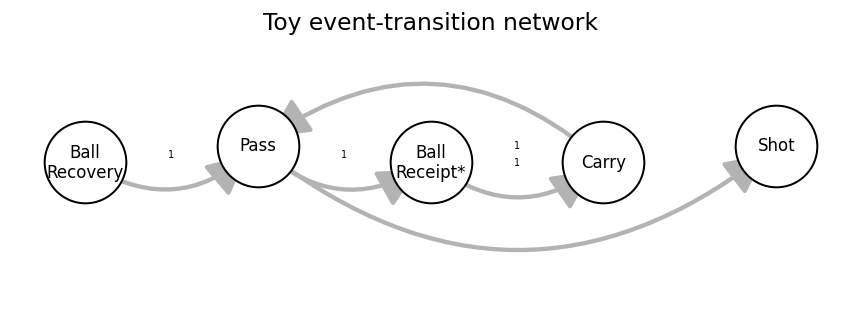

In [28]:
fig, ax = plt.subplots(figsize=(9, 3), dpi=120)

nx.draw_networkx_nodes(
    toy_graph,
    toy_layout,
    node_size=2400,
    node_color="white",
    edgecolors="black",
    linewidths=1.2,
    ax=ax,
)

lab_dict = {i:i.replace(' ','\n') for i in toy_graph.nodes()}
nx.draw_networkx_labels(toy_graph, toy_layout,
                        labels=lab_dict,
                        font_size=10, ax=ax)

nx.draw_networkx_edges(
    toy_graph,
    toy_layout,
    arrows=True,
    arrowstyle="-|>",
    edge_color='.7',
    arrowsize=50,
    width=2.6,
    connectionstyle="arc3,rad=0.4",
    ax=ax,
)

edge_labels = {(u, v): d["weight"] for u, v, d in toy_graph.edges(data=True)}
nx.draw_networkx_edge_labels(
    toy_graph,
    toy_layout,
    edge_labels=edge_labels,
    font_size='xx-small',
    rotate=False,
    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8),
    ax=ax,
)

ax.set_title("Toy event-transition network")
ax.axis("off")
plt.show()

In the toy example, the adjacency matrix records **counts**. It tells us how many times each transition was observed.

The transition matrix records **conditional probabilities**. It answers a different question:

> if the current state is `Pass`, what is the probability distribution over the next state?

That is why row normalization is natural for a first-order transition model.

If a row sum is zero, then that state was only observed as an endpoint in the extracted sequences, so there is no outgoing distribution to normalize.


## 6. Why segmentation matters: whole-stream, team-filtered, possession-based, and coupled sequences

This is one of the most important sections in the notebook!!!

Different segmentation rules produce different networks because they answer different questions. To see that clearly, start with a tiny stylized event stream. Imagine the following ordered events appear around one Argentina possession:

1. `Argentina: Pass`
2. `France: Pressure`
3. `Argentina: Ball Receipt*`
4. `Argentina: Carry`
5. `France: Foul Committed`
6. `Argentina: Foul Won`

Now ask four different questions.

- **Whole stream:** connect every consecutive row in the log.
- **Team filtered:** keep only Argentina rows and connect the remaining sequence.
- **Possession based:** keep Argentina rows, but reset the sequence at possession boundaries.
- **Coupled possession view:** keep all rows inside the possession block, including opponent defensive actions.

Those are all legitimate. They are just not the same model.


In [29]:
seg_demo_df = pd.DataFrame(
    {
        "index": [1, 2, 3, 4, 5, 6, 7, 8],
        "possession": [10, 10, 10, 10, 10, 10, 11, 11],
        "team": ["Argentina", "France", "Argentina", "Argentina", "France", "Argentina", "France", "France"],
        "state": ["Pass", "Pressure", "Ball Receipt*", "Carry", "Foul Committed", "Foul Won", "Ball Recovery", "Pass"],
    }
)
display(seg_demo_df)


,index,possession,team,state
0,1,10,Argentina,Pass
1,2,10,France,Pressure
2,3,10,Argentina,Ball Receipt*
3,4,10,Argentina,Carry
4,5,10,France,Foul Committed
5,6,10,Argentina,Foul Won
6,7,11,France,Ball Recovery
7,8,11,France,Pass


In [30]:
whole_stream_sequence = seg_demo_df.sort_values("index")["state"].tolist()

print("Whole stream sequence:")
print(whole_stream_sequence)
print()


Whole stream sequence:
['Pass', 'Pressure', 'Ball Receipt*', 'Carry', 'Foul Committed', 'Foul Won', 'Ball Recovery', 'Pass']



In [31]:
argentina_only_sequence = (
    seg_demo_df.loc[seg_demo_df["team"].eq("Argentina")]
    .sort_values("index")["state"].tolist()
)

print("Argentina-only sequence:")
print(argentina_only_sequence)
print()

Argentina-only sequence:
['Pass', 'Ball Receipt*', 'Carry', 'Foul Won']



In [32]:
argentina_possession_sequences = []
for _, group in seg_demo_df.loc[seg_demo_df["team"].eq("Argentina")].sort_values("index").groupby("possession", sort=False):
    argentina_possession_sequences.append(group["state"].tolist())

print("Argentina-only, broken by possession:")
print(argentina_possession_sequences)
print()

Argentina-only, broken by possession:
[['Pass', 'Ball Receipt*', 'Carry', 'Foul Won']]



In [33]:
coupled_possession_sequences = []
for _, group in seg_demo_df.sort_values("index").groupby("possession", sort=False):
    coupled_possession_sequences.append(group["team"] + ": " + group["state"])

print("Coupled sequences with both teams kept:")
for seq in coupled_possession_sequences:
    print(list(seq))


Coupled sequences with both teams kept:
['Argentina: Pass', 'France: Pressure', 'Argentina: Ball Receipt*', 'Argentina: Carry', 'France: Foul Committed', 'Argentina: Foul Won']
['France: Ball Recovery', 'France: Pass']


In [34]:
real_possession_example = (
    events_df.loc[events_df["possession"].eq(3), [
        "index",
        "period",
        "timestamp",
        "team_name",
        "possession_team_name",
        "event_type",
        "player_name",
        "play_pattern_name",
        "under_pressure",
        "pass_outcome_name",
        "ball_receipt_outcome_name",
    ]]
    .sort_values("index")
    .reset_index(drop=True)
)

real_possession_example

,index,period,timestamp,team_name,possession_team_name,event_type,player_name,play_pattern_name,under_pressure,pass_outcome_name,ball_receipt_outcome_name
0,10,1,00:00:16.423,Argentina,Argentina,Pass,Nahuel Molina Lucero,From Throw In,False,NaN,NaN
1,11,1,00:00:17.350,France,Argentina,Pressure,Adrien Rabiot,From Throw In,False,NaN,NaN
2,12,1,00:00:17.546,Argentina,Argentina,Ball Receipt*,Rodrigo Javier De Paul,From Throw In,True,NaN,NaN
3,13,1,00:00:17.546,Argentina,Argentina,Carry,Rodrigo Javier De Paul,From Throw In,True,NaN,NaN
4,14,1,00:00:19.005,France,Argentina,Foul Committed,Adrien Rabiot,From Throw In,False,NaN,NaN
5,15,1,00:00:19.005,Argentina,Argentina,Foul Won,Rodrigo Javier De Paul,From Throw In,True,NaN,NaN


Even though `possession_team_name` remains `Argentina`, opponent events still appear inside the same block. In other words:

- `possession_team_name` does **not** mean every event in that block is by the same team,
- and a possession segment can still contain tackles, pressures, fouls, or other opponent actions before the data declare a new possession.

So when we say "build a possession-based event network," we still need to ask:

- Do we keep only the focus team's own actions?
- Or do we keep the opponent actions that occur inside the possession?

That choice changes the object we are modeling.


## Part I — From Event Logs to Coarse Event-Transition Networks


### Starting class with a hands-on challenge / refresher:
1. In groups, load the statsbomb event data.
2. Create the events_df object.
3. Examine one full `possession`
    - Print the sequence of events that makes up that possession.


### Another challenge: What did we decide to do with `pressure` events?


### Another (!) challenge: Now let's use `networkx`

No longer in groups, you will need to coach me about how to construct a networkx object that corresponds to this event transition network. 

1. What should step 1 be?
2. ...


## 7. Build a first real event-transition network using coarse states

We now build the first main network slowly.

### Baseline design

To keep the first network readable, we will use the following modeling choices:

- **focus team:** Argentina,
- **time window:** first half only,
- **segmentation:** within possessions,
- **team filter:** keep Argentina's own gameplay actions only,
- **state definition:** coarse state = raw `event_type`,
- **boundary rule:** no edges crossing possession boundaries.

This gives us a one-team, possession-segmented, coarse event-transition network.


In [48]:
TEAM_ACTION_TYPES = {
    "50/50",
    "Ball Recovery",
    "Ball Receipt*",
    "Block",
    "Carry",
    "Clearance",
    "Dispossessed",
    "Dribble",
    "Duel",
    "Foul Committed",
    "Foul Won",
    "Goal Keeper",
    "Interception",
    "Miscontrol",
    "Offside",
    "Pass",
    "Shot",
}

In [49]:
baseline_df = (
    events_df.loc[
        events_df["is_gameplay"]
        & events_df["period"].eq(1)
        & events_df["team_name"].eq(MAIN_TEAM)
        & events_df["possession_team_name"].eq(MAIN_TEAM)
        & events_df["event_type"].isin(TEAM_ACTION_TYPES)
    ]
    .sort_values("index")
    .copy()
)

baseline_summary = pd.DataFrame(
    [
        {
            "selected_events": len(baseline_df),
            "selected_possessions": int(baseline_df["possession"].nunique()),
            "unique_event_types": int(baseline_df["event_type"].nunique()),
            "periods_kept": sorted(baseline_df["period"].unique().tolist()),
        }
    ]
)

display(baseline_summary)

,selected_events,selected_possessions,unique_event_types,periods_kept
0,883,41,16,[1]


In [50]:
display(
    baseline_df[
        [
            "index",
            "possession",
            "team_name",
            "event_type",
            "player_name",
            "play_pattern_name",
            "under_pressure",
            "pass_outcome_name",
            "ball_receipt_outcome_name",
        ]
    ].head(20)
)

,index,possession,team_name,event_type,player_name,play_pattern_name,under_pressure,pass_outcome_name,ball_receipt_outcome_name
9,10,3,Argentina,Pass,Nahuel Molina Lucero,From Throw In,False,NaN,NaN
11,12,3,Argentina,Ball Receipt*,Rodrigo Javier De Paul,From Throw In,True,NaN,NaN
12,13,3,Argentina,Carry,Rodrigo Javier De Paul,From Throw In,True,NaN,NaN
14,15,3,Argentina,Foul Won,Rodrigo Javier De Paul,From Throw In,True,NaN,NaN
15,16,4,Argentina,Pass,Rodrigo Javier De Paul,From Free Kick,False,NaN,NaN
16,17,4,Argentina,Ball Receipt*,Cristian Gabriel Romero,From Free Kick,False,NaN,NaN
17,18,4,Argentina,Carry,Cristian Gabriel Romero,From Free Kick,False,NaN,NaN
18,19,4,Argentina,Pass,Cristian Gabriel Romero,From Free Kick,False,NaN,NaN
19,20,4,Argentina,Ball Receipt*,Nicolás Hernán Otamendi,From Free Kick,False,NaN,NaN
20,21,4,Argentina,Carry,Nicolás Hernán Otamendi,From Free Kick,False,NaN,NaN


In [47]:
baseline_event_counts = (
    baseline_df["event_type"]
    .value_counts()
    .rename_axis("event_type")
    .reset_index(name="count")
)

baseline_event_counts


,event_type,count
0,Pass,297
1,Ball Receipt*,286
2,Carry,229
3,Ball Recovery,14
4,Dribble,12
5,Foul Won,8
6,Duel,7
7,Shot,6
8,Miscontrol,6
9,Block,5


We want to see:

- which rows were kept,
- which possessions remain,
- and which coarse event types dominate the selected slice.

As in earlier soccer notebooks, the same match file can support very different models. Here the model is deliberately narrower than the full event log.

In [51]:
baseline_sequences = []

for possession_id, group in baseline_df.groupby("possession", sort=False):
    group = group.sort_values("index")
    seq = group["event_type"].tolist()
    baseline_sequences.append(seq)

n_preview = min(len(baseline_sequences), 7)

baseline_sequence_preview = pd.DataFrame(
    {
        "possession_number_in_slice": range(1, n_preview + 1),
        "sequence": [" → ".join(seq) for seq in baseline_sequences[:n_preview]],
        "sequence_length": [len(seq) for seq in baseline_sequences[:n_preview]],
    }
)

baseline_sequence_preview


,possession_number_in_slice,sequence,sequence_length
0,1,Pass → Ball Receipt* → Carry → Foul Won,4
1,2,Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → ...,19
2,3,Pass → Ball Receipt* → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → ...,18
3,4,Pass → Ball Receipt* → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Recovery → Carry → ...,19
4,5,Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Foul Won,9
5,6,Pass → Ball Receipt* → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → ...,30
6,7,Pass → Ball Receipt* → Carry → Pass → Ball Receipt*,5


### Seeing possessions as local sequences

The text preview above is already useful, but a strip view makes the next modeling move easier to see.

Each row below will be one possession sequence. The event-transition network later takes all of those rows and aggregates their adjacent pairs.

That is why two descriptive questions are worth asking before we count a single edge:

- how long are the possessions in this slice,
- and what do representative sequences look like for each team?

In [52]:
argentina_h1_possession_rows = []

for possession_id, group in baseline_df.groupby("possession", sort=False):
    seq = group.sort_values("index")["event_type"].tolist()
    argentina_h1_possession_rows.append(
        {
            "team": MAIN_TEAM,
            "possession": int(possession_id),
            "length": len(seq),
            "sequence": seq,
            "sequence_preview": " → ".join(seq[:12]) + (" → …" if len(seq) > 12 else ""),
        }
    )

argentina_h1_possessions = pd.DataFrame(argentina_h1_possession_rows)


In [53]:
france_h1_sequence_source = (
    events_df.loc[
        events_df["is_gameplay"]
        & events_df["period"].eq(1)
        & events_df["team_name"].eq(OTHER_TEAM)
        & events_df["possession_team_name"].eq(OTHER_TEAM)
        & events_df["event_type"].isin(TEAM_ACTION_TYPES)
    ]
    .sort_values("index")
    .copy()
)

france_h1_possession_rows = []

for possession_id, group in france_h1_sequence_source.groupby("possession", sort=False):
    seq = group.sort_values("index")["event_type"].tolist()
    france_h1_possession_rows.append(
        {
            "team": OTHER_TEAM,
            "possession": int(possession_id),
            "length": len(seq),
            "sequence": seq,
            "sequence_preview": " → ".join(seq[:12]) + (" → …" if len(seq) > 12 else ""),
        }
    )

france_h1_possessions = pd.DataFrame(france_h1_possession_rows)


In [54]:
sequence_length_summary = pd.DataFrame(
    [
        {
            "team": MAIN_TEAM,
            "possessions": len(argentina_h1_possessions),
            "mean_length": argentina_h1_possessions["length"].mean(),
            "median_length": argentina_h1_possessions["length"].median(),
            "75th_pct_length": argentina_h1_possessions["length"].quantile(0.75),
            "max_length": argentina_h1_possessions["length"].max(),
        },
        {
            "team": OTHER_TEAM,
            "possessions": len(france_h1_possessions),
            "mean_length": france_h1_possessions["length"].mean(),
            "median_length": france_h1_possessions["length"].median(),
            "75th_pct_length": france_h1_possessions["length"].quantile(0.75),
            "max_length": france_h1_possessions["length"].max(),
        },
    ]
)

sequence_length_summary.round(2)

,team,possessions,mean_length,median_length,75th_pct_length,max_length
0,Argentina,41,21.54,14.0,30.0,104
1,France,37,15.00,10.0,19.0,46


In [55]:
display(
    argentina_h1_possessions.sort_values(["length", "possession"], ascending=[False, True])
    .head(6)[["possession", "length", "sequence_preview"]]
)

display(
    france_h1_possessions.sort_values(["length", "possession"], ascending=[False, True])
    .head(6)[["possession", "length", "sequence_preview"]]
)

,possession,length,sequence_preview
24,50,104,Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Miscontrol → Duel → Carry → Pass → Ball Receipt* → Int...
14,31,90,Pass → Ball Receipt* → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → ...
12,25,54,Duel → Ball Recovery → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → ...
10,21,51,Ball Recovery → Carry → Pass → Ball Receipt* → Block → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Pass → ...
22,46,51,Interception → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → ...
26,55,43,Duel → Carry → Pass → Ball Receipt* → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Rece...


,possession,length,sequence_preview
5,15,46,Pass → Duel → Ball Recovery → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Rece...
12,28,44,Pass → Duel → Ball Recovery → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Rece...
32,69,41,Ball Recovery → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → ...
27,57,38,Pass → Ball Receipt* → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Dispossessed → Duel → Carry → P...
6,16,35,Pass → Ball Receipt* → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → ...
31,66,27,Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → ...


In [72]:
from matplotlib.patches import Patch

coarse_sequence_states = sorted(
    set(sum(argentina_h1_possessions["sequence"].tolist(), []))
    | set(sum(france_h1_possessions["sequence"].tolist(), []))
)

tab20_colors = list(plt.cm.tab20.colors)
state_color_map = {state: tab20_colors[i % len(tab20_colors)] for i, state in enumerate(coarse_sequence_states)}


def plot_possession_strip_view(ax, possession_df, title, state_color_map, max_possessions=14, max_steps=40):
    """Draw a compact strip view of possession sequences."""
    plot_df = (
        possession_df.sort_values(["length", "possession"], ascending=[False, True])
        .head(max_possessions)
        .reset_index(drop=True)
        .copy()
    )

    for row_idx, row in plot_df.iterrows():
        truncated = row["sequence"][:max_steps]

        for step_idx, state in enumerate(truncated):
            ax.add_patch(
                Rectangle(
                    (step_idx, row_idx),
                    1.0,
                    0.72,
                    facecolor=state_color_map.get(state, "#cccccc"),
                    edgecolor="white",
                    linewidth=0.5,
                )
            )

        ax.text(
            -1.2,
            row_idx + 0.36,
            f"{int(row['possession'])} ({int(row['length'])})",
            ha="right",
            va="center",
            fontsize=8.5,
        )

        if row["length"] > max_steps:
            ax.text(max_steps + 0.15, row_idx + 0.36, "…", ha="left", va="center", fontsize=12)

    for x in range(0, max_steps + 1, 5):
        ax.axvline(x, color="#dddddd", linewidth=0.6, zorder=0)

    ax.set_xlim(-0.7, max_steps + 0.8)
    ax.set_ylim(0, len(plot_df))
    ax.invert_yaxis()
    ax.set_yticks([])
    ax.set_xticks(range(0, max_steps + 1, 5))
    ax.set_xlabel(f"Event position within possession (first {max_steps} states shown)")
    ax.set_title(title)

    return plot_df

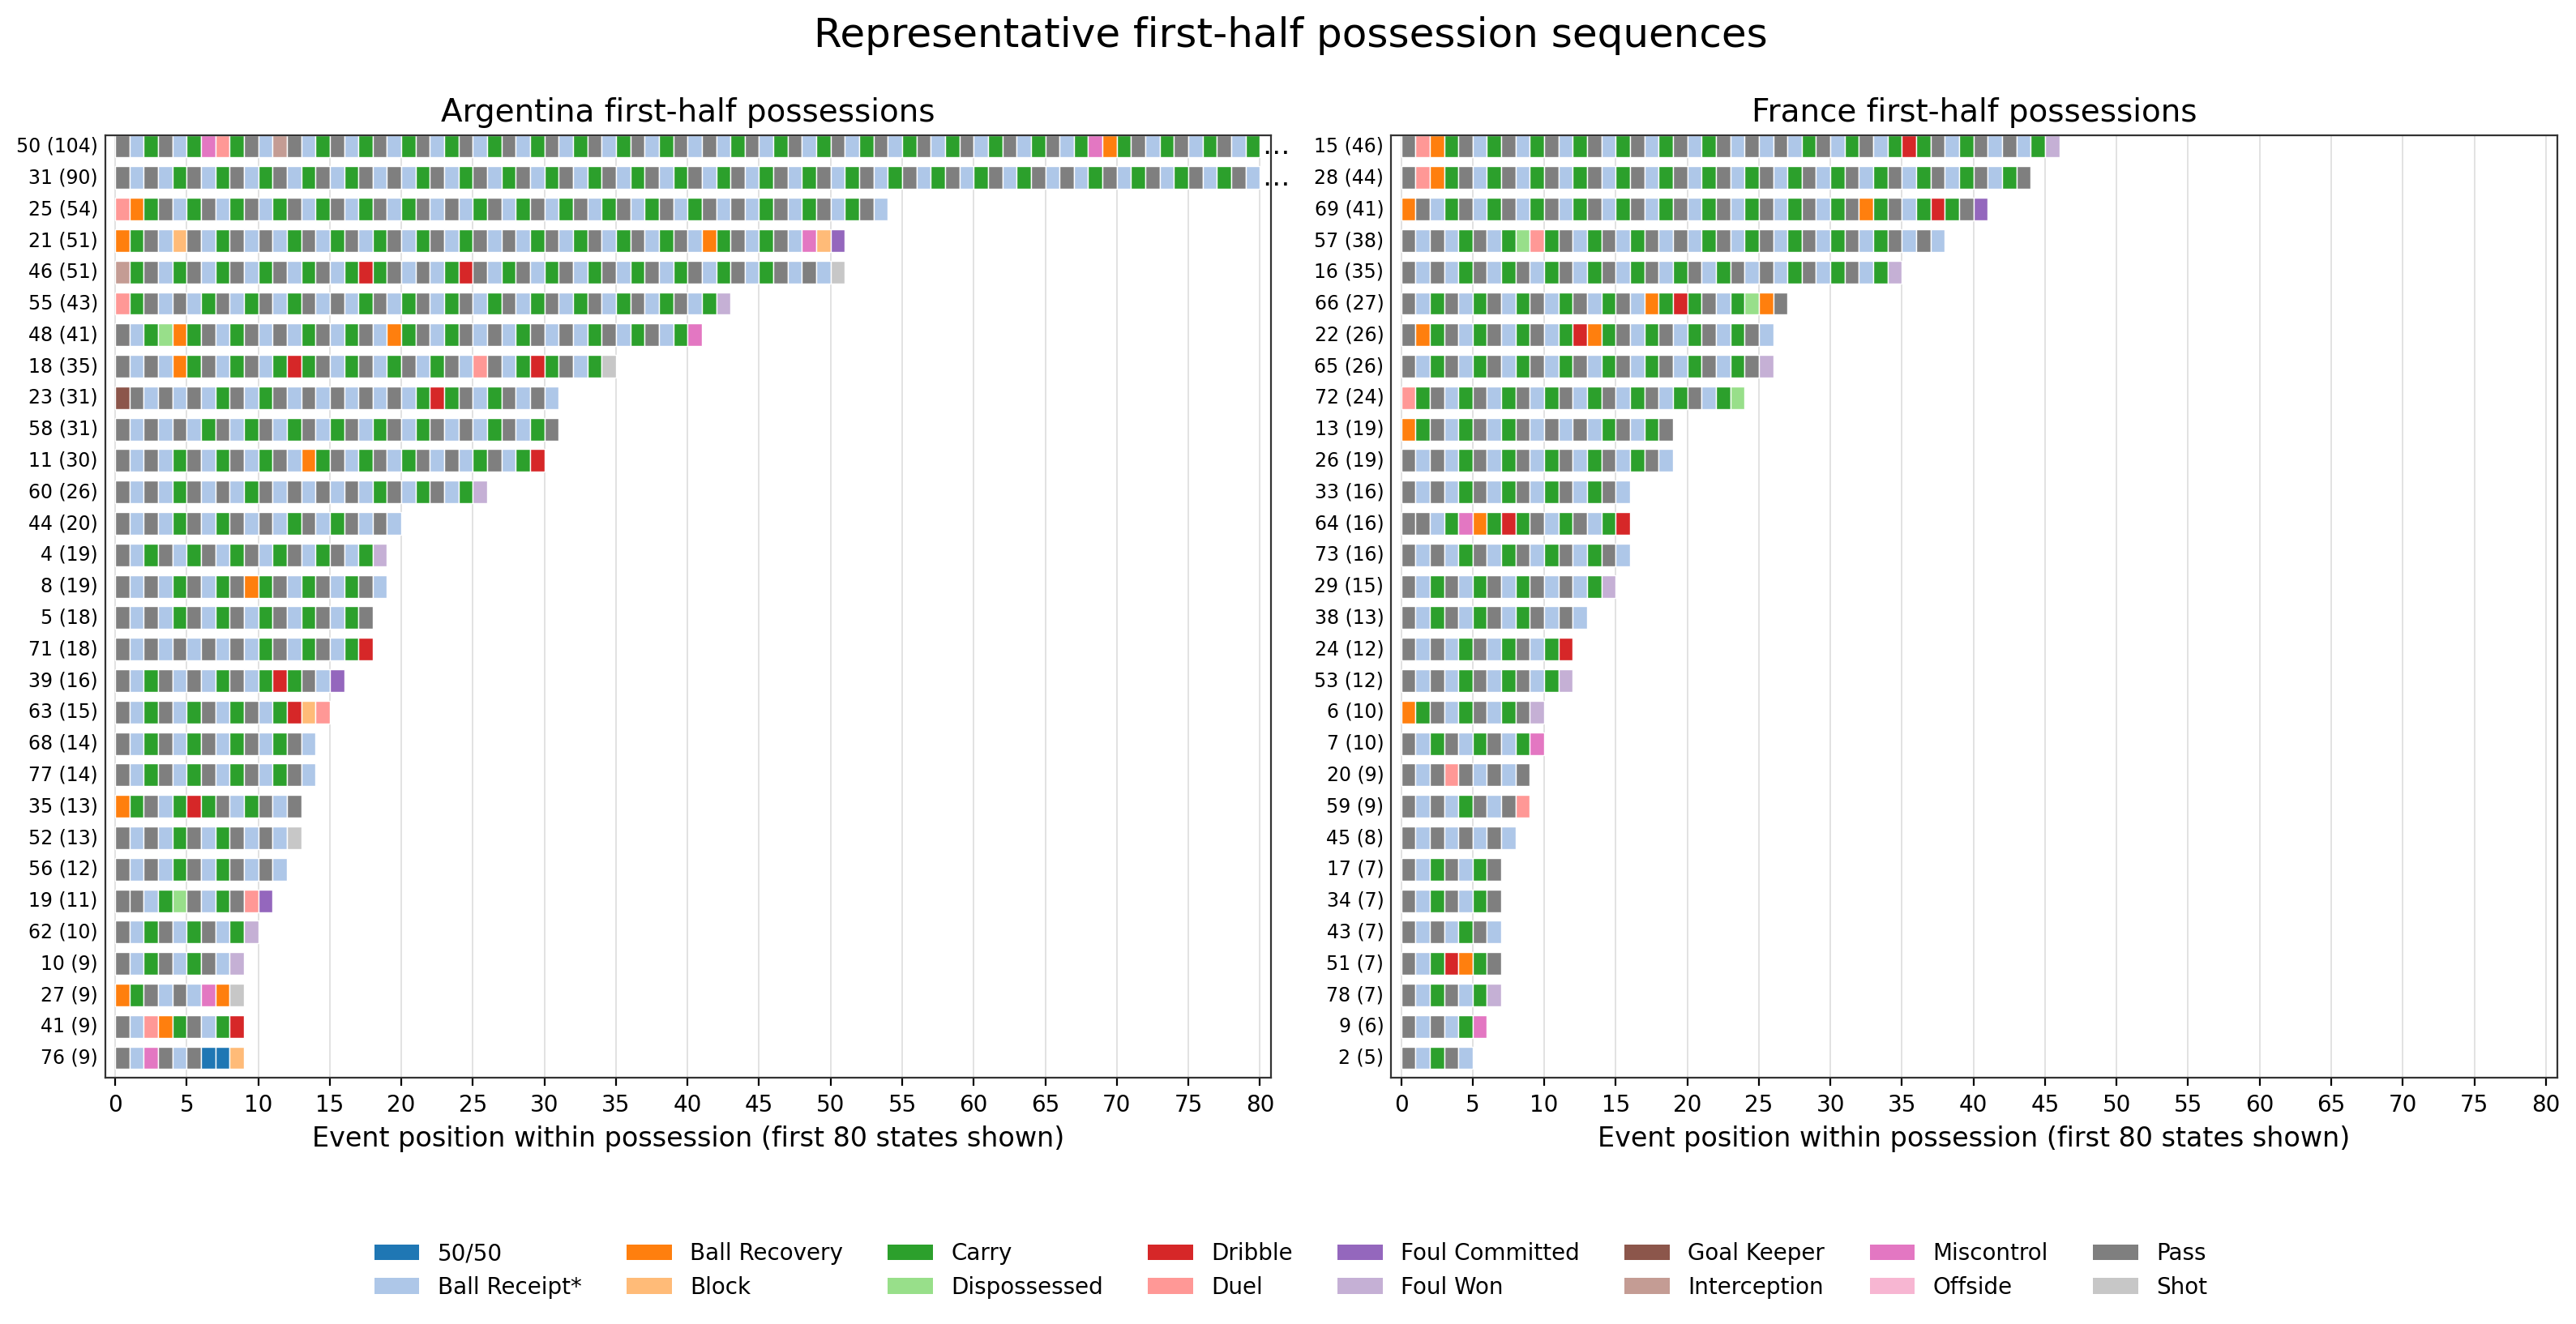

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=200, sharex=True)
plt.subplots_adjust(wspace=0.4)

argentina_sequence_subset = plot_possession_strip_view(
    axes[0],
    argentina_h1_possessions,
    f"{MAIN_TEAM} first-half possessions",
    state_color_map,
    max_possessions=30,
    max_steps=80,
)

france_sequence_subset = plot_possession_strip_view(
    axes[1],
    france_h1_possessions,
    f"{OTHER_TEAM} first-half possessions",
    state_color_map,
    max_possessions=30,
    max_steps=80,
)

legend_handles = [Patch(facecolor=state_color_map[state], label=state) for state in coarse_sequence_states]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=8,
    frameon=False,
    bbox_to_anchor=(0.5, -0.03),
)

fig.suptitle("Representative first-half possession sequences", fontsize=18, y=0.975)
plt.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.show()

This figure is not a network yet.

It is the raw sequential material from which the network will be built. A few immediate patterns stand out:

- many possessions begin with `Pass`,
- the common on-ball chain `Pass → Ball Receipt* → Carry` appears over and over,
- possession length varies a great deal,
- and the long right tails remind us that one aggregated network will collapse together both short and long sequences.

That aggregation is useful, but it always hides some local ordering detail.

In [74]:
manual_pairs = []

for seq in baseline_sequences:
    if len(seq) >= 2:
        manual_pairs.extend(zip(seq[:-1], seq[1:]))

manual_pair_table = pd.DataFrame(manual_pairs, columns=["source", "target"])

manual_edge_table = (
    manual_pair_table
    .value_counts()
    .rename("weight")
    .reset_index()
    .sort_values(["weight", "source", "target"], ascending=[False, True, True])
    .reset_index(drop=True)
)

manual_edge_table.head(20)


,source,target,weight
0,Pass,Ball Receipt*,286
1,Ball Receipt*,Carry,206
2,Carry,Pass,202
3,Ball Receipt*,Pass,52
4,Ball Recovery,Carry,13
5,Carry,Dribble,12
6,Dribble,Carry,7
7,Carry,Foul Won,6
8,Ball Receipt*,Ball Recovery,4
9,Carry,Dispossessed,4


In [77]:
coarse_states = sorted(pd.unique(pd.concat([manual_edge_table["source"], manual_edge_table["target"]], ignore_index=True)))

coarse_adjacency = pd.DataFrame(0, index=coarse_states, columns=coarse_states, dtype=int)
display(coarse_adjacency)

,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Dispossessed,Dribble,Duel,Foul Committed,Foul Won,Goal Keeper,Interception,Miscontrol,Offside,Pass,Shot
50/50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Ball Receipt*,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Ball Recovery,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Block,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Carry,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Dispossessed,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Dribble,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Duel,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Foul Committed,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Foul Won,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [78]:
for row in manual_edge_table.itertuples(index=False):
    coarse_adjacency.loc[row.source, row.target] = int(row.weight)

coarse_network_summary = pd.DataFrame(
    [
        {
            "states": coarse_adjacency.shape[0],
            "edges_with_positive_weight": int((coarse_adjacency.to_numpy() > 0).sum()),
            "total_recorded_transitions": int(coarse_adjacency.to_numpy().sum()),
            "density": (coarse_adjacency.to_numpy() > 0).sum() / (coarse_adjacency.shape[0] ** 2),
        }
    ]
)

display(coarse_network_summary)


,states,edges_with_positive_weight,total_recorded_transitions,density
0,16,46,842,0.179688


In [80]:
coarse_row_sums = coarse_adjacency.sum(axis=1)
nonzero_rows = coarse_row_sums > 0
display(coarse_row_sums.rename("row_sum").to_frame())

,row_sum
50/50,2
Ball Receipt*,274
Ball Recovery,14
Block,4
Carry,229
Dispossessed,4
Dribble,9
Duel,6
Foul Committed,0
Foul Won,0


In [81]:
coarse_transition = coarse_adjacency.div(coarse_row_sums.replace(0, np.nan), axis=0).fillna(0.0)
display(coarse_transition.round(3))


,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Dispossessed,Dribble,Duel,Foul Committed,Foul Won,Goal Keeper,Interception,Miscontrol,Offside,Pass,Shot
50/50,0.500,0.000,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.00,0.000,0.000
Ball Receipt*,0.000,0.000,0.015,0.004,0.752,0.000,0.000,0.007,0.004,0.007,0.0,0.004,0.011,0.00,0.190,0.007
Ball Recovery,0.000,0.000,0.000,0.000,0.929,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.00,0.000,0.071
Block,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.250,0.250,0.000,0.0,0.000,0.000,0.25,0.250,0.000
Carry,0.000,0.000,0.000,0.000,0.000,0.017,0.052,0.000,0.000,0.026,0.0,0.000,0.013,0.00,0.882,0.009
Dispossessed,0.000,0.000,0.250,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.00,0.750,0.000
Dribble,0.000,0.000,0.000,0.111,0.778,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.00,0.111,0.000
Duel,0.000,0.000,0.333,0.000,0.333,0.000,0.000,0.000,0.167,0.000,0.0,0.000,0.000,0.00,0.167,0.000
Foul Committed,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.00,0.000,0.000
Foul Won,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.00,0.000,0.000


The adjacency matrix and the transition matrix answer different questions.

- The adjacency matrix says **how many** transitions were observed.
- The transition matrix says **where the process tends to go next**, conditional on the current state.

That difference is one of the main conceptual payoffs of this notebook.


## 8. Visualizing the coarse event-transition network well

A full event-state network can become unreadable very quickly. So we will use several views instead of one giant hairball:

- a table of the strongest edges,
- a heatmap of the count matrix,
- a heatmap of the row-normalized transition matrix,
- a readable directed subgraph built from the most active states,
- and focused views of the outgoing transitions from selected states.

Different views answer different questions. A matrix shows all pairwise structure compactly. A graph drawing shows directional flow and neighborhood structure, but only for a filtered subset if we want the figure to remain legible.


In [82]:
manual_edge_table.head(15)

,source,target,weight
0,Pass,Ball Receipt*,286
1,Ball Receipt*,Carry,206
2,Carry,Pass,202
3,Ball Receipt*,Pass,52
4,Ball Recovery,Carry,13
5,Carry,Dribble,12
6,Dribble,Carry,7
7,Carry,Foul Won,6
8,Ball Receipt*,Ball Recovery,4
9,Carry,Dispossessed,4


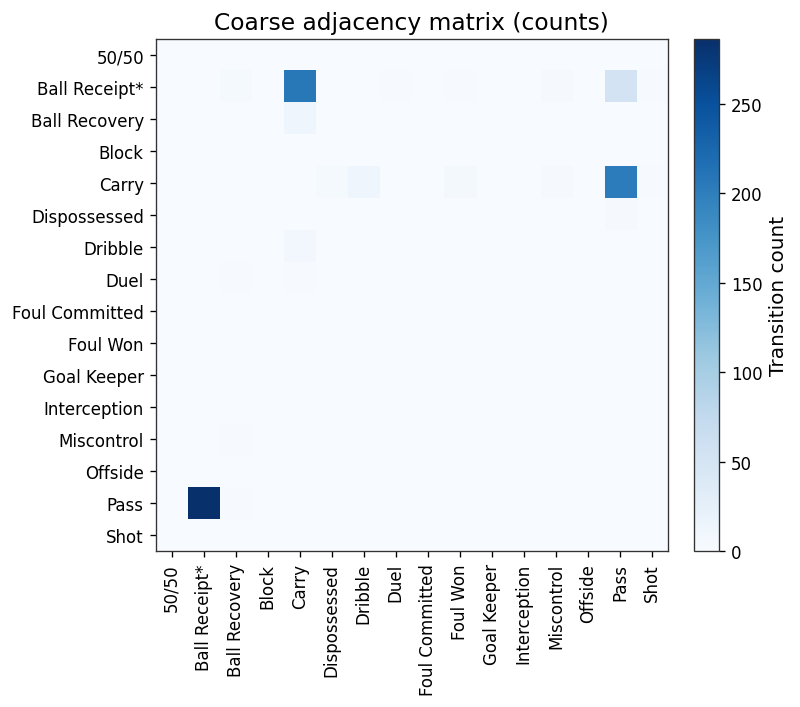

In [88]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

im = ax.imshow(coarse_adjacency, cmap="Blues")

ax.set_xticks(range(len(coarse_states)))
ax.set_xticklabels(coarse_states, rotation=90)
ax.set_yticks(range(len(coarse_states)))
ax.set_yticklabels(coarse_states)
ax.set_title("Coarse adjacency matrix (counts)")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Transition count")

plt.tight_layout()
plt.show()

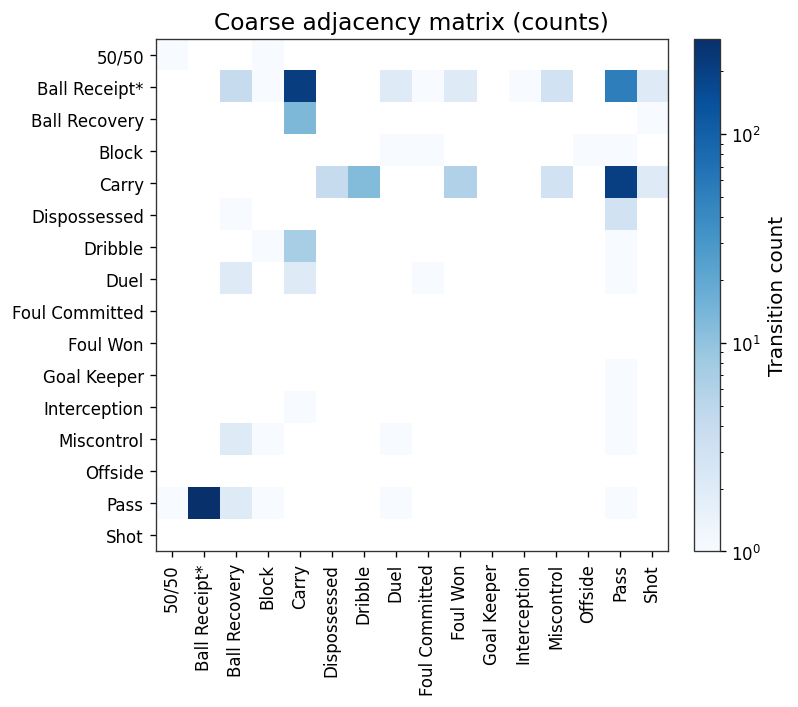

In [91]:
from matplotlib.colors import LogNorm

A = coarse_adjacency.to_numpy(dtype=float)
A = np.ma.masked_less_equal(A, 0)            # mask zeros/nonpositive entries

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

im = ax.imshow(
    A,
    cmap="Blues",
    norm=LogNorm(vmin=A.min(), vmax=A.max())
)

ax.set_xticks(range(len(coarse_states)))
ax.set_xticklabels(coarse_states, rotation=90)
ax.set_yticks(range(len(coarse_states)))
ax.set_yticklabels(coarse_states)
ax.set_title("Coarse adjacency matrix (counts)")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Transition count")

plt.tight_layout()
plt.show()

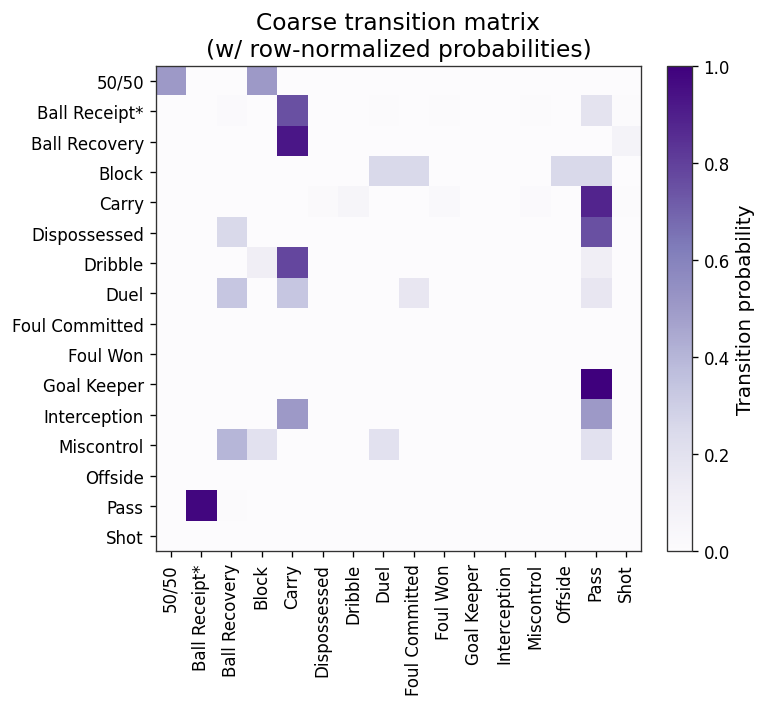

In [92]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=120)

im = ax.imshow(coarse_transition, cmap="Purples", vmin=0, vmax=1)

ax.set_xticks(range(len(coarse_states)))
ax.set_xticklabels(coarse_states, rotation=90)
ax.set_yticks(range(len(coarse_states)))
ax.set_yticklabels(coarse_states)
ax.set_title("Coarse transition matrix\n(w/ row-normalized probabilities)")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Transition probability")

plt.tight_layout()
plt.show()


The two heatmaps emphasize different things.

The adjacency matrix tells us where volume lives. In this slice, a few transitions dominate the total count.

The transition matrix tells us where the process tends to go next given the current state. In that view, a row becomes a conditional distribution. For example, the row for `Pass` is not about all passes in the match. It is about what happened immediately after a pass in the selected sequences.


In [124]:
top_states_for_graph = (
    baseline_df["event_type"]
    .value_counts()
    .head(8)
    .index
    .tolist()
)

graph_edge_subset = manual_edge_table.loc[
    manual_edge_table["source"].isin(top_states_for_graph)
    & manual_edge_table["target"].isin(top_states_for_graph)
    & manual_edge_table["weight"].ge(3)
].copy()

assert not graph_edge_subset.empty

In [125]:
readable_graph = nx.DiGraph()

for row in graph_edge_subset.itertuples(index=False):
    readable_graph.add_edge(row.source, row.target, weight=row.weight)

layout = nx.circular_layout(readable_graph)

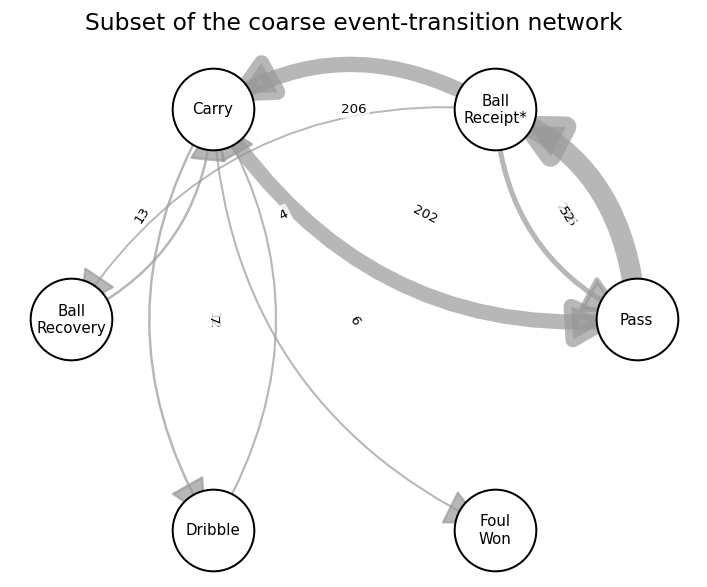

In [126]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=120)

nx.draw_networkx_nodes(
    readable_graph,
    layout,
    node_size=2400,
    node_color="white",
    edgecolors="black",
    linewidths=1.2,
    ax=ax,
)

lab_dict = {i:i.replace(' ','\n') for i in readable_graph.nodes()}
nx.draw_networkx_labels(readable_graph, layout,
                        labels=lab_dict,
                        font_size=9, ax=ax)

edge_widths = [1.0 + 0.04 * readable_graph[u][v]["weight"] for u, v in readable_graph.edges()]
nx.draw_networkx_edges(
    readable_graph,
    layout,
    width=edge_widths,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=50,
    edge_color='.6',
    connectionstyle="arc3,rad=0.3",
    alpha=0.7,
    ax=ax,
)

edge_labels = {(u, v): d["weight"] for u, v, d in readable_graph.edges(data=True)}
nx.draw_networkx_edge_labels(
    readable_graph,
    layout,
    edge_labels=edge_labels,
    font_size=8,
#     rotate=False,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
    ax=ax,
)

ax.set_title("Subset of the coarse event-transition network")
ax.axis("off")
plt.tight_layout()
plt.show()

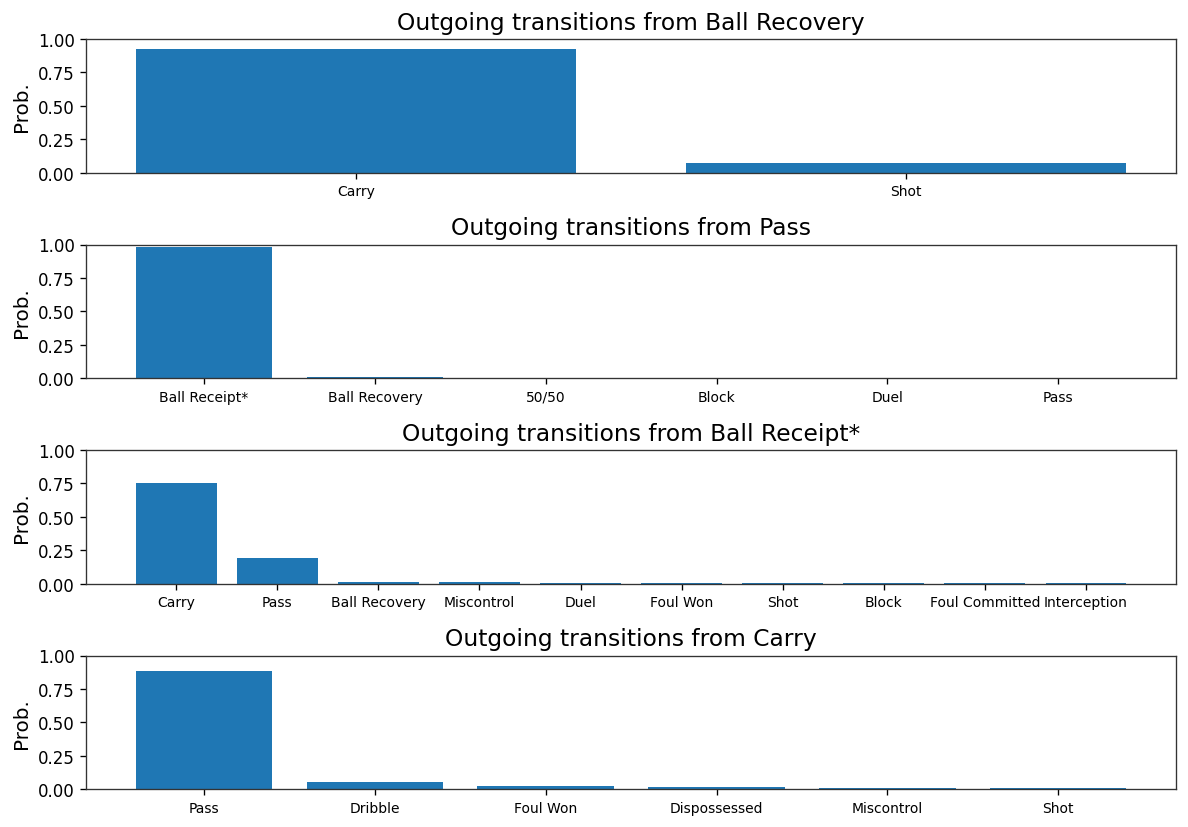

In [127]:
focus_states = ["Ball Recovery", "Pass", "Ball Receipt*", "Carry"]

fig, axes = plt.subplots(len(focus_states), 1, figsize=(10, 7), dpi=120)

for ax, state in zip(axes, focus_states):
    row = coarse_transition.loc[state]
    row = row[row > 0].sort_values(ascending=False)
    ax.bar(row.index, row.values)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Prob.")
    ax.set_title(f"Outgoing transitions from {state}")
    ax.tick_params(axis="x", labelsize='small')

plt.tight_layout()
plt.show()


These outgoing-transition views are often more interpretable than the full graph.

A row like `Ball Recovery` is a compact tactical statement: once a recovery occurs, what are the team's immediate next actions in this representation?

A row like `Carry` captures branching. Does carrying mostly lead to another pass? Does it often branch toward dribbles, fouls won, or shots? The answer depends on the state definition and the segmentation rule.


### A coupled two-team view with turnover bridges

The matrices and one-team subgraph above describe Argentina's own action grammar. A different visualization question is about interaction:

> when possession changes hands, which kinds of states tend to hand over to which kinds of states?

For one readable coupled view, we will widen the window to regulation, keep each team's own on-ball actions within its possessions, and then add a cross-team bridge whenever one team's possession is followed by the other team's possession.

That bridge rule is explicit:

- source = the last own-team state of the outgoing possession,
- target = the first own-team state of the incoming possession,
- and only boundaries with a change in possession team count as turnover bridges.

In [128]:
regulation_onball_df = (
    events_df.loc[
        events_df["is_gameplay"]
        & events_df["period"].isin([1, 2])
        & events_df["event_type"].isin(TEAM_ACTION_TYPES)
        & events_df["team_name"].eq(events_df["possession_team_name"])
    ]
    .sort_values("index")
    .copy()
)

regulation_onball_df["state"] = regulation_onball_df["event_type"]

regulation_team_summary = []

for team_name in [MAIN_TEAM, OTHER_TEAM]:
    team_slice = regulation_onball_df.loc[regulation_onball_df["team_name"].eq(team_name)].copy()
    regulation_team_summary.append(
        {
            "team": team_name,
            "events_kept": len(team_slice),
            "possessions": int(team_slice["possession"].nunique()),
            "unique_states": int(team_slice["state"].nunique()),
        }
    )

pd.DataFrame(regulation_team_summary)

,team,events_kept,possessions,unique_states
0,Argentina,1476,86,17
1,France,1283,109,15


In [129]:
team_edges_reg = {}
team_counts_reg = {}

for team_name in [MAIN_TEAM, OTHER_TEAM]:
    team_slice = regulation_onball_df.loc[regulation_onball_df["team_name"].eq(team_name)].copy()
    team_counts_reg[team_name] = team_slice["state"].value_counts()

    team_sequences = []
    for possession_id, group in team_slice.groupby("possession", sort=False):
        seq = group.sort_values("index")["state"].tolist()
        if seq:
            team_sequences.append(seq)

    team_pairs = []
    for seq in team_sequences:
        if len(seq) >= 2:
            team_pairs.extend(zip(seq[:-1], seq[1:]))

    if team_pairs:
        team_edge_table = (
            pd.DataFrame(team_pairs, columns=["source", "target"])
            .value_counts()
            .rename("weight")
            .reset_index()
            .sort_values(["weight", "source", "target"], ascending=[False, True, True])
            .reset_index(drop=True)
        )
    else:
        team_edge_table = pd.DataFrame(columns=["source", "target", "weight"])

    team_edges_reg[team_name] = team_edge_table

regulation_possession_rows = []

for possession_id, group in regulation_onball_df.groupby("possession", sort=False):
    group = group.sort_values("index")
    regulation_possession_rows.append(
        {
            "possession": int(possession_id),
            "team": group["possession_team_name"].iloc[0],
            "start_index": int(group["index"].min()),
            "first_state": group["state"].iloc[0],
            "last_state": group["state"].iloc[-1],
            "length": len(group),
        }
    )

regulation_possessions = pd.DataFrame(regulation_possession_rows).sort_values("start_index").reset_index(drop=True)

turnover_bridge_rows = []

for i in range(len(regulation_possessions) - 1):
    previous_possession = regulation_possessions.iloc[i]
    next_possession = regulation_possessions.iloc[i + 1]

    if previous_possession["team"] == next_possession["team"]:
        continue

    turnover_bridge_rows.append(
        {
            "source_team": previous_possession["team"],
            "source_state": previous_possession["last_state"],
            "target_team": next_possession["team"],
            "target_state": next_possession["first_state"],
        }
    )

turnover_bridge_table = (
    pd.DataFrame(turnover_bridge_rows)
    .value_counts()
    .rename("weight")
    .reset_index()
    .sort_values(
        ["weight", "source_team", "source_state", "target_team", "target_state"],
        ascending=[False, True, True, True, True],
    )
    .reset_index(drop=True)
)

turnover_bridge_summary = pd.DataFrame(
    [
        {
            "regulation possessions": len(regulation_possessions),
            "consecutive possession boundaries": len(regulation_possessions) - 1,
            "team-change boundaries": int(turnover_bridge_table["weight"].sum()),
            "distinct bridge types": int(turnover_bridge_table.shape[0]),
        }
    ]
)

display(turnover_bridge_summary)
display(turnover_bridge_table.head(15))

,regulation possessions,consecutive possession boundaries,team-change boundaries,distinct bridge types
0,195,194,110,31


,source_team,source_state,target_team,target_state,weight
0,France,Ball Receipt*,Argentina,Pass,14
1,Argentina,Ball Receipt*,France,Pass,12
2,France,Pass,Argentina,Pass,8
3,Argentina,Pass,France,Pass,7
4,France,Miscontrol,Argentina,Pass,7
5,Argentina,Shot,France,Pass,6
6,Argentina,Foul Committed,France,Pass,5
7,Argentina,Pass,France,Ball Recovery,5
8,France,Foul Committed,Argentina,Pass,5
9,France,Shot,Argentina,Pass,5


In [130]:
COUPLED_RELATIVE_POSITIONS = {
    "Pass": (0.00, -0.05),
    "Ball Receipt*": (0.08, 0.12),
    "Receive": (0.08, 0.12),
    "Carry": (0.18, 0.28),
    "Move": (0.18, 0.28),
    "Ball Recovery": (0.18, -0.20),
    "Regain": (0.18, -0.20),
    "Dribble": (0.30, 0.32),
    "Miscontrol": (0.28, 0.02),
    "Loss": (0.24, 0.00),
    "Duel": (0.10, -0.02),
    "Contest": (0.10, -0.02),
    "Foul Won": (0.02, -0.22),
    "Foul Committed": (0.10, -0.08),
    "Foul": (0.06, -0.15),
    "Goal Keeper": (0.02, 0.08),
    "Dispossessed": (0.12, -0.12),
    "Interception": (0.14, -0.01),
    "Block": (0.30, -0.04),
    "50/50": (0.18, 0.20),
    "Shot": (0.38, -0.15),
    "Offside": (0.24, -0.18),
    "Clearance": (0.08, -0.06),
}


def build_selected_states(team_counts, bridge_table, top_n=10, min_turnover_weight=3):
    """Choose a readable node set for each side of the coupled graph."""
    selected = {}

    for team_name in [MAIN_TEAM, OTHER_TEAM]:
        base_states = team_counts[team_name].head(top_n).index.tolist()

        turnover_states = bridge_table.loc[
            (
                (bridge_table["source_team"].eq(team_name) | bridge_table["target_team"].eq(team_name))
                & bridge_table["weight"].ge(min_turnover_weight)
            ),
            ["source_state", "target_state"],
        ]

        ordered_states = []
        for state in base_states + turnover_states.to_numpy().ravel().tolist():
            if state in team_counts[team_name].index and state not in ordered_states:
                ordered_states.append(state)

        selected[team_name] = ordered_states

    return selected


def positions_from_state_order(selected_states):
    """Assign deterministic positions to coarse or contracted coupled-state views."""
    positions = {}
    x_centers = {MAIN_TEAM: -1.1, OTHER_TEAM: 1.1}

    for team_name, states in selected_states.items():
        mirror = 1 if team_name == MAIN_TEAM else -1
        fallback_states = [state for state in states if state not in COUPLED_RELATIVE_POSITIONS]
        fallback_y = np.linspace(0.82, -0.82, len(fallback_states)) if fallback_states else []
        fallback_map = dict(zip(fallback_states, fallback_y))

        for state in states:
            if state in COUPLED_RELATIVE_POSITIONS:
                rel_x, rel_y = COUPLED_RELATIVE_POSITIONS[state]
                positions[(team_name, state)] = (x_centers[team_name] + mirror * rel_x, rel_y)
            else:
                positions[(team_name, state)] = (x_centers[team_name], float(fallback_map[state]))

    return positions


def draw_coupled_event_network(
    ax,
    team_edges,
    team_counts,
    bridge_table,
    within_threshold=6,
    turnover_threshold=3,
    top_n=10,
    title=None,
):
    """Draw a readable two-team event network with turnover bridges between sides."""
    selected_states = build_selected_states(team_counts, bridge_table, top_n=top_n, min_turnover_weight=turnover_threshold)
    positions = positions_from_state_order(selected_states)

    team_colors = {MAIN_TEAM: "#2c6cb0", OTHER_TEAM: "#e06c2f"}
    turnover_color = "#b77fc8"

    bridge_subset = bridge_table.loc[
        bridge_table["weight"].ge(turnover_threshold)
        & bridge_table.apply(
            lambda row: (
                row["source_state"] in selected_states[row["source_team"]]
                and row["target_state"] in selected_states[row["target_team"]]
            ),
            axis=1,
        )
    ].copy()

    for row in bridge_subset.itertuples(index=False):
        source_xy = positions[(row.source_team, row.source_state)]
        target_xy = positions[(row.target_team, row.target_state)]
        curvature = 0.18 if row.source_team == MAIN_TEAM else -0.18
        linewidth = 0.4 + 0.16 * row.weight

        ax.add_patch(
            FancyArrowPatch(
                source_xy,
                target_xy,
                arrowstyle="-|>",
                mutation_scale=9,
                linewidth=linewidth,
                color=turnover_color,
                alpha=0.26,
                connectionstyle=f"arc3,rad={curvature}",
                shrinkA=18,
                shrinkB=18,
                zorder=1,
            )
        )

    for team_name, edge_table in team_edges.items():
        subset = edge_table.loc[
            edge_table["weight"].ge(within_threshold)
            & edge_table["source"].isin(selected_states[team_name])
            & edge_table["target"].isin(selected_states[team_name])
        ].copy()

        for row in subset.itertuples(index=False):
            source_xy = positions[(team_name, row.source)]
            target_xy = positions[(team_name, row.target)]

            if row.source == row.target:
                curvature = 0.5 if team_name == MAIN_TEAM else -0.5
            else:
                curvature = 0.22 if team_name == MAIN_TEAM else -0.22

            linewidth = 0.55 + 0.02 * row.weight

            ax.add_patch(
                FancyArrowPatch(
                    source_xy,
                    target_xy,
                    arrowstyle="-|>",
                    mutation_scale=11,
                    linewidth=linewidth,
                    color=team_colors[team_name],
                    alpha=0.68,
                    connectionstyle=f"arc3,rad={curvature}",
                    shrinkA=18,
                    shrinkB=18,
                    zorder=2,
                )
            )

    for team_name, states in selected_states.items():
        for state in states:
            x, y = positions[(team_name, state)]
            count = int(team_counts[team_name].get(state, 0))
            node_size = 280 + 5.0 * count

            ax.scatter(
                [x],
                [y],
                s=node_size,
                facecolor="white",
                edgecolor=team_colors[team_name],
                linewidth=2.4,
                zorder=3,
            )
            ax.text(x, y, state, ha="center", va="center", fontsize=9, zorder=4)

    ax.text(-1.42, 0.50, MAIN_TEAM, color=team_colors[MAIN_TEAM], fontsize=18, weight="bold", ha="left")
    ax.text(1.42, 0.50, OTHER_TEAM, color=team_colors[OTHER_TEAM], fontsize=18, weight="bold", ha="right")
    ax.text(0.0, 0.02, "Turnover bridges", color=turnover_color, fontsize=17, weight="bold", ha="center", va="center", alpha=0.85)

    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-0.32, 0.56)
    ax.axis("off")

    if title is not None:
        ax.set_title(title)

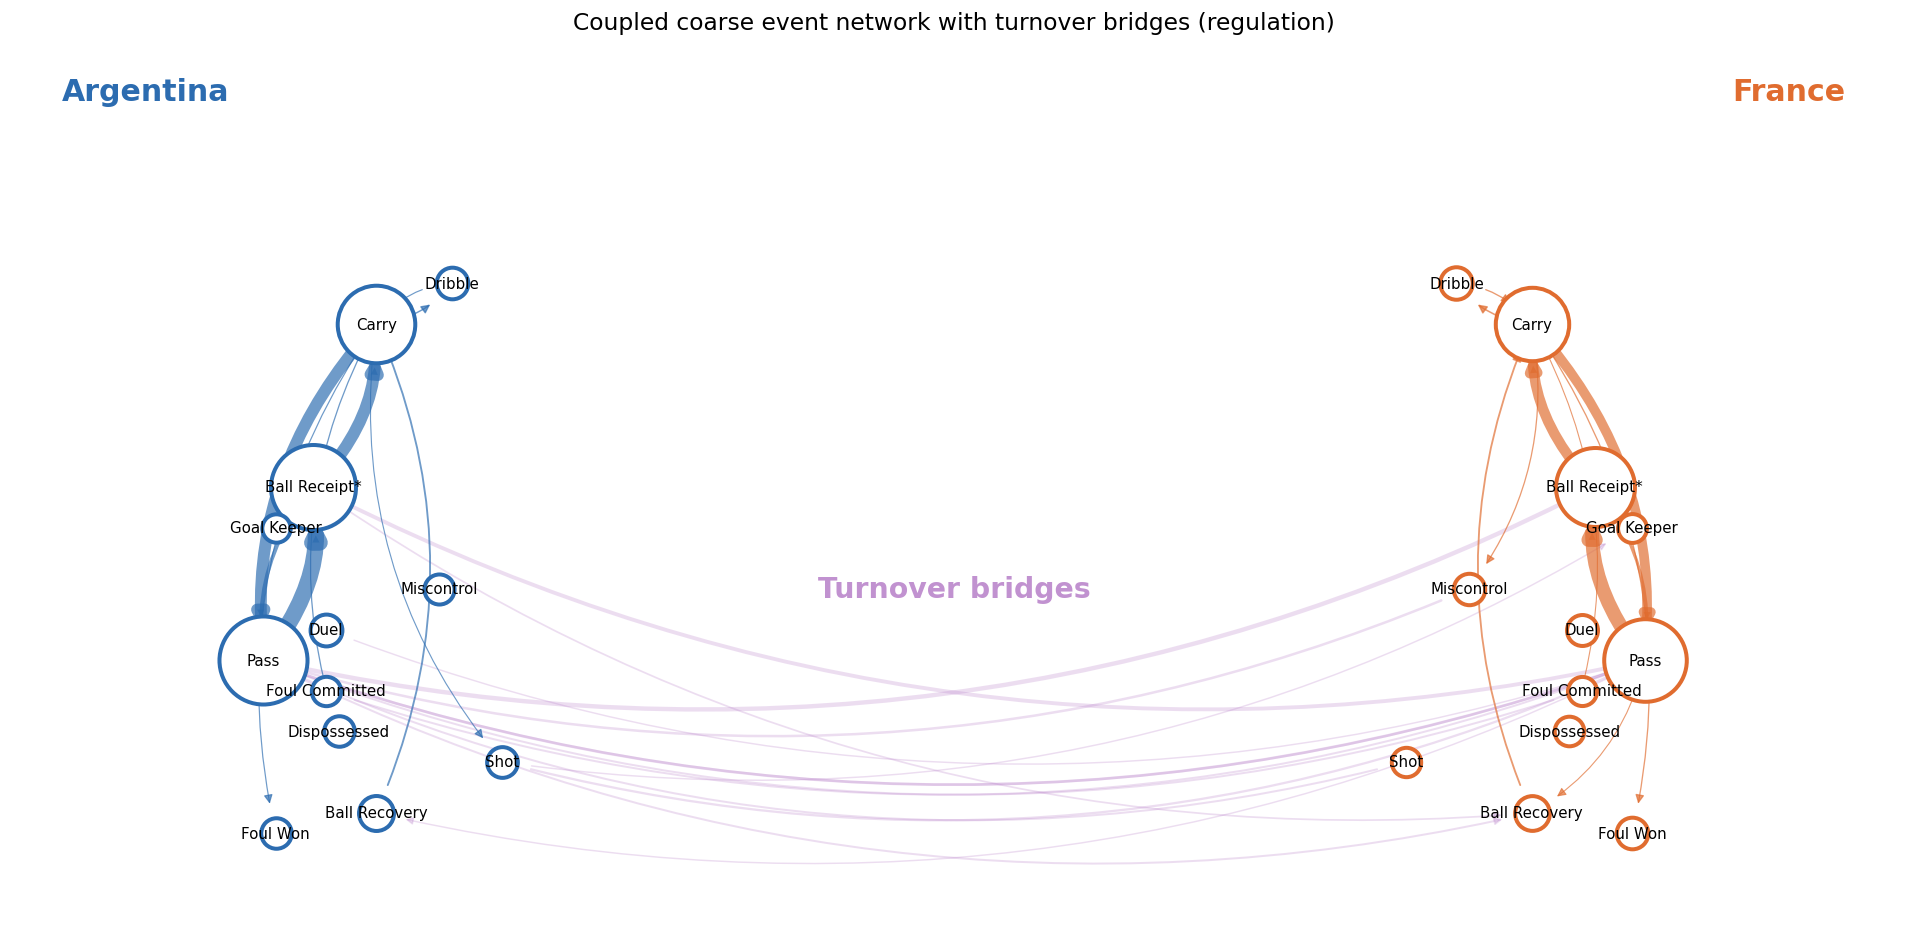

In [131]:
fig, ax = plt.subplots(figsize=(16, 8), dpi=120)

draw_coupled_event_network(
    ax,
    team_edges_reg,
    team_counts_reg,
    turnover_bridge_table,
    within_threshold=6,
    turnover_threshold=3,
    top_n=10,
    title="Coupled coarse event network with turnover bridges (regulation)",
)

plt.tight_layout()
plt.show()

This figure answers a different question from the earlier Argentina-only network.

Within each side, the colored edges show how that team's own possessions tend to flow. The lighter bridges between sides show how the last state of one team's possession connects to the first state of the next possession by the other team.

Because the edges are filtered, the figure is readable enough to support interpretation. We can see immediately that:

- the dominant within-team grammar still runs through `Pass`, `Ball Receipt*`, and `Carry`,
- many cross-team handovers land on `Pass`, which tells us that not every possession change begins with an explicit `Ball Recovery`,
- and some bridges arrive through regain states such as `Ball Recovery`, `Interception`, or `Goal Keeper`.

That last point is one reason turnovers are worth treating as a modeling object in their own right, not just as noise between possessions.

### Checkpoint

Before moving on, it is worth pausing on a central modeling lesson:

> The graph did not come from the event file automatically.

It appeared only after we made choices about:

- which rows count as states,
- which team's actions to keep,
- whether to break at possession boundaries,
- and whether the state space should stay coarse or be enriched.

We now keep the same match and the same baseline segmentation, but change the state vocabulary.


## Part II — Augmented State Spaces, Transition Matrices, Comparisons, and Extensions


## 9. Augmenting events with nested StatsBomb fields

A raw event type like `Pass` is often too coarse.

StatsBomb records many useful details inside nested fields. For passes, some of the most important are:

- `pass.type.name`,
- `pass.height.name`,
- `pass.outcome.name`,
- and `under_pressure`.

Those fields let us turn one broad state into more specific states such as:

- `Pass | Standard | Ground Pass | Complete`,
- `Pass | Throw-in | Low Pass | Complete`,
- `Pass | Standard | High Pass | Failed`,
- `Pass | Standard | High Pass | Failed | Under Pressure`.

That enrichment is powerful, but it is still a modeling choice. We are choosing which details matter enough to become part of the state label.


In [33]:
pass_example_indices = [8, 10, 56, 61]

pass_examples = (
    events_df.loc[events_df["index"].isin(pass_example_indices), [
        "index",
        "team_name",
        "player_name",
        "play_pattern_name",
        "event_type",
        "pass_type_name",
        "pass_height_name",
        "pass_outcome_name",
        "under_pressure",
    ]]
    .sort_values("index")
    .reset_index(drop=True)
)

pass_examples


,index,team_name,player_name,play_pattern_name,event_type,pass_type_name,pass_height_name,pass_outcome_name,under_pressure
0,8,France,Aurélien Djani Tchouaméni,From Kick Off,Pass,NaN,High Pass,Out,False
1,10,Argentina,Nahuel Molina Lucero,From Throw In,Pass,Throw-in,Low Pass,NaN,False
2,56,Argentina,Damián Emiliano Martínez,From Free Kick,Pass,NaN,High Pass,Incomplete,True
3,61,France,Theo Bernard François Hernández,Regular Play,Pass,NaN,Low Pass,NaN,False


The table above shows several important schema details in one place.

- When `pass_type_name` is missing, that usually means the pass is a standard pass in the run of play.
- When `pass_outcome_name` is missing, the pass was completed.
- `under_pressure` is a separate contextual flag, not a pass subtype.
- A throw-in can appear as a pass subtype.


In [34]:
pass_schema_summary = pd.DataFrame(
    [
        {
            "total_passes_in_match": int(events_df["event_type"].eq("Pass").sum()),
            "passes_with_missing_pass_type_name": int(events_df.loc[events_df["event_type"].eq("Pass"), "pass_type_name"].isna().sum()),
            "passes_with_missing_pass_outcome_name": int(events_df.loc[events_df["event_type"].eq("Pass"), "pass_outcome_name"].isna().sum()),
        }
    ]
)

pass_type_counts = (
    events_df.loc[events_df["event_type"].eq("Pass"), "pass_type_name"]
    .value_counts(dropna=False)
    .rename_axis("pass_type_name")
    .reset_index(name="count")
)

pass_outcome_counts = (
    events_df.loc[events_df["event_type"].eq("Pass"), "pass_outcome_name"]
    .value_counts(dropna=False)
    .rename_axis("pass_outcome_name")
    .reset_index(name="count")
)

display(pass_schema_summary)
display(pass_type_counts)
display(pass_outcome_counts)


,total_passes_in_match,passes_with_missing_pass_type_name,passes_with_missing_pass_outcome_name
0,1263,977,994


,pass_type_name,count
0,NaN,977
1,Recovery,133
2,Free Kick,51
3,Throw-in,48
4,Goal Kick,19
5,Interception,14
6,Corner,11
7,Kick Off,10


,pass_outcome_name,count
0,NaN,994
1,Incomplete,232
2,Out,20
3,Unknown,10
4,Pass Offside,7


In [35]:
manual_pass_labels = pass_examples.copy()

manual_pass_labels["pass_type_for_label"] = manual_pass_labels["pass_type_name"].fillna("Standard")
manual_pass_labels["pass_result_for_label"] = np.where(
    manual_pass_labels["pass_outcome_name"].isna(),
    "Complete",
    "Failed",
)
manual_pass_labels["pressure_tag"] = np.where(
    manual_pass_labels["under_pressure"],
    " | Under Pressure",
    "",
)

manual_pass_labels["manual_state_label"] = (
    "Pass | "
    + manual_pass_labels["pass_type_for_label"]
    + " | "
    + manual_pass_labels["pass_height_name"].fillna("Unknown Height")
    + " | "
    + manual_pass_labels["pass_result_for_label"]
    + manual_pass_labels["pressure_tag"]
)

manual_pass_labels[
    [
        "index",
        "player_name",
        "pass_type_name",
        "pass_height_name",
        "pass_outcome_name",
        "under_pressure",
        "manual_state_label",
    ]
]


,index,player_name,pass_type_name,pass_height_name,pass_outcome_name,under_pressure,manual_state_label
0,8,Aurélien Djani Tchouaméni,NaN,High Pass,Out,False,Pass | Standard | High Pass | Failed
1,10,Nahuel Molina Lucero,Throw-in,Low Pass,NaN,False,Pass | Throw-in | Low Pass | Complete
2,56,Damián Emiliano Martínez,NaN,High Pass,Incomplete,True,Pass | Standard | High Pass | Failed | Under Pressure
3,61,Theo Bernard François Hernández,NaN,Low Pass,NaN,False,Pass | Standard | Low Pass | Complete


In [36]:
shot_example = (
    events_df.loc[events_df["index"].eq(192), [
        "index",
        "team_name",
        "player_name",
        "event_type",
        "shot_type_name",
        "shot_outcome_name",
        "under_pressure",
        "play_pattern_name",
    ]]
    .copy()
)

shot_example["example_state_label"] = (
    "Shot | "
    + shot_example["shot_type_name"].fillna("Unknown Type")
    + " | "
    + shot_example["shot_outcome_name"].fillna("Unknown Outcome")
)

shot_example


,index,team_name,player_name,event_type,shot_type_name,shot_outcome_name,under_pressure,play_pattern_name,example_state_label
191,192,Argentina,Alexis Mac Allister,Shot,Open Play,Saved,False,Regular Play,Shot | Open Play | Saved


That is the enrichment logic in the open.

We started with raw nested fields, made explicit choices about how to interpret missing values, and then built a more detailed state label. Only after students have seen that move manually does it make sense to wrap it in a helper function.

For shots, the notebook will use a lighter augmentation: shot type and shot outcome. We could add more. But again, every extra detail grows the state space.

The goal is not to make the richest possible label. The goal is to make a state space rich enough to ask better soccer questions without making the network so sparse that interpretation collapses.


### Helper functions for reusable network construction

Now that the logic has been shown manually, we can package it into a few small helper functions for the later comparisons.

The point is pedagogical. We did **not** put these functions at the top of the notebook, because the central transformations are important enough to build live and inspect together first.

In [37]:
def extract_sequences_from_df(df, group_col="possession", state_col="state"):
    """Extract ordered state sequences from a DataFrame grouped by a sequence identifier."""
    sequences = []

    for _, group in df.sort_values("index").groupby(group_col, sort=False):
        seq = group.sort_values("index")[state_col].dropna().tolist()
        if seq:
            sequences.append(seq)

    return sequences


def edge_table_from_sequences(sequences):
    """Turn a list of sequences into a weighted edge table of consecutive state pairs."""
    pairs = []

    for seq in sequences:
        if len(seq) >= 2:
            pairs.extend(zip(seq[:-1], seq[1:]))

    if not pairs:
        return pd.DataFrame(columns=["source", "target", "weight"])

    edge_table = (
        pd.DataFrame(pairs, columns=["source", "target"])
        .value_counts()
        .rename("weight")
        .reset_index()
        .sort_values(["weight", "source", "target"], ascending=[False, True, True])
        .reset_index(drop=True)
    )
    return edge_table


def adjacency_from_edge_table(edge_table):
    """Create a square adjacency matrix of counts from a weighted edge table."""
    if edge_table.empty:
        return pd.DataFrame()

    states = sorted(pd.unique(pd.concat([edge_table["source"], edge_table["target"]], ignore_index=True)))
    A = pd.DataFrame(0, index=states, columns=states, dtype=int)

    for row in edge_table.itertuples(index=False):
        A.loc[row.source, row.target] = int(row.weight)

    return A


def transition_matrix_from_adjacency(A):
    """Row-normalize an adjacency matrix into a transition matrix."""
    if A.empty:
        return A.copy(), pd.Series(dtype=float)

    row_sums = A.sum(axis=1)
    P = A.div(row_sums.replace(0, np.nan), axis=0).fillna(0.0)

    nonzero_rows = row_sums > 0
    if nonzero_rows.any():
        assert np.allclose(P.loc[nonzero_rows].sum(axis=1).to_numpy(), 1.0)

    return P, row_sums


def state_contracted(row):
    """Return a deliberately collapsed state label for a compact event vocabulary."""
    et = row["event_type"]

    if et in {"Ball Recovery", "Interception", "Goal Keeper", "50/50"}:
        return "Regain"

    if et == "Ball Receipt*":
        return "Receive"

    if et in {"Carry", "Dribble"}:
        return "Move"

    if et in {"Miscontrol", "Dispossessed"}:
        return "Loss"

    if et in {"Foul Won", "Foul Committed"}:
        return "Foul"

    if et in {"Duel", "Block", "Clearance"}:
        return "Contest"

    if et == "Pass":
        return "Pass"

    if et == "Shot":
        return "Shot"

    if et == "Offside":
        return "Offside"

    return et


def state_coarse(row):
    """Return the coarse state label for an event row."""
    return row["event_type"]


def state_outcome_aware(row):
    """Return a lightly enriched state label with success or outcome information when available."""
    et = row["event_type"]

    if et == "Pass":
        return f"Pass | {'Complete' if pd.isna(row['pass_outcome_name']) else 'Failed'}"

    if et == "Ball Receipt*":
        return f"Ball Receipt* | {'Complete' if pd.isna(row['ball_receipt_outcome_name']) else 'Incomplete'}"

    if et == "Shot":
        outcome = row["shot_outcome_name"] if pd.notna(row["shot_outcome_name"]) else "Unknown Outcome"
        return f"Shot | {outcome}"

    if et == "Dribble":
        outcome = row["dribble_outcome_name"] if pd.notna(row["dribble_outcome_name"]) else "Unknown"
        return f"Dribble | {outcome}"

    return et


def state_enriched(row):
    """Return a richer event-state label using selected nested StatsBomb fields."""
    et = row["event_type"]

    if et == "Pass":
        pass_type = row["pass_type_name"] if pd.notna(row["pass_type_name"]) else "Standard"
        pass_height = row["pass_height_name"] if pd.notna(row["pass_height_name"]) else "Unknown Height"
        result = "Complete" if pd.isna(row["pass_outcome_name"]) else "Failed"
        label = f"Pass | {pass_type} | {pass_height} | {result}"
        if row["under_pressure"]:
            label += " | Under Pressure"
        return label

    if et == "Ball Receipt*":
        result = "Complete" if pd.isna(row["ball_receipt_outcome_name"]) else "Incomplete"
        label = f"Ball Receipt* | {result}"
        if row["under_pressure"]:
            label += " | Under Pressure"
        return label

    if et == "Shot":
        shot_type = row["shot_type_name"] if pd.notna(row["shot_type_name"]) else "Unknown Type"
        shot_outcome = row["shot_outcome_name"] if pd.notna(row["shot_outcome_name"]) else "Unknown Outcome"
        return f"Shot | {shot_type} | {shot_outcome}"

    if et == "Dribble":
        outcome = row["dribble_outcome_name"] if pd.notna(row["dribble_outcome_name"]) else "Unknown"
        label = f"Dribble | {outcome}"
        if row["under_pressure"]:
            label += " | Under Pressure"
        return label

    return et


def state_enriched_plus_pattern(row):
    """Return an even richer label that also appends play-pattern context for selected actions."""
    label = state_enriched(row)

    if row["event_type"] in {"Pass", "Ball Receipt*", "Ball Recovery", "Carry", "Dribble", "Shot"}:
        pattern = row["play_pattern_name"] if pd.notna(row["play_pattern_name"]) else "Unknown Pattern"
        label = f"{label} | {pattern}"

    return label


## 10. Coarse versus enriched state spaces

We will now hold the segmentation rule fixed and compare several state designs on the same Argentina first-half possession sequences:

1. **contracted:** deliberately merge related event families into a smaller vocabulary,
2. **coarse:** just the raw event type,
3. **outcome aware:** coarse types with a few success or failure distinctions,
4. **enriched:** pass-aware and pressure-aware labels,
5. **enriched plus play pattern:** even more contextual detail.

The question is not which design is universally best. The question is what each design lets us see, and what it costs in sparsity and readability.

In [38]:
baseline_designs = {
    "Contracted": state_contracted,
    "Coarse": state_coarse,
    "Outcome aware": state_outcome_aware,
    "Enriched": state_enriched,
    "Enriched + play pattern": state_enriched_plus_pattern,
}

network_objects = {}

for design_name, state_func in baseline_designs.items():
    temp = baseline_df.copy()
    temp["state"] = temp.apply(state_func, axis=1)

    sequences = extract_sequences_from_df(temp, group_col="possession", state_col="state")
    edge_table = edge_table_from_sequences(sequences)
    A_design = adjacency_from_edge_table(edge_table)
    P_design, row_sums = transition_matrix_from_adjacency(A_design)

    network_objects[design_name] = {
        "df": temp,
        "sequences": sequences,
        "edge_table": edge_table,
        "A": A_design,
        "P": P_design,
        "row_sums": row_sums,
    }

comparison_rows = []

for design_name, obj in network_objects.items():
    A_design = obj["A"]
    edge_count = int((A_design.to_numpy() > 0).sum())
    n_states = A_design.shape[0]

    comparison_rows.append(
        {
            "design": design_name,
            "states": n_states,
            "edges": edge_count,
            "density": edge_count / (n_states ** 2) if n_states > 0 else np.nan,
            "total_transitions": int(A_design.to_numpy().sum()),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).sort_values("states")
comparison_df


,design,states,edges,density,total_transitions
0,Contracted,9,31,0.382716,842
1,Coarse,16,46,0.179688,842
2,Outcome aware,23,56,0.105860,842
3,Enriched,49,99,0.041233,842
4,Enriched + play pattern,93,168,0.019424,842


The number of recorded transitions stays the same because the underlying sequences are the same. What changes is the vocabulary.

Contracting the state space merges distinctions. Enriching the state space splits them apart.

As the labels become richer, the number of states rises sharply, the number of occupied edges rises, and the network becomes sparser and harder to visualize as a single drawing. That is the state-space version of increasing the resolution of a pitch grid.

Moving in the other direction is just as important. A contracted vocabulary can make the overall grammar easier to see, but only by suppressing distinctions that may matter tactically.

In [39]:
enriched_state_counts = (
    network_objects["Enriched"]["df"]["state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="count")
)

enriched_state_counts.head(20)


,state,count
0,Ball Receipt* | Complete,249
1,Carry,229
2,Pass | Standard | Ground Pass | Complete,187
3,Ball Receipt* | Incomplete,27
4,Pass | Standard | High Pass | Complete,16
5,Ball Recovery,14
6,Pass | Standard | High Pass | Failed,11
7,Ball Receipt* | Complete | Under Pressure,10
8,Pass | Standard | Ground Pass | Failed,10
9,Pass | Recovery | Ground Pass | Complete,9


In [40]:
for design_name in ["Contracted", "Coarse", "Outcome aware", "Enriched"]:
    print(design_name)
    display(network_objects[design_name]["edge_table"].head(12))
    print("-" * 90)


Contracted


,source,target,weight
0,Pass,Receive,286
1,Receive,Move,206
2,Move,Pass,203
3,Receive,Pass,52
4,Move,Move,19
5,Regain,Move,14
6,Move,Loss,7
7,Move,Foul,6
8,Receive,Regain,5
9,Loss,Pass,4


------------------------------------------------------------------------------------------
Coarse


,source,target,weight
0,Pass,Ball Receipt*,286
1,Ball Receipt*,Carry,206
2,Carry,Pass,202
3,Ball Receipt*,Pass,52
4,Ball Recovery,Carry,13
5,Carry,Dribble,12
6,Dribble,Carry,7
7,Carry,Foul Won,6
8,Ball Receipt*,Ball Recovery,4
9,Carry,Dispossessed,4


------------------------------------------------------------------------------------------
Outcome aware


,source,target,weight
0,Pass | Complete,Ball Receipt* | Complete,259
1,Ball Receipt* | Complete,Carry,206
2,Carry,Pass | Complete,179
3,Ball Receipt* | Complete,Pass | Complete,40
4,Pass | Failed,Ball Receipt* | Incomplete,27
5,Carry,Pass | Failed,23
6,Ball Recovery,Carry,13
7,Ball Receipt* | Complete,Pass | Failed,7
8,Carry,Dribble | Complete,7
9,Dribble | Complete,Carry,7


------------------------------------------------------------------------------------------
Enriched


,source,target,weight
0,Ball Receipt* | Complete,Carry,199
1,Pass | Standard | Ground Pass | Complete,Ball Receipt* | Complete,179
2,Carry,Pass | Standard | Ground Pass | Complete,156
3,Ball Receipt* | Complete,Pass | Standard | Ground Pass | Complete,30
4,Pass | Standard | High Pass | Complete,Ball Receipt* | Complete,16
5,Ball Recovery,Carry,13
6,Carry,Pass | Standard | High Pass | Complete,11
7,Carry,Pass | Standard | High Pass | Failed,10
8,Pass | Recovery | Ground Pass | Complete,Ball Receipt* | Complete,9
9,Pass | Standard | High Pass | Failed,Ball Receipt* | Incomplete,9


------------------------------------------------------------------------------------------


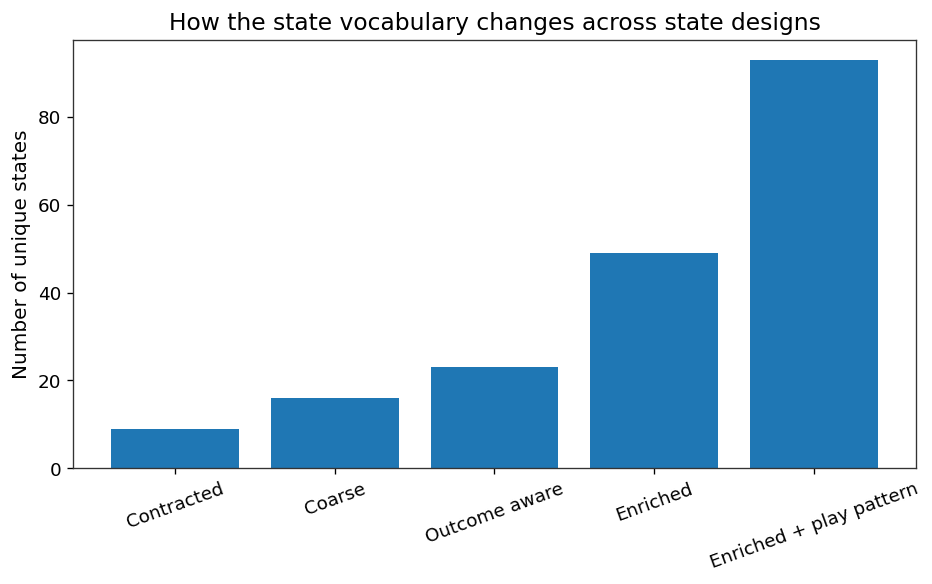

In [41]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

ax.bar(comparison_df["design"], comparison_df["states"])
ax.set_title("How the state vocabulary changes across state designs")
ax.set_ylabel("Number of unique states")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


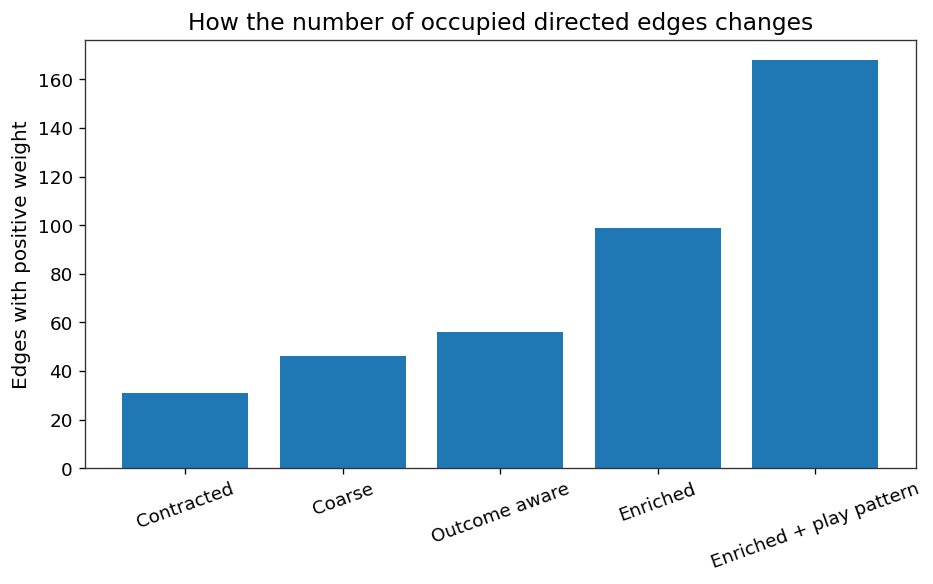

In [42]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

ax.bar(comparison_df["design"], comparison_df["edges"])
ax.set_title("How the number of occupied directed edges changes")
ax.set_ylabel("Edges with positive weight")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### The same coupled picture under a contracted vocabulary

Contracting the vocabulary changes more than a table of counts. It changes what a graph drawing can and cannot say at a glance.

Below, the left panel keeps coarse states in the coupled regulation view. The right panel collapses several related event families into broader labels such as `Receive`, `Move`, `Regain`, and `Loss`.

The contracted panel is easier to read as one single diagram. The coarse panel preserves more soccer detail. Neither is neutral.

In [43]:
regulation_onball_contracted = regulation_onball_df.copy()
regulation_onball_contracted["state"] = regulation_onball_contracted.apply(state_contracted, axis=1)

team_counts_reg_contracted = {}
team_edges_reg_contracted = {}

for team_name in [MAIN_TEAM, OTHER_TEAM]:
    team_slice = regulation_onball_contracted.loc[regulation_onball_contracted["team_name"].eq(team_name)].copy()
    team_counts_reg_contracted[team_name] = team_slice["state"].value_counts()

    team_sequences = []
    for possession_id, group in team_slice.groupby("possession", sort=False):
        seq = group.sort_values("index")["state"].tolist()
        if seq:
            team_sequences.append(seq)

    team_edges_reg_contracted[team_name] = edge_table_from_sequences(team_sequences)

regulation_possessions_contracted_rows = []

for possession_id, group in regulation_onball_contracted.groupby("possession", sort=False):
    group = group.sort_values("index")
    regulation_possessions_contracted_rows.append(
        {
            "possession": int(possession_id),
            "team": group["possession_team_name"].iloc[0],
            "start_index": int(group["index"].min()),
            "first_state": group["state"].iloc[0],
            "last_state": group["state"].iloc[-1],
        }
    )

regulation_possessions_contracted = (
    pd.DataFrame(regulation_possessions_contracted_rows)
    .sort_values("start_index")
    .reset_index(drop=True)
)

turnover_bridge_rows_contracted = []

for i in range(len(regulation_possessions_contracted) - 1):
    previous_possession = regulation_possessions_contracted.iloc[i]
    next_possession = regulation_possessions_contracted.iloc[i + 1]

    if previous_possession["team"] == next_possession["team"]:
        continue

    turnover_bridge_rows_contracted.append(
        {
            "source_team": previous_possession["team"],
            "source_state": previous_possession["last_state"],
            "target_team": next_possession["team"],
            "target_state": next_possession["first_state"],
        }
    )

turnover_bridge_table_contracted = (
    pd.DataFrame(turnover_bridge_rows_contracted)
    .value_counts()
    .rename("weight")
    .reset_index()
    .sort_values(
        ["weight", "source_team", "source_state", "target_team", "target_state"],
        ascending=[False, True, True, True, True],
    )
    .reset_index(drop=True)
)

coupled_view_comparison = pd.DataFrame(
    [
        {
            "view": "Coarse coupled regulation view",
            "Argentina states": int(team_counts_reg[MAIN_TEAM].shape[0]),
            "France states": int(team_counts_reg[OTHER_TEAM].shape[0]),
            "distinct turnover bridge types": int(turnover_bridge_table.shape[0]),
        },
        {
            "view": "Contracted coupled regulation view",
            "Argentina states": int(team_counts_reg_contracted[MAIN_TEAM].shape[0]),
            "France states": int(team_counts_reg_contracted[OTHER_TEAM].shape[0]),
            "distinct turnover bridge types": int(turnover_bridge_table_contracted.shape[0]),
        },
    ]
)

coupled_view_comparison

,view,Argentina states,France states,distinct turnover bridge types
0,Coarse coupled regulation view,17,15,31
1,Contracted coupled regulation view,9,8,25


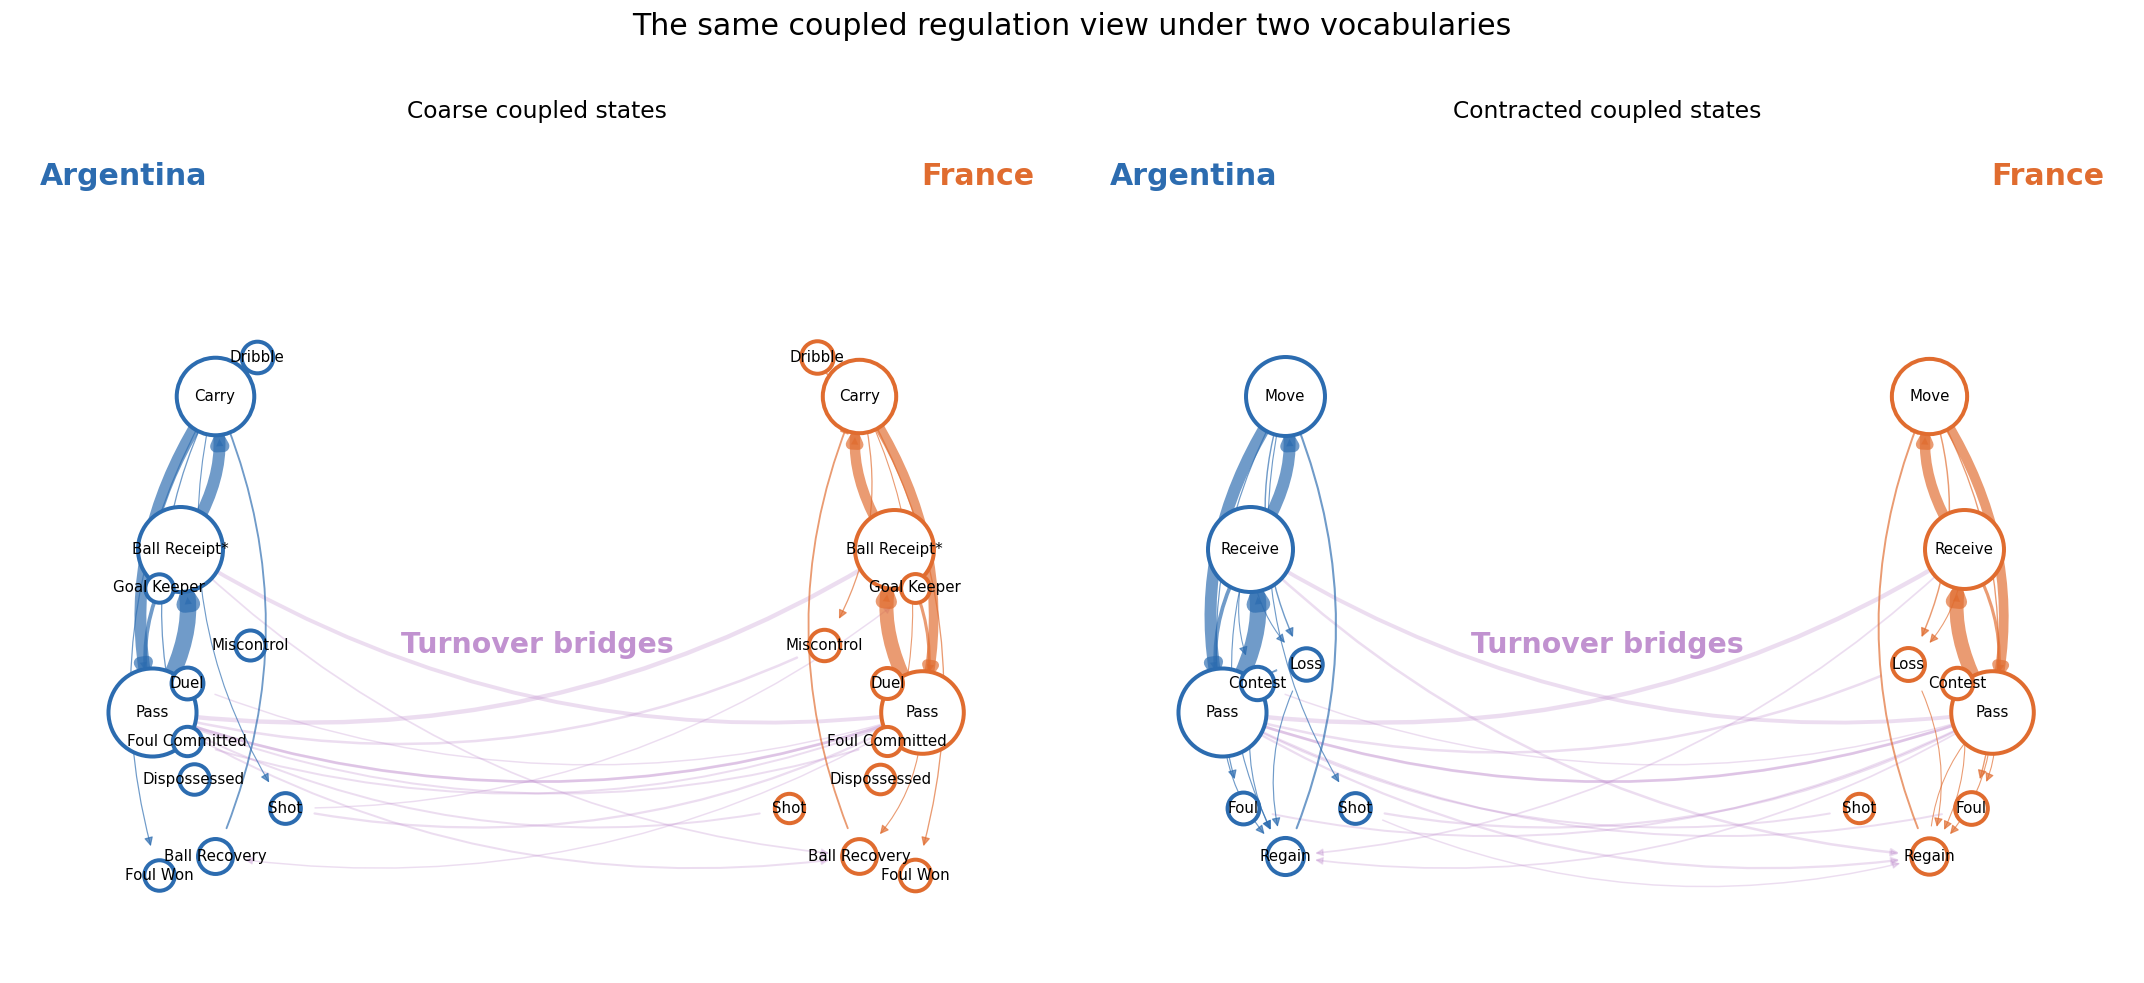

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), dpi=120)

draw_coupled_event_network(
    axes[0],
    team_edges_reg,
    team_counts_reg,
    turnover_bridge_table,
    within_threshold=6,
    turnover_threshold=3,
    top_n=10,
    title="Coarse coupled states",
)

draw_coupled_event_network(
    axes[1],
    team_edges_reg_contracted,
    team_counts_reg_contracted,
    turnover_bridge_table_contracted,
    within_threshold=4,
    turnover_threshold=3,
    top_n=8,
    title="Contracted coupled states",
)

fig.suptitle("The same coupled regulation view under two vocabularies", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

The comparison makes the modeling tradeoff visual.

The contracted view clarifies the broad grammar: possessions circulate through `Pass`, `Receive`, and `Move`, with bridges often landing on `Pass` or `Regain`.

The coarse view is busier, but it preserves distinctions that the contracted view suppresses: `Ball Recovery` versus `Interception`, `Miscontrol` versus `Dispossessed`, `Foul Won` versus `Foul Committed`, and so on.

That is exactly what "expanding" and "contracting" mean here. They are not cosmetic choices. They change the state space.

The contracted network is the easiest to read as one broad grammar.

The coarse network is still compact enough to teach from directly.

The enriched network is more expressive. It distinguishes standard passes from throw-ins, separates completed and failed passes, and can flag pressure-aware actions. But it also fragments the counts. One big `Pass` node becomes many pass states.

That fragmentation is not a problem by itself. It is the price of asking more detailed questions.

## 11. Transition matrices and a Markov-style interpretation

Once we have a count matrix $A$, we can row-normalize it to obtain a transition matrix $P$.

The entry $P_{ij}$ is

$$
P_{ij} = \Pr(X_{t+1} = j \mid X_t = i),
$$

where:

- $X_t$ is the state at step $t$ in the sequence,
- $i$ indexes the current state,
- and $j$ indexes the next state.

So each row of $P$ is a conditional distribution over the next state.

This is a first-order model. It assumes that the distribution of the next state depends only on the current state, not on the full earlier history of the possession.


In [45]:
selected_rows = ["Ball Recovery", "Pass", "Ball Receipt*", "Carry"]

coarse_transition.loc[selected_rows].round(3)


,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Dispossessed,Dribble,Duel,Foul Committed,Foul Won,Goal Keeper,Interception,Miscontrol,Offside,Pass,Shot
Ball Recovery,0.000,0.000,0.000,0.000,0.929,0.000,0.000,0.000,0.000,0.000,0.0,0.000,0.000,0.0,0.000,0.071
Pass,0.003,0.979,0.007,0.003,0.000,0.000,0.000,0.003,0.000,0.000,0.0,0.000,0.000,0.0,0.003,0.000
Ball Receipt*,0.000,0.000,0.015,0.004,0.752,0.000,0.000,0.007,0.004,0.007,0.0,0.004,0.011,0.0,0.190,0.007
Carry,0.000,0.000,0.000,0.000,0.000,0.017,0.052,0.000,0.000,0.026,0.0,0.000,0.013,0.0,0.882,0.009


This table can be read row by row.

For example, the row for `Carry` says: conditional on the current state being `Carry`, how often did the next recorded state become `Pass`, `Dribble`, `Shot`, `Dispossessed`, and so on in this modeled sequence space?

That is why row normalization is natural here. We are studying continuation patterns.


In [46]:
pass_row = coarse_transition.loc["Pass"]
pass_row = pass_row[pass_row > 0].sort_values(ascending=False)

ball_receipt_row = coarse_transition.loc["Ball Receipt*"]
ball_receipt_row = ball_receipt_row[ball_receipt_row > 0].sort_values(ascending=False)

carry_row = coarse_transition.loc["Carry"]
carry_row = carry_row[carry_row > 0].sort_values(ascending=False)

display(pass_row.rename("Pass row").to_frame())
display(ball_receipt_row.rename("Ball Receipt* row").to_frame())
display(carry_row.rename("Carry row").to_frame())


,Pass row
Ball Receipt*,0.979452
Ball Recovery,0.006849
50/50,0.003425
Block,0.003425
Duel,0.003425
Pass,0.003425


,Ball Receipt* row
Carry,0.751825
Pass,0.189781
Ball Recovery,0.014599
Miscontrol,0.010949
Shot,0.007299
Duel,0.007299
Foul Won,0.007299
Block,0.003650
Foul Committed,0.003650
Interception,0.003650


,Carry row
Pass,0.882096
Dribble,0.052402
Foul Won,0.026201
Dispossessed,0.017467
Miscontrol,0.013100
Shot,0.008734


A first-order transition matrix is useful, but it is not the whole tactical story.

It does not know:

- where on the pitch the action happened,
- which players were involved,
- how the possession started several steps earlier,
- or whether the same current state has different meanings in different parts of the match.

So we should treat the matrix as a compact approximation of local action flow, not as a complete model of soccer tactics.


### A short higher-order caution

A first-order row for `Carry` treats every `Carry` state as if it means the same thing.

But a `Carry` that comes right after `Ball Recovery` does not have to branch in the same way as a `Carry` that comes after `Ball Receipt*`. A quick conditional check makes that visible.

In [47]:
carry_context_rows = []

for seq in baseline_sequences:
    for previous_state, current_state, next_state in zip(seq[:-2], seq[1:-1], seq[2:]):
        if current_state == "Carry" and previous_state in {"Ball Receipt*", "Ball Recovery", "Dribble"}:
            carry_context_rows.append(
                {
                    "previous_state": previous_state,
                    "current_state": current_state,
                    "next_state": next_state,
                }
            )

carry_context_df = pd.DataFrame(carry_context_rows)

carry_context_counts = (
    carry_context_df["previous_state"]
    .value_counts()
    .rename_axis("previous_state")
    .reset_index(name="observations")
)

carry_context_transition = (
    pd.crosstab(carry_context_df["previous_state"], carry_context_df["next_state"], normalize="index")
    .round(3)
)

display(carry_context_counts)
display(carry_context_transition)

,previous_state,observations
0,Ball Receipt*,206
1,Ball Recovery,13
2,Dribble,7


next_state,Dispossessed,Dribble,Foul Won,Miscontrol,Pass,Shot
previous_state,,,,,,
Ball Receipt*,0.019,0.058,0.024,0.015,0.874,0.01
Ball Recovery,0.000,0.000,0.000,0.000,1.000,0.00
Dribble,0.000,0.000,0.143,0.000,0.857,0.00


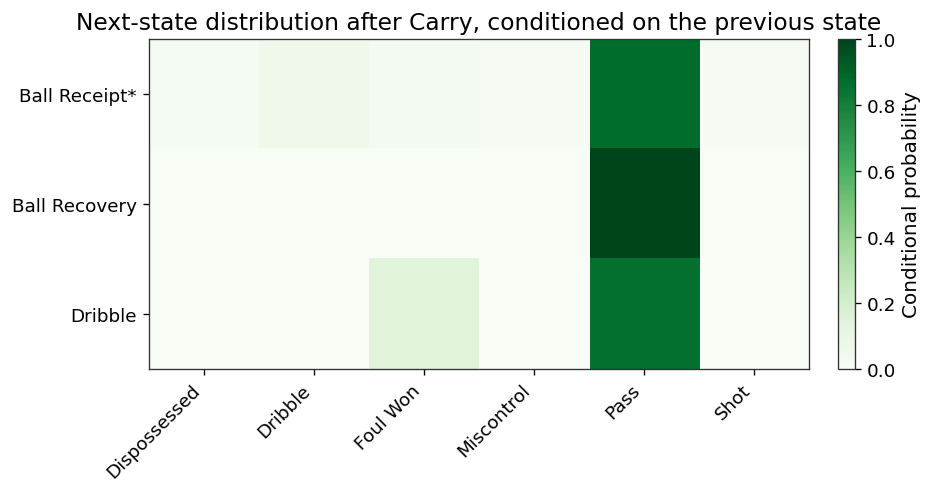

In [48]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=120)

im = ax.imshow(carry_context_transition.fillna(0.0), cmap="Greens", vmin=0, vmax=1)

ax.set_xticks(range(carry_context_transition.shape[1]))
ax.set_xticklabels(carry_context_transition.columns, rotation=45, ha="right")
ax.set_yticks(range(carry_context_transition.shape[0]))
ax.set_yticklabels(carry_context_transition.index)
ax.set_title("Next-state distribution after Carry, conditioned on the previous state")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Conditional probability")

plt.tight_layout()
plt.show()

The pattern is simple but important.

When `Carry` follows `Ball Recovery`, the next state is overwhelmingly `Pass` in this slice. When `Carry` follows `Ball Receipt*`, the branching is a little wider: `Dribble`, `Foul Won`, `Dispossessed`, `Miscontrol`, and `Shot` all appear.

So a first-order transition matrix is useful, but it is also averaging away some sequence history.

### A tiny numeric entropy example

Suppose one state transitions to three next states with probabilities $0.5$, $0.25$, and $0.25$.

Its outgoing entropy is

$$
H(i) = - \sum_j P_{ij} \log_2 P_{ij},
$$

which here becomes

$$
-(0.5 \log_2 0.5 + 0.25 \log_2 0.25 + 0.25 \log_2 0.25) = 1.5.
$$

Higher entropy means the state branches more evenly across several next states. Lower entropy means the continuation is more concentrated.


## 12. What should we measure on an event-transition network?

We do not need a long menu of generic network metrics.

For this kind of network, a compact and useful core set is:

- **out-strength**
  $$
  s_i^{out} = \sum_j A_{ij},
  $$
  where $A_{ij}$ is the transition count from state $i$ to state $j$.

- **in-strength**
  $$
  s_i^{in} = \sum_j A_{ji}.
  $$

- **out-degree**
  $$
  k_i^{out} = \sum_j \mathbf{1}\{A_{ij} > 0\},
  $$
  where $\mathbf{1}\{\cdot\}$ is the indicator function.

- **in-degree**
  $$
  k_i^{in} = \sum_j \mathbf{1}\{A_{ji} > 0\}.
  $$

- **self-loop rate**
  $$
  P_{ii},
  $$
  which is the probability of remaining in the same state for one more step.

- **outgoing entropy**
  $$
  H(i) = - \sum_j P_{ij} \log_2 P_{ij}.
  $$

- **HHI concentration**
  $$
  \mathrm{HHI}(i) = \sum_j P_{ij}^2.
  $$

Here $P_{ij}$ is the row-normalized transition probability from current state $i$ to next state $j$.

These measures connect directly to the transition-matrix interpretation.


In [49]:
def metric_table_from_adjacency(A):
    """Compute compact event-transition metrics from a count adjacency matrix."""
    out_strength = A.sum(axis=1)
    in_strength = A.sum(axis=0)
    out_degree = (A > 0).sum(axis=1)
    in_degree = (A > 0).sum(axis=0)

    P, _ = transition_matrix_from_adjacency(A)

    entropy = []
    hhi = []
    self_loop_rate = []

    for state in A.index:
        probs = P.loc[state]
        probs = probs[probs > 0]

        if len(probs) == 0:
            entropy.append(np.nan)
            hhi.append(np.nan)
            self_loop_rate.append(np.nan)
        else:
            entropy.append(float(-(probs * np.log2(probs)).sum()))
            hhi.append(float((probs ** 2).sum()))
            self_loop_rate.append(float(P.loc[state, state]) if state in P.columns else 0.0)

    metrics = pd.DataFrame(
        {
            "state": A.index,
            "out_strength": out_strength.values,
            "in_strength": in_strength.values,
            "out_degree": out_degree.values,
            "in_degree": in_degree.values,
            "self_loop_rate": self_loop_rate,
            "out_entropy_bits": entropy,
            "HHI": hhi,
        }
    ).set_index("state")

    return metrics.sort_values(["out_strength", "in_strength"], ascending=False)


coarse_metrics = metric_table_from_adjacency(coarse_adjacency)
coarse_metrics


,out_strength,in_strength,out_degree,in_degree,self_loop_rate,out_entropy_bits,HHI
state,,,,,,,
Pass,292,264,6,10,0.003425,0.190772,0.959420
Ball Receipt*,274,286,10,1,0.000000,1.168846,0.601790
Carry,229,229,6,5,0.000000,0.763907,0.782079
Ball Recovery,14,11,2,5,0.000000,0.371232,0.867347
Dribble,9,12,3,1,0.000000,0.986427,0.629630
Duel,6,5,4,4,0.000000,1.918296,0.277778
Miscontrol,5,6,4,2,0.000000,1.921928,0.280000
Block,4,5,4,5,0.000000,2.000000,0.250000
Dispossessed,4,4,2,1,0.000000,0.811278,0.625000


In [50]:
ball_receipt_probs = coarse_transition.loc["Ball Receipt*"]
ball_receipt_probs = ball_receipt_probs[ball_receipt_probs > 0]

ball_receipt_entropy = float(-(ball_receipt_probs * np.log2(ball_receipt_probs)).sum())
ball_receipt_hhi = float((ball_receipt_probs ** 2).sum())

display(
    pd.DataFrame(
        {
            "next_state": ball_receipt_probs.index,
            "probability": ball_receipt_probs.values,
        }
    )
)

pd.DataFrame(
    [
        {
            "state": "Ball Receipt*",
            "entropy_bits": ball_receipt_entropy,
            "HHI": ball_receipt_hhi,
        }
    ]
)


,next_state,probability
0,Ball Recovery,0.014599
1,Block,0.003650
2,Carry,0.751825
3,Duel,0.007299
4,Foul Committed,0.003650
5,Foul Won,0.007299
6,Interception,0.003650
7,Miscontrol,0.010949
8,Pass,0.189781
9,Shot,0.007299


,state,entropy_bits,HHI
0,Ball Receipt*,1.168846,0.60179


This micro-calculation shows how the math maps to the code:

- the probabilities come from one row of the transition matrix,
- entropy summarizes how spread out that row is,
- and HHI summarizes how concentrated it is.

A state can have high volume and still be highly predictable. A state can also be rare but branch in many directions.


In [51]:
coarse_metrics.sort_values("out_entropy_bits", ascending=False)


,out_strength,in_strength,out_degree,in_degree,self_loop_rate,out_entropy_bits,HHI
state,,,,,,,
Block,4,5,4,5,0.000000,2.000000,0.250000
Miscontrol,5,6,4,2,0.000000,1.921928,0.280000
Duel,6,5,4,4,0.000000,1.918296,0.277778
Ball Receipt*,274,286,10,1,0.000000,1.168846,0.601790
Interception,2,1,2,1,0.000000,1.000000,0.500000
50/50,2,2,2,2,0.500000,1.000000,0.500000
Dribble,9,12,3,1,0.000000,0.986427,0.629630
Dispossessed,4,4,2,1,0.000000,0.811278,0.625000
Carry,229,229,6,5,0.000000,0.763907,0.782079


A few interpretations are especially useful in event terms.

- A large **out-strength** means the state appears often as a source of transitions.
- A large **in-strength** means many transitions flow into that state.
- Large **out-degree** means many distinct next states are observed.
- High **entropy** means the state branches in a diverse way.
- High **HHI** means the next-step distribution is concentrated.
- A high **self-loop rate** means the state often repeats itself, such as `Pass → Pass` under certain modeling choices.

These are more informative here than dropping in a long list of centrality measures with little tactical interpretation.


### Comparing branching across state designs

Counts and edge totals tell us how the vocabulary grows. We can also ask how the branching behavior changes when we contract or enrich the state space.

One compact summary is a volume-weighted average of outgoing entropy and HHI across states.

In [52]:
design_metric_rows = []

for design_name, obj in network_objects.items():
    metrics = metric_table_from_adjacency(obj["A"])
    out_strength = metrics["out_strength"].fillna(0)

    positive_states = out_strength > 0

    if positive_states.any():
        weighted_entropy = np.average(
            metrics.loc[positive_states, "out_entropy_bits"].fillna(0),
            weights=out_strength.loc[positive_states],
        )
        weighted_hhi = np.average(
            metrics.loc[positive_states, "HHI"].fillna(0),
            weights=out_strength.loc[positive_states],
        )
    else:
        weighted_entropy = np.nan
        weighted_hhi = np.nan

    design_metric_rows.append(
        {
            "design": design_name,
            "states": obj["A"].shape[0],
            "weighted_mean_out_entropy_bits": weighted_entropy,
            "weighted_mean_HHI": weighted_hhi,
            "max_out_degree": int(metrics["out_degree"].max()) if not metrics.empty else 0,
        }
    )

design_metric_df = pd.DataFrame(design_metric_rows).sort_values("states")
design_metric_df.round(3)

,design,states,weighted_mean_out_entropy_bits,weighted_mean_HHI,max_out_degree
0,Contracted,9,0.750,0.755,7
1,Coarse,16,0.714,0.774,10
2,Outcome aware,23,0.797,0.743,9
3,Enriched,49,1.111,0.684,16
4,Enriched + play pattern,93,0.974,0.704,15


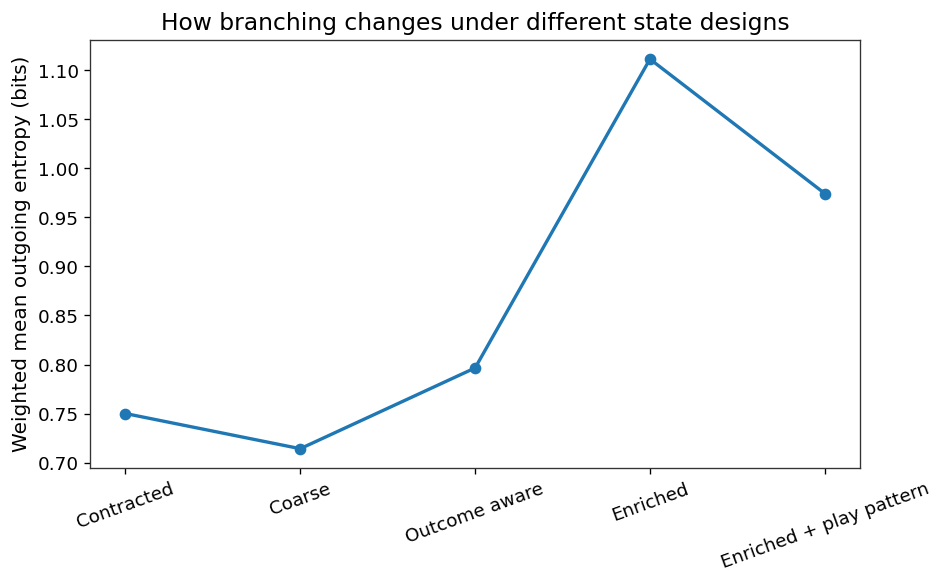

In [53]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

ax.plot(
    design_metric_df["design"],
    design_metric_df["weighted_mean_out_entropy_bits"],
    marker="o",
    linewidth=2,
)
ax.set_ylabel("Weighted mean outgoing entropy (bits)")
ax.set_title("How branching changes under different state designs")
ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

The contracted design compresses branching into fewer broad options. The enriched design spreads probability mass across more detailed next states, so the average outgoing entropy rises and HHI tends to fall.

That does not mean the enriched design is automatically better. It means the richer vocabulary is asking a finer-grained question.

## 14. Interpreting a real event-transition network in soccer terms

We now return to the Argentina first-half baseline network and ask what it says about the flow of possessions in this model.


In [54]:
top_transition_table = manual_edge_table.head(15).copy()
top_transition_table["transition"] = top_transition_table["source"] + " → " + top_transition_table["target"]
top_transition_table[["transition", "weight"]]


,transition,weight
0,Pass → Ball Receipt*,286
1,Ball Receipt* → Carry,206
2,Carry → Pass,202
3,Ball Receipt* → Pass,52
4,Ball Recovery → Carry,13
5,Carry → Dribble,12
6,Dribble → Carry,7
7,Carry → Foul Won,6
8,Ball Receipt* → Ball Recovery,4
9,Carry → Dispossessed,4


In [55]:
three_step_patterns = []

for seq in baseline_sequences:
    if len(seq) >= 3:
        three_step_patterns.extend(zip(seq[:-2], seq[1:-1], seq[2:]))

three_step_table = (
    pd.DataFrame(three_step_patterns, columns=["state_1", "state_2", "state_3"])
    .value_counts()
    .rename("count")
    .reset_index()
    .sort_values(["count", "state_1", "state_2", "state_3"], ascending=[False, True, True, True])
    .reset_index(drop=True)
)

three_step_table.head(12)


,state_1,state_2,state_3,count
0,Pass,Ball Receipt*,Carry,206
1,Carry,Pass,Ball Receipt*,197
2,Ball Receipt*,Carry,Pass,180
3,Pass,Ball Receipt*,Pass,52
4,Ball Receipt*,Pass,Ball Receipt*,50
5,Ball Recovery,Carry,Pass,13
6,Ball Receipt*,Carry,Dribble,12
7,Carry,Dribble,Carry,7
8,Dribble,Carry,Pass,6
9,Ball Receipt*,Carry,Foul Won,5


Several soccer interpretations are already visible.

The dominant coarse pathway is the familiar on-ball chain

`Pass → Ball Receipt* → Carry → Pass`

That does not mean every possession follows that exact pattern. It means that in this representation, much of Argentina's first-half action flow is organized around receiving the ball, carrying it, and then passing again.

A few broader readings are also sensible:

- `Ball Recovery` often feeds quickly into an on-ball action rather than lingering as a state.
- `Ball Receipt*` is a branching point. After receipt, the next action may be a carry, a pass, a miscontrol, or a turnover-related event.
- `Carry` behaves like a funnel back into `Pass`, which is consistent with circulation and progression through controlled on-ball movement.

Those are summaries of event flow tendencies, not complete tactical descriptions.


### Your turn

Look at the rows for `Ball Recovery`, `Ball Receipt*`, and `Carry`.

Which of those feels most deterministic in this model? Which feels most branching?

The transition matrix, the entropy values, and the raw edge counts should all help you answer the same question from slightly different angles.


## 15. Modeling-choice comparison: keep or collapse `Ball Receipt*`?

StatsBomb makes ball receipts highly visible in the event log. That is often analytically useful. It also means that `Ball Receipt*` can dominate an event-transition network if we keep it as a separate state.

So let us compare two versions of the same Argentina first-half sequences:

1. keep `Ball Receipt*` as its own state,
2. collapse receipts by removing them from the sequence before creating edges.

This is not a trivial cosmetic change. It changes the grammar of the network.


In [56]:
collapsed_receipt_sequences = []

for seq in baseline_sequences:
    collapsed_seq = [state for state in seq if state != "Ball Receipt*"]
    if collapsed_seq:
        collapsed_receipt_sequences.append(collapsed_seq)

collapsed_edge_table = edge_table_from_sequences(collapsed_receipt_sequences)
collapsed_adjacency = adjacency_from_edge_table(collapsed_edge_table)
collapsed_transition, _ = transition_matrix_from_adjacency(collapsed_adjacency)

receipt_comparison = pd.DataFrame(
    [
        {
            "version": "Keep Ball Receipt*",
            "states": coarse_adjacency.shape[0],
            "edges": int((coarse_adjacency.to_numpy() > 0).sum()),
            "total_transitions": int(coarse_adjacency.to_numpy().sum()),
        },
        {
            "version": "Collapse Ball Receipt*",
            "states": collapsed_adjacency.shape[0],
            "edges": int((collapsed_adjacency.to_numpy() > 0).sum()),
            "total_transitions": int(collapsed_adjacency.to_numpy().sum()),
        },
    ]
)

display(receipt_comparison)
display(collapsed_edge_table.head(15))


,version,states,edges,total_transitions
0,Keep Ball Receipt*,16,46,842
1,Collapse Ball Receipt*,15,41,556


,source,target,weight
0,Pass,Carry,206
1,Carry,Pass,202
2,Pass,Pass,53
3,Ball Recovery,Carry,13
4,Carry,Dribble,12
5,Dribble,Carry,7
6,Carry,Foul Won,6
7,Pass,Ball Recovery,6
8,Carry,Dispossessed,4
9,Carry,Miscontrol,3


In [57]:
comparison_pass_rows = pd.concat(
    [
        coarse_transition.loc["Pass"].rename("Keep Ball Receipt*"),
        collapsed_transition.loc["Pass"].rename("Collapse Ball Receipt*"),
    ],
    axis=1,
).fillna(0.0)

comparison_pass_rows.loc[comparison_pass_rows.sum(axis=1) > 0].round(3)


,Keep Ball Receipt*,Collapse Ball Receipt*
50/50,0.003,0.004
Ball Receipt*,0.979,0.000
Ball Recovery,0.007,0.021
Block,0.003,0.007
Carry,0.000,0.736
Duel,0.003,0.011
Foul Committed,0.000,0.004
Foul Won,0.000,0.007
Interception,0.000,0.004
Miscontrol,0.000,0.011


Keeping `Ball Receipt*` makes the event log's explicit receive action part of the state space.

Collapsing it produces a more compressed network in which many transitions effectively jump from `Pass` straight to `Carry` or to another action. That may be appealing if you want a simpler possession grammar. But it also erases a meaningful data-collection convention: the receiving step itself.

This is a powerful reminder that event logs encode both gameplay and measurement choices. The network inherits both.


## 16. Time and context matter

The same team does not necessarily produce the same event-transition network in every phase of the match. The opposing team also creates a different action grammar.

We will compare several coarse-state versions to make that point concrete.


In [58]:
def build_team_possession_slice(events_df, team_name, periods):
    """Return a baseline one-team possession-segmented gameplay slice."""
    return (
        events_df.loc[
            events_df["is_gameplay"]
            & events_df["period"].isin(periods)
            & events_df["team_name"].eq(team_name)
            & events_df["possession_team_name"].eq(team_name)
            & events_df["event_type"].isin(TEAM_ACTION_TYPES)
        ]
        .sort_values("index")
        .copy()
    )


context_specs = [
    ("Argentina 1H", MAIN_TEAM, [1]),
    ("Argentina 2H", MAIN_TEAM, [2]),
    ("Argentina Regulation", MAIN_TEAM, [1, 2]),
    ("Argentina Extra Time", MAIN_TEAM, [3, 4]),
    ("France 1H", OTHER_TEAM, [1]),
    ("France 2H", OTHER_TEAM, [2]),
    ("France Regulation", OTHER_TEAM, [1, 2]),
    ("France Extra Time", OTHER_TEAM, [3, 4]),
]

context_rows = []

for label, team_name, periods in context_specs:
    temp = build_team_possession_slice(events_df, team_name, periods)
    temp["state"] = temp.apply(state_coarse, axis=1)

    sequences = extract_sequences_from_df(temp, group_col="possession", state_col="state")
    edge_table = edge_table_from_sequences(sequences)
    A_context = adjacency_from_edge_table(edge_table)

    edge_count = int((A_context.to_numpy() > 0).sum()) if not A_context.empty else 0
    n_states = A_context.shape[0]

    context_rows.append(
        {
            "context": label,
            "events": len(temp),
            "possessions": int(temp["possession"].nunique()),
            "states": n_states,
            "edges": edge_count,
            "density": edge_count / (n_states ** 2) if n_states > 0 else np.nan,
            "total_transitions": int(A_context.to_numpy().sum()) if not A_context.empty else 0,
        }
    )

context_summary = pd.DataFrame(context_rows)
context_summary


,context,events,possessions,states,edges,density,total_transitions
0,Argentina 1H,883,41,16,46,0.179688,842
1,Argentina 2H,593,45,16,39,0.152344,548
2,Argentina Regulation,1476,86,17,60,0.207612,1390
3,Argentina Extra Time,458,27,11,31,0.256198,431
4,France 1H,555,37,11,26,0.214876,518
5,France 2H,728,72,15,38,0.168889,656
6,France Regulation,1283,109,15,42,0.186667,1174
7,France Extra Time,257,24,10,23,0.230000,233


The table is not meant to suggest that a larger network is automatically better. It shows that context changes the object.

The action grammar for Argentina in the first half is not identical to Argentina in the second half. France's network in the same match also differs. Match state, fatigue, tactical adjustment, substitutions, and game phase all matter.


In [59]:
argentina_h1_regular_play = baseline_df.loc[baseline_df["play_pattern_name"].eq("Regular Play")].copy()
argentina_h1_regular_play["state"] = argentina_h1_regular_play.apply(state_coarse, axis=1)

regular_play_sequences = extract_sequences_from_df(argentina_h1_regular_play, group_col="possession", state_col="state")
regular_play_A = adjacency_from_edge_table(edge_table_from_sequences(regular_play_sequences))

open_play_comparison = pd.DataFrame(
    [
        {
            "slice": "Argentina 1H, all play patterns",
            "states": coarse_adjacency.shape[0],
            "edges": int((coarse_adjacency.to_numpy() > 0).sum()),
            "total_transitions": int(coarse_adjacency.to_numpy().sum()),
        },
        {
            "slice": "Argentina 1H, regular play only",
            "states": regular_play_A.shape[0],
            "edges": int((regular_play_A.to_numpy() > 0).sum()),
            "total_transitions": int(regular_play_A.to_numpy().sum()),
        },
    ]
)

open_play_comparison


,slice,states,edges,total_transitions
0,"Argentina 1H, all play patterns",16,46,842
1,"Argentina 1H, regular play only",13,33,506


Filtering to regular play is also a modeling choice.

The resulting network can be useful, but it should be interpreted carefully. Once we remove some events, we may create new adjacencies among the events that remain inside a possession. That is often acceptable, as long as we say clearly what sequence rule we used.


In [60]:
argentina_pass_pressure = (
    baseline_df.loc[baseline_df["event_type"].eq("Pass")]
    .assign(result=lambda df: np.where(df["pass_outcome_name"].isna(), "Complete", "Failed"))
    .groupby(["under_pressure", "result"])
    .size()
    .unstack(fill_value=0)
)

argentina_pass_pressure["completion_rate"] = (
    argentina_pass_pressure["Complete"]
    / argentina_pass_pressure[["Complete", "Failed"]].sum(axis=1)
)

argentina_pass_pressure.reset_index()


result,under_pressure,Complete,Failed,completion_rate
0,False,249,34,0.879859
1,True,10,4,0.714286


The under-pressure comparison is a nice example of context-aware enrichment. A pass state can be the same event family in the raw log, but a pressure-aware representation can separate very different local situations.


In [61]:
argentina_h1_df = build_team_possession_slice(events_df, MAIN_TEAM, [1])
argentina_h1_df["state"] = argentina_h1_df.apply(state_coarse, axis=1)
argentina_h1_A = adjacency_from_edge_table(edge_table_from_sequences(extract_sequences_from_df(argentina_h1_df)))

france_h1_df = build_team_possession_slice(events_df, OTHER_TEAM, [1])
france_h1_df["state"] = france_h1_df.apply(state_coarse, axis=1)
france_h1_A = adjacency_from_edge_table(edge_table_from_sequences(extract_sequences_from_df(france_h1_df)))

argentina_h1_P, _ = transition_matrix_from_adjacency(argentina_h1_A)
france_h1_P, _ = transition_matrix_from_adjacency(france_h1_A)

shared_states = sorted(set(argentina_h1_P.index).union(france_h1_P.index))
argentina_h1_P_aligned = argentina_h1_P.reindex(index=shared_states, columns=shared_states, fill_value=0.0)
france_h1_P_aligned = france_h1_P.reindex(index=shared_states, columns=shared_states, fill_value=0.0)

transition_difference = argentina_h1_P_aligned - france_h1_P_aligned
state_difference_magnitude = transition_difference.abs().sum(axis=1).sort_values(ascending=False)

state_difference_magnitude.head(10).rename("L1 row difference")


Dispossessed     1.500000
Miscontrol       1.200000
Block            1.000000
50/50            1.000000
Interception     1.000000
Goal Keeper      1.000000
Dribble          0.666667
Ball Recovery    0.333333
Ball Receipt*    0.144149
Pass             0.103750
Name: L1 row difference, dtype: float64

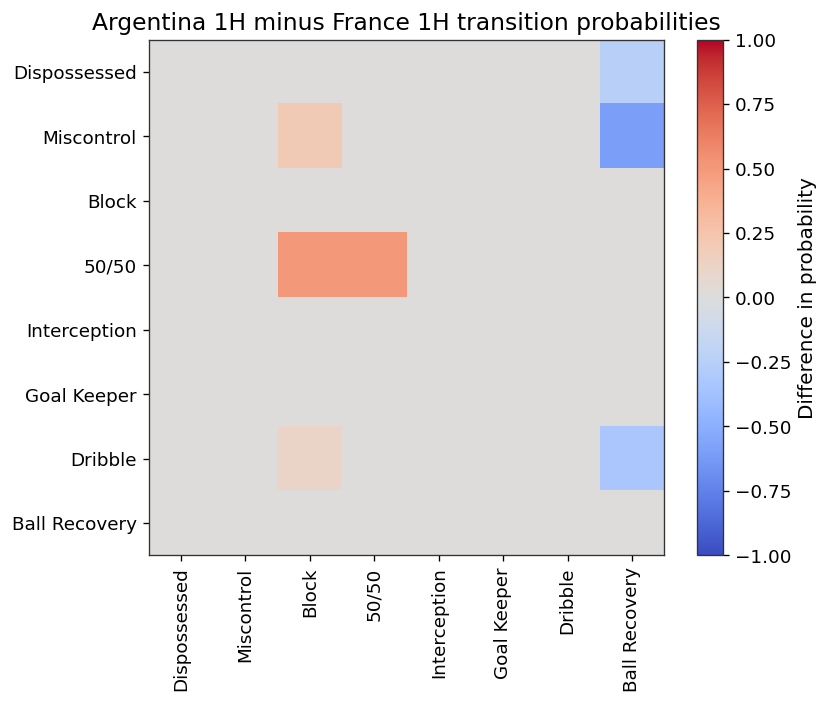

In [62]:
difference_focus_states = state_difference_magnitude.head(8).index.tolist()

fig, ax = plt.subplots(figsize=(8, 6), dpi=120)

difference_view = transition_difference.loc[difference_focus_states, difference_focus_states]
im = ax.imshow(difference_view, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(difference_focus_states)))
ax.set_xticklabels(difference_focus_states, rotation=90)
ax.set_yticks(range(len(difference_focus_states)))
ax.set_yticklabels(difference_focus_states)
ax.set_title("Argentina 1H minus France 1H transition probabilities")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Difference in probability")

plt.tight_layout()
plt.show()


Large row differences do not mean one team is better. They mean the next-step distributions differ.

That is exactly the kind of question a transition-matrix view is built to ask.


## 16A. Turnovers as a modeling object

So far, turnovers have appeared in the notebook mainly as something that affects segmentation or visualization. They deserve a more explicit treatment.

We will use a simple boundary definition first:

> a turnover bridge occurs when two consecutive possessions belong to different teams.

That is a clean and teachable rule, but it is not the only one. A stricter version would count only those team changes that begin with an explicit regain action such as `Ball Recovery`, `Interception`, `Goal Keeper`, or `Duel`.

The data do not force one choice. We do.

In [63]:
incoming_regain_states = {"Ball Recovery", "Interception", "Goal Keeper", "Duel"}

turnover_definition_comparison = pd.DataFrame(
    [
        {
            "definition": "Any team-change boundary between consecutive possessions",
            "count": int(turnover_bridge_table["weight"].sum()),
        },
        {
            "definition": "Team-change boundary where the new possession begins with a regain-type state",
            "count": int(turnover_bridge_table.loc[turnover_bridge_table["target_state"].isin(incoming_regain_states), "weight"].sum()),
        },
        {
            "definition": "Team-change boundary where the new possession begins with Pass",
            "count": int(turnover_bridge_table.loc[turnover_bridge_table["target_state"].eq("Pass"), "weight"].sum()),
        },
    ]
)

display(turnover_definition_comparison)
display(turnover_bridge_table.head(15))

,definition,count
0,Any team-change boundary between consecutive possessions,110
1,Team-change boundary where the new possession begins with a regain-type state,32
2,Team-change boundary where the new possession begins with Pass,78


,source_team,source_state,target_team,target_state,weight
0,France,Ball Receipt*,Argentina,Pass,14
1,Argentina,Ball Receipt*,France,Pass,12
2,France,Pass,Argentina,Pass,8
3,Argentina,Pass,France,Pass,7
4,France,Miscontrol,Argentina,Pass,7
5,Argentina,Shot,France,Pass,6
6,Argentina,Foul Committed,France,Pass,5
7,Argentina,Pass,France,Ball Recovery,5
8,France,Foul Committed,Argentina,Pass,5
9,France,Shot,Argentina,Pass,5


The counts already tell us something important.

Many possession changes do **not** begin with an explicit regain event in the retained sequence. They begin with `Pass`. That can happen because the new possession starts from a restart, because the regain moment is represented elsewhere in the log, or because our own-team sequence keeps only the new team's first on-ball action.

So "turnover" is not a prepackaged field waiting inside the data. It is a rule that we impose on the event stream.

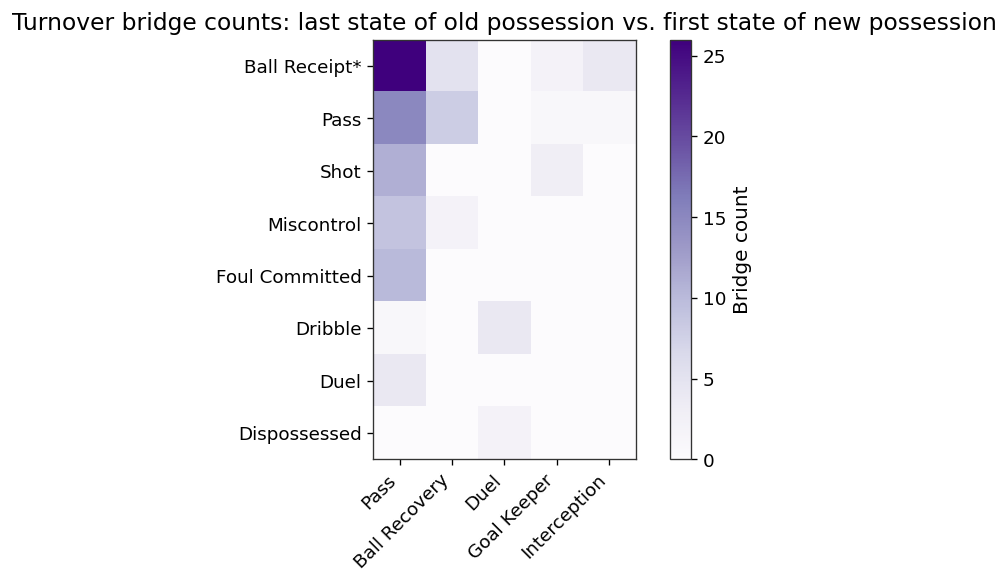

In [64]:
turnover_matrix = (
    turnover_bridge_table
    .pivot_table(index="source_state", columns="target_state", values="weight", aggfunc="sum", fill_value=0)
)

turnover_source_order = (
    turnover_bridge_table.groupby("source_state")["weight"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

turnover_target_order = (
    turnover_bridge_table.groupby("target_state")["weight"]
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
    .tolist()
)

turnover_matrix_view = turnover_matrix.reindex(
    index=turnover_source_order,
    columns=turnover_target_order,
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

im = ax.imshow(turnover_matrix_view, cmap="Purples")

ax.set_xticks(range(turnover_matrix_view.shape[1]))
ax.set_xticklabels(turnover_matrix_view.columns, rotation=45, ha="right")
ax.set_yticks(range(turnover_matrix_view.shape[0]))
ax.set_yticklabels(turnover_matrix_view.index)
ax.set_title("Turnover bridge counts: last state of old possession vs. first state of new possession")

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Bridge count")

plt.tight_layout()
plt.show()

A second useful view is to look at short windows around possession changes.

That lets us ask not just "what state handed over to what state?" but "what small local pattern tended to surround the handover?" 

In [65]:
regulation_gameplay_df = (
    events_df.loc[events_df["is_gameplay"] & events_df["period"].isin([1, 2])]
    .sort_values("index")
    .copy()
)

regulation_gameplay_df["team_state"] = regulation_gameplay_df["team_name"] + ": " + regulation_gameplay_df["event_type"]

regulation_full_possessions = []

for possession_id, group in regulation_gameplay_df.groupby("possession", sort=False):
    group = group.sort_values("index")
    regulation_full_possessions.append(
        {
            "possession": int(possession_id),
            "team": group["possession_team_name"].iloc[0],
            "start_index": int(group["index"].min()),
            "team_state_sequence": group["team_state"].tolist(),
        }
    )

regulation_full_possessions = (
    pd.DataFrame(regulation_full_possessions)
    .sort_values("start_index")
    .reset_index(drop=True)
)

boundary_window_rows = []

for i in range(len(regulation_full_possessions) - 1):
    previous_possession = regulation_full_possessions.iloc[i]
    next_possession = regulation_full_possessions.iloc[i + 1]

    if previous_possession["team"] == next_possession["team"]:
        continue

    previous_tail = previous_possession["team_state_sequence"][-2:]
    next_head = next_possession["team_state_sequence"][:2]
    window = previous_tail + next_head

    boundary_window_rows.append(
        {
            "from_team": previous_possession["team"],
            "to_team": next_possession["team"],
            "window": window,
            "window_str": " → ".join(window),
        }
    )

boundary_windows_df = pd.DataFrame(boundary_window_rows)

boundary_window_counts = (
    boundary_windows_df["window_str"]
    .value_counts()
    .rename_axis("turnover_window")
    .reset_index(name="count")
)

display(boundary_windows_df.head(10)[["from_team", "to_team", "window_str"]])
display(boundary_window_counts.head(12))

,from_team,to_team,window_str
0,France,Argentina,France: Pass → France: Ball Receipt* → Argentina: Pass → France: Pressure
1,Argentina,France,France: Pressure → Argentina: Pass → France: Ball Recovery → France: Carry
2,France,Argentina,France: Carry → France: Miscontrol → Argentina: Pass → Argentina: Ball Receipt*
3,Argentina,France,Argentina: Pass → Argentina: Ball Receipt* → France: Pass → France: Ball Receipt*
4,France,Argentina,France: Carry → France: Miscontrol → Argentina: Pass → Argentina: Ball Receipt*
5,Argentina,France,Argentina: Pass → Argentina: Ball Receipt* → France: Ball Recovery → France: Carry
6,France,Argentina,France: Carry → France: Pass → Argentina: Pass → Argentina: Ball Receipt*
7,Argentina,France,Argentina: Shot → France: Goal Keeper → France: Pass → Argentina: Clearance
8,France,Argentina,France: Carry → France: Pass → Argentina: Pass → Argentina: Ball Receipt*
9,Argentina,France,Argentina: Foul Committed → France: Foul Won → France: Pass → France: Ball Receipt*


,turnover_window,count
0,Argentina: Pass → Argentina: Ball Receipt* → France: Pass → France: Ball Receipt*,10
1,France: Pass → France: Ball Receipt* → Argentina: Pass → Argentina: Ball Receipt*,10
2,France: Carry → France: Miscontrol → Argentina: Pass → Argentina: Ball Receipt*,4
3,Argentina: Shot → France: Goal Keeper → France: Pass → France: Ball Receipt*,4
4,France: Pressure → Argentina: Pass → France: Ball Recovery → France: Carry,3
5,France: Carry → France: Pass → Argentina: Pass → Argentina: Ball Receipt*,3
6,Argentina: Foul Committed → France: Foul Won → France: Pass → France: Ball Receipt*,3
7,France: Foul Committed → Argentina: Foul Won → Argentina: Pass → France: Pass,2
8,France: Pass → France: Ball Receipt* → Argentina: Pass → France: Pressure,2
9,France: Foul Committed → Argentina: Foul Won → Argentina: Pass → Argentina: Ball Receipt*,2


These turnover windows sharpen the interpretation.

Some handovers are clean and restart-like, such as one team ending on `Pass` or `Ball Receipt*` and the next team beginning with `Pass`. Others are much more explicitly defensive: `Pressure`, `Block`, `Ball Recovery`, `Interception`, `Goal Keeper`, `Foul Won`, and `Foul Committed` show up in the immediate neighborhood.

That is why a turnover is often better understood as a **small local sequence structure** rather than as one isolated edge.

## 17. Comparison with player and pitch networks

This course has now built three different network views from the same general event source:

- **player passing network:** who passes to whom,
- **pitch passing network:** which pitch zones connect to which zones,
- **event-transition network:** which action states tend to follow which other action states.

These are not competing models. They answer different questions about the same match.


In [66]:
def draw_statsbomb_pitch(ax, pitch_length=120, pitch_width=80, line_color="black", lw=1.2):
    """Draw a simple StatsBomb-style pitch with standard dimensions."""
    ax.add_patch(Rectangle((0, 0), pitch_length, pitch_width, fill=False, ec=line_color, lw=lw))
    ax.plot([pitch_length / 2, pitch_length / 2], [0, pitch_width], color=line_color, lw=lw)
    ax.add_patch(Circle((pitch_length / 2, pitch_width / 2), 10, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((pitch_length - 18, 18), 18, 44, fill=False, ec=line_color, lw=lw))
    ax.add_patch(Rectangle((pitch_length - 6, 30), 6, 20, fill=False, ec=line_color, lw=lw))
    ax.scatter([12, pitch_length - 12], [pitch_width / 2, pitch_width / 2], s=12, color=line_color)
    ax.add_patch(Arc((12, pitch_width / 2), 20, 20, angle=0, theta1=310, theta2=50, ec=line_color, lw=lw))
    ax.add_patch(Arc((pitch_length - 12, pitch_width / 2), 20, 20, angle=0, theta1=130, theta2=230, ec=line_color, lw=lw))
    ax.set_xlim(-2, pitch_length + 2)
    ax.set_ylim(-2, pitch_width + 2)
    ax.set_aspect("equal")
    ax.axis("off")


def short_player_name(name):
    """Shorten a player name for plotting labels."""
    parts = str(name).split()

    if len(parts) == 1:
        return parts[0]

    if len(parts) >= 2 and parts[-2].lower() in {"di", "de", "del", "da"}:
        last = " ".join(parts[-2:])
    else:
        last = parts[-1]

    return f"{parts[0][0]}. {last}"


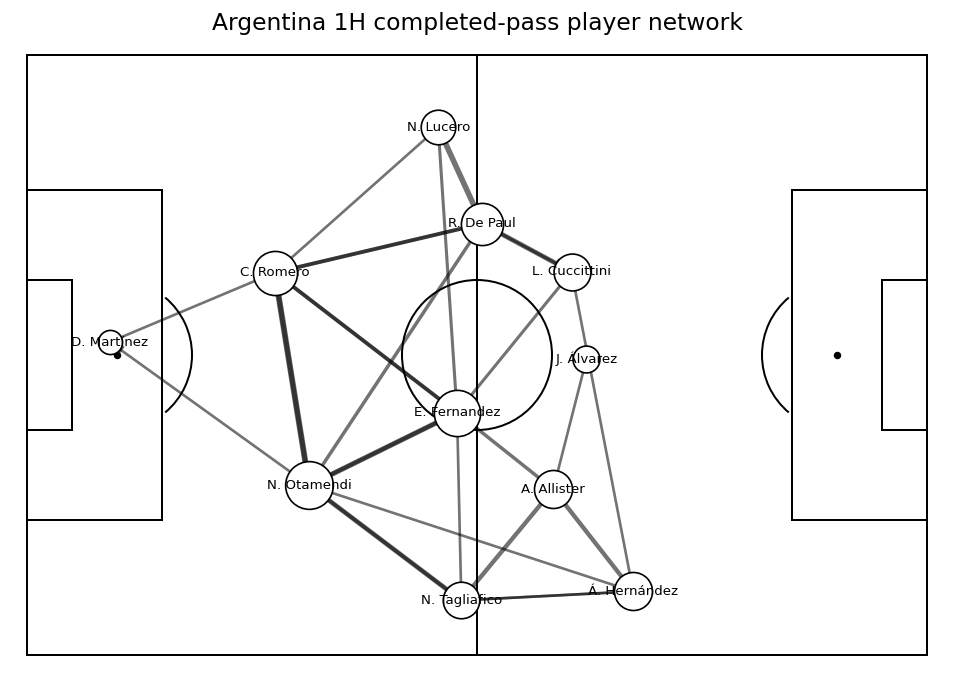

In [67]:
argentina_h1_completed_passes = (
    baseline_df.loc[
        baseline_df["event_type"].eq("Pass")
        & baseline_df["pass_outcome_name"].isna()
        & baseline_df["pass_recipient_name"].notna()
    ]
    .copy()
)

player_edge_table = (
    argentina_h1_completed_passes.groupby(["player_name", "pass_recipient_name"])
    .size()
    .rename("weight")
    .reset_index()
    .rename(columns={"player_name": "source", "pass_recipient_name": "target"})
    .sort_values("weight", ascending=False)
)

player_start_positions = argentina_h1_completed_passes[["player_name", "x", "y"]].rename(
    columns={"player_name": "player"}
)
player_end_positions = argentina_h1_completed_passes[["pass_recipient_name", "pass_end_x", "pass_end_y"]].rename(
    columns={"pass_recipient_name": "player", "pass_end_x": "x", "pass_end_y": "y"}
)

player_positions = (
    pd.concat([player_start_positions, player_end_positions], ignore_index=True)
    .groupby("player")[["x", "y"]]
    .mean()
)

player_touch_counts = (
    pd.concat(
        [
            argentina_h1_completed_passes["player_name"],
            argentina_h1_completed_passes["pass_recipient_name"],
        ],
        ignore_index=True,
    )
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
draw_statsbomb_pitch(ax)

for row in player_edge_table.itertuples(index=False):
    if row.weight < 4:
        continue

    if row.source not in player_positions.index or row.target not in player_positions.index:
        continue

    x1, y1 = player_positions.loc[row.source, ["x", "y"]]
    x2, y2 = player_positions.loc[row.target, ["x", "y"]]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", lw=0.6 + 0.25 * row.weight, alpha=0.55),
    )

for player, coords in player_positions.iterrows():
    size = 60 + 10 * player_touch_counts.get(player, 1)
    ax.scatter(coords["x"], coords["y"], s=size, zorder=3, edgecolor="black", linewidth=1, color="white")
    ax.text(coords["x"], coords["y"], short_player_name(player), ha="center", va="center", fontsize=8, zorder=4)

ax.set_title("Argentina 1H completed-pass player network")
plt.show()


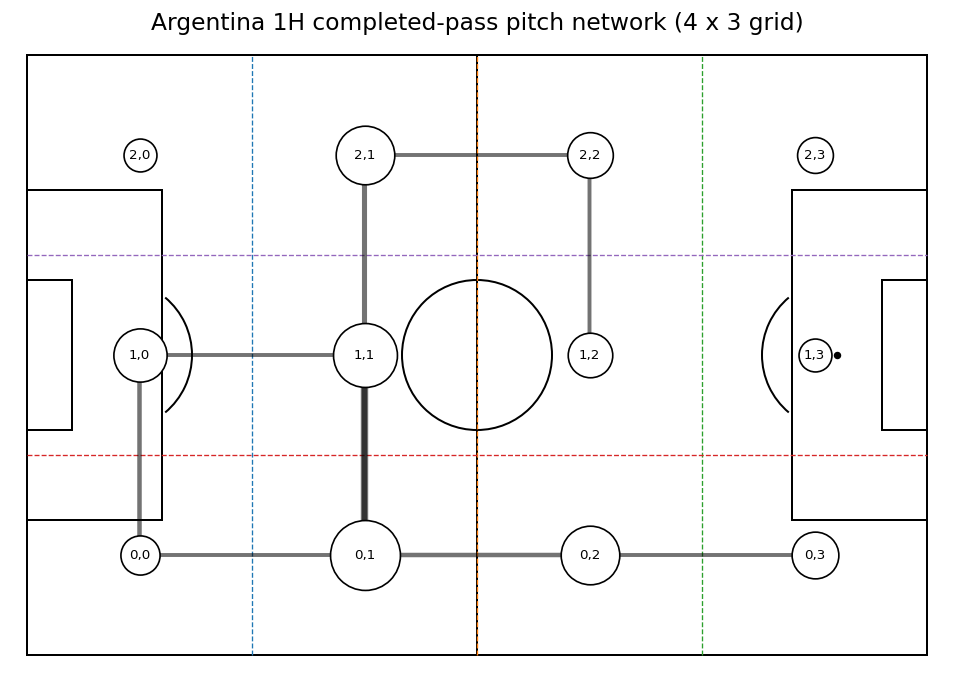

In [68]:
N_COLS = 4
N_ROWS = 3

zone_passes = argentina_h1_completed_passes.dropna(
    subset=["x", "y", "pass_end_x", "pass_end_y"]
).copy()

zone_passes["start_col"] = np.clip((zone_passes["x"] / PITCH_LENGTH * N_COLS).astype(int), 0, N_COLS - 1)
zone_passes["start_row"] = np.clip((zone_passes["y"] / PITCH_WIDTH * N_ROWS).astype(int), 0, N_ROWS - 1)
zone_passes["end_col"] = np.clip((zone_passes["pass_end_x"] / PITCH_LENGTH * N_COLS).astype(int), 0, N_COLS - 1)
zone_passes["end_row"] = np.clip((zone_passes["pass_end_y"] / PITCH_WIDTH * N_ROWS).astype(int), 0, N_ROWS - 1)

zone_passes["start_zone"] = zone_passes["start_row"].astype(str) + "," + zone_passes["start_col"].astype(str)
zone_passes["end_zone"] = zone_passes["end_row"].astype(str) + "," + zone_passes["end_col"].astype(str)

zone_edge_table = (
    zone_passes.groupby(["start_zone", "end_zone"])
    .size()
    .rename("weight")
    .reset_index()
    .rename(columns={"start_zone": "source", "end_zone": "target"})
    .sort_values("weight", ascending=False)
)

zone_touch_counts = (
    pd.concat([zone_passes["start_zone"], zone_passes["end_zone"]], ignore_index=True)
    .value_counts()
)

zone_centers = {}
for r in range(N_ROWS):
    for c in range(N_COLS):
        center_x = (c + 0.5) * PITCH_LENGTH / N_COLS
        center_y = (r + 0.5) * PITCH_WIDTH / N_ROWS
        zone_centers[f"{r},{c}"] = (center_x, center_y)

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
draw_statsbomb_pitch(ax)

for c in range(1, N_COLS):
    ax.plot([c * PITCH_LENGTH / N_COLS, c * PITCH_LENGTH / N_COLS], [0, PITCH_WIDTH], linestyle="--", lw=0.8)
for r in range(1, N_ROWS):
    ax.plot([0, PITCH_LENGTH], [r * PITCH_WIDTH / N_ROWS, r * PITCH_WIDTH / N_ROWS], linestyle="--", lw=0.8)

for row in zone_edge_table.itertuples(index=False):
    if row.weight < 5:
        continue

    x1, y1 = zone_centers[row.source]
    x2, y2 = zone_centers[row.target]

    ax.annotate(
        "",
        xy=(x2, y2),
        xytext=(x1, y1),
        arrowprops=dict(arrowstyle="-|>", lw=0.6 + 0.35 * row.weight, alpha=0.55),
    )

for zone, (x, y) in zone_centers.items():
    size = 120 + 18 * zone_touch_counts.get(zone, 0)
    ax.scatter(x, y, s=size, edgecolor="black", linewidth=1, color="white", zorder=3)
    ax.text(x, y, zone, ha="center", va="center", fontsize=8, zorder=4)

ax.set_title("Argentina 1H completed-pass pitch network (4 x 3 grid)")
plt.show()


The player network and pitch network are both useful, but they answer different questions than the event-transition network.

- The **player network** shows interpersonal passing structure.
- The **pitch network** shows spatial movement of the ball.
- The **event-transition network** shows the grammar of action flow.

The event-transition view makes it easy to ask questions like:

- what tends to follow a recovery,
- whether carries mostly recycle into passes,
- and how much branching occurs after receipt or dribble.

But it hides player identity and exact spatial location unless we explicitly add those into the state definition. That is why these representations are complementary.


## 18. Optional advanced section: start states, end states, random walks, and simple simulation

One useful extension is to add explicit possession boundaries.

We can prepend `START` and append `END` to every possession sequence. That creates a transition matrix in which:

- the row for `START` describes how possessions tend to begin,
- and transitions into `END` describe how modeled sequences terminate.

Once we have that matrix, we can simulate short synthetic possessions. The result is not a realistic match simulator. It is only a first-order approximation of local event flow.

In [69]:
start_end_sequences = []

for seq in baseline_sequences:
    if seq:
        start_end_sequences.append(["START"] + seq + ["END"])

start_end_edge_table = edge_table_from_sequences(start_end_sequences)
start_end_A = adjacency_from_edge_table(start_end_edge_table)
start_end_P, _ = transition_matrix_from_adjacency(start_end_A)

display(start_end_edge_table.head(15))
display(start_end_P.loc[["START"]].round(3))


,source,target,weight
0,Pass,Ball Receipt*,286
1,Ball Receipt*,Carry,206
2,Carry,Pass,202
3,Ball Receipt*,Pass,52
4,START,Pass,33
5,Ball Recovery,Carry,13
6,Ball Receipt*,END,12
7,Carry,Dribble,12
8,Foul Won,END,8
9,Dribble,Carry,7


,50/50,Ball Receipt*,Ball Recovery,Block,Carry,Dispossessed,Dribble,Duel,END,Foul Committed,Foul Won,Goal Keeper,Interception,Miscontrol,Offside,Pass,START,Shot
START,0.0,0.0,0.073,0.0,0.0,0.0,0.0,0.049,0.0,0.0,0.0,0.024,0.024,0.0,0.0,0.805,0.0,0.024


In [70]:
def simulate_sequence(P, start_state="START", end_state="END", max_steps=20, rng=None):
    """Simulate a short state sequence from a row-stochastic transition matrix."""
    if rng is None:
        rng = np.random.default_rng(0)

    current = start_state
    seq = [current]

    for _ in range(max_steps):
        probs = P.loc[current]

        if probs.sum() == 0:
            break

        next_state = str(rng.choice(P.columns.to_list(), p=probs.to_numpy()))
        seq.append(next_state)
        current = next_state

        if current == end_state:
            break

    return seq


rng = np.random.default_rng(5442)

simulated_sequences = pd.DataFrame(
    {
        "simulation": range(1, 6),
        "sequence": [" → ".join(simulate_sequence(start_end_P, rng=rng)) for _ in range(5)],
    }
)

simulated_sequences


,simulation,sequence
0,1,START → Goal Keeper → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Pass → Ba...
1,2,START → Goal Keeper → Pass → Ball Receipt* → Miscontrol → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carr...
2,3,START → Pass → Ball Receipt* → Duel → Foul Committed → END
3,4,START → Pass → Ball Receipt* → Miscontrol → Ball Recovery → Carry → Pass → Ball Receipt* → Pass → Ball Receipt* → Pa...
4,5,START → Pass → Ball Receipt* → Carry → Dribble → Carry → Pass → Ball Receipt* → Carry → Pass → Ball Receipt* → Carry...


### Comparing real and simulated possessions

A random walk is only interesting if we compare it with the empirical possessions that generated the matrix.

The next few cells use many simulated walks from `START` to `END` and compare them with the observed Argentina first-half possessions.

In [71]:
rng = np.random.default_rng(5442)

n_simulations = 5000
simulated_walks = [simulate_sequence(start_end_P, rng=rng, max_steps=80) for _ in range(n_simulations)]

simulated_core_sequences = []
for seq in simulated_walks:
    core = [state for state in seq if state not in {"START", "END"}]
    simulated_core_sequences.append(core)

empirical_lengths = pd.Series([len(seq) for seq in baseline_sequences], name="Empirical")
simulated_lengths = pd.Series([len(seq) for seq in simulated_core_sequences], name="Simulated")


def share_visiting_state(sequences, state):
    """Return the share of sequences that visit a given state at least once."""
    return float(np.mean([state in seq for seq in sequences]))


simulation_summary = pd.DataFrame(
    [
        {
            "series": "Empirical possessions",
            "mean_length": empirical_lengths.mean(),
            "median_length": empirical_lengths.median(),
            "90th_pct_length": empirical_lengths.quantile(0.9),
            "share_with_shot": share_visiting_state(baseline_sequences, "Shot"),
            "share_with_ball_recovery": share_visiting_state(baseline_sequences, "Ball Recovery"),
            "share_with_miscontrol": share_visiting_state(baseline_sequences, "Miscontrol"),
        },
        {
            "series": "Simulated random walks",
            "mean_length": simulated_lengths.mean(),
            "median_length": simulated_lengths.median(),
            "90th_pct_length": simulated_lengths.quantile(0.9),
            "share_with_shot": share_visiting_state(simulated_core_sequences, "Shot"),
            "share_with_ball_recovery": share_visiting_state(simulated_core_sequences, "Ball Recovery"),
            "share_with_miscontrol": share_visiting_state(simulated_core_sequences, "Miscontrol"),
        },
    ]
)

simulation_summary.round(3)

,series,mean_length,median_length,90th_pct_length,share_with_shot,share_with_ball_recovery,share_with_miscontrol
0,Empirical possessions,21.537,14.0,51.0,0.146,0.268,0.122
1,Simulated random walks,20.976,15.0,48.0,0.145,0.281,0.132


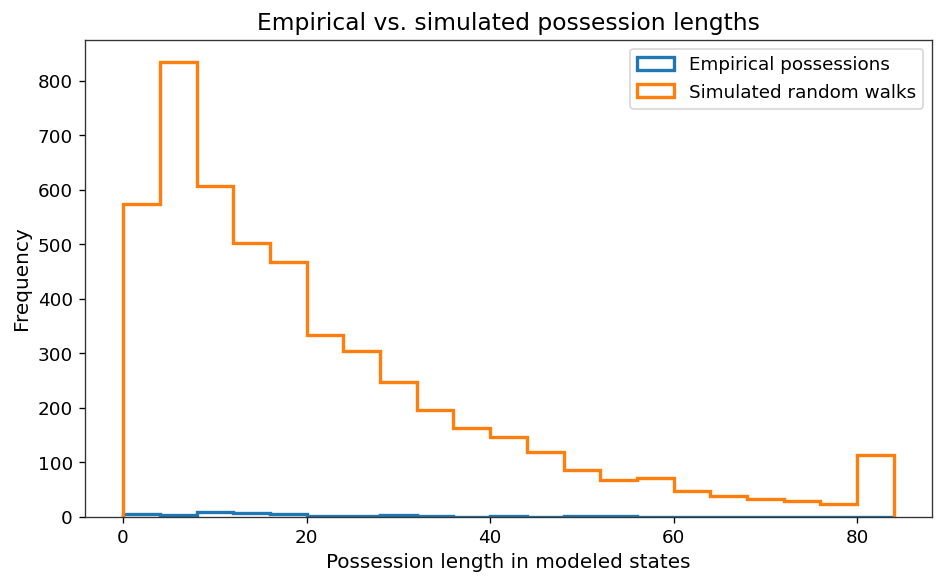

In [72]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=120)

bins = np.arange(0, 85, 4)

ax.hist(empirical_lengths, bins=bins, histtype="step", linewidth=2, label="Empirical possessions")
ax.hist(simulated_lengths, bins=bins, histtype="step", linewidth=2, label="Simulated random walks")

ax.set_xlabel("Possession length in modeled states")
ax.set_ylabel("Frequency")
ax.set_title("Empirical vs. simulated possession lengths")
ax.legend()

plt.tight_layout()
plt.show()

The comparison is useful, but it is not a validation seal.

Because the walk uses the empirical `START` and `END` structure, it can reproduce some coarse marginals surprisingly well. Even so, the model is still limited in ways that matter:

- it is memoryless at one-step resolution,
- it ignores player identity and field location,
- it does not adapt to score, game phase, or match context,
- and it inherits every modeling choice built into the state vocabulary and the segmentation rule.

So a random walk on this network is best understood as a compact generative toy model for local event flow, not as a full tactical simulator.

The simulated sequences often look plausible at a local level because the transition matrix has learned common next-step patterns.

That is exactly what a first-order random walk is built to do: respect the observed next-step probabilities.

But even a plausible synthetic sequence should be interpreted cautiously. The walk is still flattening a rich match context into one row-stochastic matrix.

## 19. Optional advanced section: within-possession coupled event networks

Earlier in the notebook, we built a coupled view across possession boundaries using turnover bridges.

Here we do something different. We keep opponent actions that occur **inside** the same possession segment. That turns the sequence into a more explicitly interactive process. It lets us see patterns such as:

- the focus team carrying and the opponent pressuring,
- shot followed by goalkeeper action,
- or a foul committed by one team immediately preceding a foul won by the other.

In [73]:
coupled_df = (
    events_df.loc[
        events_df["period"].eq(1)
        & events_df["possession_team_name"].eq(MAIN_TEAM)
        & ~events_df["event_type"].isin(STRUCTURAL_EVENTS)
    ]
    .sort_values("index")
    .copy()
)

coupled_df["side_prefix"] = np.where(coupled_df["team_name"].eq(MAIN_TEAM), "ARG", "FRA")
coupled_df["state"] = coupled_df["side_prefix"] + ": " + coupled_df["event_type"].astype(str)

coupled_sequences = extract_sequences_from_df(coupled_df, group_col="possession", state_col="state")
coupled_edge_table = edge_table_from_sequences(coupled_sequences)

cross_team_edges = coupled_edge_table.loc[
    coupled_edge_table["source"].str.slice(0, 3) != coupled_edge_table["target"].str.slice(0, 3)
].copy()

cross_team_edges.head(15)


,source,target,weight
4,ARG: Carry,FRA: Pressure,33
5,FRA: Pressure,ARG: Pass,28
6,ARG: Pass,FRA: Pressure,18
7,FRA: Pressure,ARG: Ball Receipt*,18
9,FRA: Foul Committed,ARG: Foul Won,8
10,ARG: Ball Receipt*,FRA: Interception,7
12,FRA: Dribbled Past,ARG: Dribble,7
14,ARG: Carry,FRA: Dribbled Past,5
15,ARG: Shot,FRA: Goal Keeper,5
18,ARG: Ball Receipt*,FRA: Pass,4


This coupled view is conceptually different from the main baseline network.

The main network asks about the focus team's action grammar within its own possession sequences.

The coupled network asks about interaction across teams inside those possession windows. Both are reasonable. They just answer different questions.


## 20. Optional advanced section: state-space growth and vocabulary explosion

Richer tokenization makes the network more expressive, but it also makes the state space larger and sparser.

This is a general pattern in sequence modeling. Every time we add more context to the token, we increase the vocabulary and usually decrease the number of observations per state.


In [74]:
vocabulary_growth = comparison_df.copy()
vocabulary_growth["states_per_100_transitions"] = 100 * vocabulary_growth["states"] / vocabulary_growth["total_transitions"]
vocabulary_growth["edges_per_100_transitions"] = 100 * vocabulary_growth["edges"] / vocabulary_growth["total_transitions"]

vocabulary_growth


,design,states,edges,density,total_transitions,states_per_100_transitions,edges_per_100_transitions
0,Contracted,9,31,0.382716,842,1.068884,3.681710
1,Coarse,16,46,0.179688,842,1.900238,5.463183
2,Outcome aware,23,56,0.105860,842,2.731591,6.650831
3,Enriched,49,99,0.041233,842,5.819477,11.757720
4,Enriched + play pattern,93,168,0.019424,842,11.045131,19.952494


In [75]:
singleton_summary = []

for design_name, obj in network_objects.items():
    state_counts = obj["df"]["state"].value_counts()
    singleton_summary.append(
        {
            "design": design_name,
            "states": int(state_counts.shape[0]),
            "states_seen_once": int((state_counts == 1).sum()),
            "share_seen_once": float((state_counts == 1).mean()),
        }
    )

singleton_summary_df = pd.DataFrame(singleton_summary)
singleton_summary_df


,design,states,states_seen_once,share_seen_once
0,Contracted,9,1,0.111111
1,Coarse,16,2,0.125000
2,Outcome aware,23,6,0.260870
3,Enriched,50,16,0.320000
4,Enriched + play pattern,94,38,0.404255


As the state design becomes richer, the share of rarely observed states usually rises. That is one reason not to enrich the vocabulary blindly.

There is no neutral state space waiting inside the data. There is only a sequence of modeling decisions with tradeoffs.


## 21. Optional advanced section: matrix comparison across teams

A compact way to compare two event-transition models is to align their transition matrices on a shared state set and subtract one from the other.

We already did that for Argentina and France in the first half, using the coarse one-team possession-based model. Another useful summary is to look at the largest row-wise differences and ask which current states have the most different continuation patterns.


In [76]:
state_difference_magnitude.head(12).rename("row-wise L1 difference").to_frame()


,row-wise L1 difference
Dispossessed,1.500000
Miscontrol,1.200000
Block,1.000000
50/50,1.000000
Interception,1.000000
Goal Keeper,1.000000
Dribble,0.666667
Ball Recovery,0.333333
Ball Receipt*,0.144149
Pass,0.103750


A positive cell in the earlier heatmap meant Argentina had the larger transition probability for that row-column pair in the selected first-half model. A negative cell meant France did.

Again, that is not a direct quality ranking. It is a structural comparison of next-step tendencies.


## 22. Closing synthesis

By this point, the main conceptual move should be clear.

A soccer event file starts as a chronological log of rich observations. It becomes an event-transition network only after we decide:

- what the sequence units are,
- which events count as states,
- how to segment the stream,
- whether to keep one team's actions only or include interaction,
- whether the state space should stay coarse, be contracted, or be enriched,
- how to treat turnovers and possession changes,
- and whether we want counts, row-normalized probabilities, or even a simple random-walk approximation.

That is why the central lesson of these two classes is:

> an event log is not itself a graph.

The graph appears only after modeling choices create a state space and a transition rule.


### What event-transition networks capture well

They are especially good at showing:

- local action grammar,
- common continuations after a given event state,
- branching versus concentration,
- and how representation choices reshape the network.

### What they miss

They are incomplete if used alone. In their simplest form they do not fully capture:

- who the players were,
- where the actions happened,
- longer-range tactical memory,
- score and match-state effects,
- or the many off-ball structures that shape the game.

That is exactly why this course studies multiple network representations side by side.


## Appendix A. StatsBomb data semantics that matter for this notebook

Several modeling choices above rely on details from the StatsBomb Open Data Specification.

1. `pass.type.name` is often missing for ordinary run-of-play passes. That is not arbitrary missingness. In this schema it usually means a standard pass rather than a special subtype such as a throw-in or corner.
2. `pass.outcome.name` is usually missing for completed passes. When we labeled a pass as `Complete` if `pass_outcome_name` was missing, we were following the provider's schema convention.
3. `ball_receipt.outcome.name` is recorded for incomplete ball receipts. Missing receipt outcome usually means the receipt was successfully completed.
4. `under_pressure` is a boolean context flag on many event types. It is not the same object as a separate `Pressure` event row.
5. A possession id and a possession team do not guarantee that every row in that possession is a clean on-ball action by that team. Contest and interruption events by the other team can still appear before the possession id flips.

Those points are exactly why event-state modeling should start with schema inspection rather than with blind extraction.

## Appendix B. Open software and reproducibility resources

A few open tools and repositories are especially useful if you want to keep building after this notebook.

- **StatsBomb Open Data repository**: the source of the JSON event files used here.
- **StatsBomb Open Data Specification**: the best place to check event semantics before inventing preprocessing rules.
- **`statsbombpy`**: a convenient Python interface for loading StatsBomb data.
- **`socceraction` and Atomic-SPADL**: useful when you want standardized action representations and action-value pipelines such as VAEP.
- **`soccermatics`**: an accessible teaching-oriented ecosystem for soccer analytics.
- **MarkovSoccer**: a compact open example of Markov-style soccer state modeling.
- **Malqui et al. (2019)**: a helpful visual-analytics reference for recurring passing-sequence motifs and sequence displays.

Those resources are not substitutes for careful modeling choices, but they do make experimentation much faster.

## 23. References

### Football sequence analysis, match analysis, and football networks

Reep, C., and Benjamin, B. (1968). Skill and chance in association football. *Journal of the Royal Statistical Society. Series A (General)*, 131(4), 581–585. https://doi.org/10.2307/2343726

Hughes, M., and Franks, I. M. (2005). Analysis of passing sequences, shots and goals in soccer. *Journal of Sports Sciences*, 23(5), 509–514. https://doi.org/10.1080/02640410410001716779

Mackenzie, R., and Cushion, C. (2013). Performance analysis in football: a critical review and implications for future research. *Journal of Sports Sciences*, 31(6), 639–676. https://doi.org/10.1080/02640414.2012.746720

Sarmento, H., Marcelino, R., Anguera, M. T., Campaniço, J., Matos, N., and Leitão, J. C. (2014). Match analysis in football: a systematic review. *Journal of Sports Sciences*, 32(20), 1831–1843. https://doi.org/10.1080/02640414.2014.898852

Grund, T. U. (2012). Network structure and team performance: the case of English Premier League soccer teams. *Social Networks*, 34(4), 682–690. https://doi.org/10.1016/j.socnet.2012.08.004

López Peña, J., and Touchette, H. (2012). A network theory analysis of football strategies. *arXiv*. https://arxiv.org/abs/1206.6904

Narizuka, T., Yamamoto, K., and Yamazaki, Y. (2014). Statistical properties of position-dependent ball-passing networks in football games. *Physica A: Statistical Mechanics and its Applications*, 412, 157–168. https://doi.org/10.1016/j.physa.2014.06.037

Buldú, J. M., Busquets, J., Martínez, J. H., Herrera-Diestra, J. L., Echegoyen, I., Galeano, J., and Luque, J. (2018). Using network science to analyse football passing networks: dynamics, space, time, and the multilayer nature of the game. *Frontiers in Psychology*, 9, 1900. https://doi.org/10.3389/fpsyg.2018.01900

Caicedo-Parada, S., Lago-Peñas, C., and Ortega-Toro, E. (2020). Passing networks and tactical action in football: a systematic review. *International Journal of Environmental Research and Public Health*, 17(18), 6649. https://doi.org/10.3390/ijerph17186649

Alves, I. S., Salgado, R. A., and Pinto, P. C. C. (2025). Football as a complex system: a bibliometric review of network analysis in football. *Frontiers in Psychology*, 16, 1659603. https://doi.org/10.3389/fpsyg.2025.1659603

### Sequential models, memory, and action-value perspectives

Rudd, S. (2011). *A framework for tactical analysis and individual offensive production assessment in soccer using Markov chains*. New England Symposium on Statistics in Sports.

López Peña, J. (2014). A Markovian model for association football possession and its outcomes. *arXiv*. https://arxiv.org/abs/1403.7993

Rosvall, M., Esquivel, A. V., Lancichinetti, A., West, J. D., and Lambiotte, R. (2014). Memory in network flows and its effects on spreading dynamics and community detection. *Nature Communications*, 5, 4630. https://doi.org/10.1038/ncomms5630

Scholtes, I. (2017). When is a network a network? Multi-order graphical model selection in pathways and temporal networks. In *Proceedings of the 23rd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 1037–1046). https://doi.org/10.1145/3097983.3098145

Mattsson, C. E. S., and Takes, F. W. (2021). Trajectories through temporal networks. *Applied Network Science*, 6, 35. https://doi.org/10.1007/s41109-021-00374-7

Decroos, T., Bransen, L., Van Haaren, J., and Davis, J. (2019). Actions speak louder than goals: valuing player actions in soccer. In *Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining* (pp. 1851–1861). https://doi.org/10.1145/3292500.3330758

Fernández, J., Bornn, L., and Cervone, D. (2021). Decomposing the immeasurable sport: a deep learning expected possession value framework for soccer. *Machine Learning*, 110, 1385–1424. https://doi.org/10.1007/s10994-021-05989-6

### Data, software, and open resources

StatsBomb. *Open Data repository*. https://github.com/statsbomb/open-data

StatsBomb. *Open Data Specification*. https://github.com/statsbomb/open-data/blob/master/doc

`statsbombpy`. https://github.com/statsbomb/statsbombpy

`socceraction`. https://github.com/ML-KULeuven/socceraction

`soccermatics`. https://soccermatics.readthedocs.io

MarkovSoccer. https://github.com/andrewRowlinson/MarkovSoccer

Malqui, C., Fischer, P., Schreck, T., and Weiskopf, D. (2019). Event sequence analysis and visualization for understanding team sport match play. *Computers & Graphics*, 84, 122–133. https://doi.org/10.1016/j.cag.2019.08.010